# Network Efficiency and Flows
- Final Project for Network Science Data (PHYS 7332)
- Semeseter: Fall 2024
- Name: Minami Ueda
- Date: December 10, 2024


## Table of Contents
- [1. Introduction](#intro)
- [2. Network Flow](#network-flow)
- [3. Maximum Flow Problem](#max-flow)
- [4. Minimum-Cost Flow Problem](#min-cost-flow)
- [5. Cost-Efficiency Optimization Problem](#cost-efficiency)
- [6. Case Study: Airport Network](#casestudy-airport)
- [7. Case Study: OpenStreet Map](#casestudy-osm)
- [8. Conclusion](#conclusion)
- [References](#references)

***
## Setup

In [1110]:
import numpy as np
import pandas as pd
import networkx as nx
import random
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [1111]:
from tqdm import tqdm
from collections import defaultdict

In [1112]:
import os
import pickle

In [1113]:
%config InlineBackend.figure_format = 'retina'
plt.rcParams['text.usetex'] = False 
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Helvetica'

In [1114]:
# Set a new working directory
new_working_directory = '/home/ueda.m/final-project/'
os.chdir(new_working_directory)
print(f"New working directory: {os.getcwd()}")

New working directory: /home/ueda.m/final-project


***

<h2 id="intro">1. Introduction</h2>

### Is the "efficient path" really efficient for everyone?

**What is "efficiency" in a network, and how can we measure it quantitatively?** Now that we've learned the foundations of the network science in the previous chapters, you might come up with an idea of computing the *shortest path* to efficiently move from point A to point B in the network, because it provides the "best" route in terms of the number of steps it requires. While this is true in simple cases, it is not always the perfect methodology for real-world networks. **Shortest path computation has limitations in practical applications.**

Let's think about a real-life situation to frame illustrate the limitation. Imagine in a busy weekday morning, you are trying to get from the Boston Common to Kendall Square in Cambridge, perhaps to attend an important meeting. If you're traveling alone—say on foot, by bike, or even by car—you could **choose the shortest route based on the distance, including a narrow alley** which another person can barely pass by. This route is efficient as a single traveler, as it minimizes the time or effort required.

Now, imagine the same scenario, but this time during a major event like the [Head of the Charles Regatta](https://en.wikipedia.org/wiki/Head_of_the_Charles_Regatta). **Thousands of people are heading toward the same direction**, resulting in a great [congestion on bridges](https://www.hocr.org/news/400000-spectators-line-the-banks-of-bostons-charles-river-during-50th-annual-head-of-the-charles-regatta/), roads, and trains. The shortest route for an individual is **no longer the most efficient for the group**. A narrow alley that we've mentioned earlier, for instance, will become a bottleneck for the thousands of crowd if they try to go in the same path. In such cases, it makes more sense to select route(s)that is capable of large traffics for example based on the width of the road.

<img src="https://www.hocr.org/wp-content/uploads/2018/06/1440x696_WeeksAerialCarlos2017.jpg" width=500></img>

> Image from [Head of the Charles Regatta](https://www.hocr.org/news/400000-spectators-line-the-banks-of-bostons-charles-river-during-50th-annual-head-of-the-charles-regatta/): "400,000 Spectators Line the Banks of Boston’s Charles River During 50th Annual Head Of The Charles® Regatta"

**This highlights the importance of concepts such as "flow", "capacity", and the "cost" of the network in real-world settings**. By utilizing mathematical concepts of network optimization, we can come up with better ways to improve the traffics on a network. We'll cover some of these examples in the later sections.

Such approaches in choosing the "efficient" path can also be useful in other real-world problems, including the following.
- **Airline network**: Airlines operate aircrafts from one city to another. Some large airports such as JFK (in New York) or ORD (in Chicago) works as "hub" which provides an efficient option for your travels even if there is no direct flights available between the cities you wish to travel.
- **Internet routing**: The internet is constituted by routers all over the world that are connected to each other by physical cables, which are typically optical fibers. Some goes through tunnels, and some goes under the deep sea over the pacific! There are even variations of bandwidths that the fibers can transmit: some could transfer at a rate of 100Gbps, whereas some of the recent fibers could be at a rate of 400Gbps. In such network of fibers and routers, what is the optimal (fastest) path that can route a large dataset (more than a terabyte) from Boston to Tokyo?

### Objectives of the Chapter

In this chapter, we aim to accomplish the following objectives through the explanation of fundamenal mathematics behind each concepts, scratch implementations (including "your-turn" section) of algorithms, and the introduction of real-world examples.
- Understand the concept and mathematics behind network flow
- Understand key optimization approaches and algorithms in networks
- Implement the concepts from scratch in Python
- Apply the methodologies in realworld examples


***
<h2 id="network-flow">2. Network Flow</h2>

### Outline of this section
- Introduction: Rise of the study on network flows
- Understand concepts: flow network, flow, capacity

### Introduction: Rise of the study on network flows


Since when has the flows on networks been important? The study on the mathematical concept of the flow and capacity in networks dates back to 1950s, that is around 70 years ago from now. **The 1950s was the decade under post-World War II regime** where the world experienced heated geopolitical tensions with the **development of the Cold War between the United States and the Soviet Union**.

Indeed, **the study of flow and capacity in networks** did not arise purely from a scientific interest, but **was rather discovered as part of a practical military research** by scientists in the RAND project for the United States Air Force, to plan on the **effective attack on the railroad network** in Russia during the cold war. The paper by Harris and Ross was intended to provide personnels in the air force a method to assist the commander to timely estimate the results of several alternate plans on the railway iterdiction. [1]

![](images/harris-ross-1955-map.png)

The Ford-Fulkerson algorithm [2], one of the fundamental algorithms to solve the maximum flow problem that we will learn in the later sections of this chapter, was also developed during this period.

### Definitions

Before we dive into actually optimizing the network flows, let's first go through the basic concepts that we need to understand.

#### Connectivity
**Connectivity** quantifies the number of independent paths between a pair of nodes. This metric measures **how strongly a pair of nodes are connected to each other.** [3]

For instance, if there was a pair of nodes with **two independent paths** (also known as disjoint paths) in between, and another node pair with **one independent path**, the first pair is more strongly connected. (Two paths are *node-independent* if they share no nodes other than the source and the target; two paths are *edge-independent* if they don't share edges. [3]) The node pair with two independent paths is **more robust** because it remains connected even if we disconnect the other path.

In the context of flow networks, connectivity helps us assess how resilient the network is to disruptions and where bottlenecks might occur. 

The idea of connectivity is formalized by the notion of **cut sets**, which we'll describe below.

#### Cut Sets
A **cut set** is the set of nodes or edges whose removal will disconnect a specified pair of nodes [3].
- **Edge cut set**: A set of edges whose removal disconnects $s$ and $t$.
- **Node cut set**: A set of nodes whose removal disconnects $s$ and $t$.

The **minimum cut set** is the smallest set of edges or nodes whose removal will disconnect a specified pair of nodes. These sets represent the **bottlenecks** (in this case the critical nodes/edges that are vulnerable to the attack) in the network.

#### Menger's Theorem
What connects the concept of the connectivity and the cut set is the **Menger's Theorem**. The theorem states the following relationships [3]:
- The size of the smallest **edge** cut set between $s$ and $t$ equals the number of **edge**-independent paths between them.
- The size of the smallest **node** cut set equals the number of **node**-independent paths between $s$ and $t$.

In other words, the **connectivity of a pair of nodes is the same to the number of bottlenecks between them**.

These concepts are directly connected to the maximum flow problem that we'll cover later, because the maximum flow is equal to the number of edge-independent paths times the maximum flow along a single edge.

#### Flow network

**Flow network** is a directed graph that handles traffic called *flow*, which is an abstract entity that is generated at *source nodes*, tranmitted across edges, and abosrbed at *sink* nodes [4].

**Source node** $s$ is the node where the traffic originates from, and the **sink node** $t$ (or the target node) is the node that works as the destination that absorbs the traffic. Among all nodes (including source and sink nodes) in the network, each edges has **capacity** that indicates the maximum amount of traffics that can handle per unit time. The actual traffic that goes through each edges are called **flow**.

Let's define these in a formal way. Flow network is a directed graph $G=(V,E)$ with following features [4]:
- Each edge $(i,j)$ has capacity, which is a nonnegative number $c_{ij}$
- There is a single source node $s \in V$
- There is a single sink node $t \in V$

The following figure illustrates a flow network with source $s$ and sink $t$. The edge labels represent the flow and capacity of each edge. (Note that the flow shown here does not result in the maximum flow.)

In [823]:
# Function to create a figure to illustrate the concept of flow network
def flow_network_concept_figure():

    # ===== Base graph =====

    # Let's create a simple directed graph that we'll use for demonstration
    G = nx.DiGraph()
    for node_name in ['s', 'u', 'v', 't']:
        G.add_node(node_name)

    # Add edges
    edges = [('s', 'u'), ('s', 'v'), ('u', 'v'), ('u', 't'), ('v', 't')]
    for edge in edges:
        G.add_edge(edge[0], edge[1])

    # Set capacity for each edge
    capacities = {
        ('s', 'u'): 40,
        ('s', 'v'): 10,
        ('u', 'v'): 30,
        ('u', 't'): 20,
        ('v', 't'): 20
    }
    for edge, capacity in capacities.items():
        G.edges[edge]['capacity'] = capacity

    # Set flow for each edge
    flows = {
        ('s', 'u'): 20,
        ('s', 'v'): 10,
        ('u', 'v'): 10,
        ('u', 't'): 10,
        ('v', 't'): 20
    }
    for edge, flow in flows.items():
        G.edges[edge]['flow'] = flow

    # ===== Plot =====
    fig, ax = plt.subplots(1,1, figsize=(8,6))

    # Manually position nodes
    pos = {
        's': [ 0, 0 ],
        'u': [ 2, 2 ],
        'v': [ 2, -2 ],
        't': [ 4, 0 ],
    }

    # Plot the graph with 'capacity' labels on edge
    nx.draw(G, pos=pos, with_labels=True, ax=ax)
    # nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=nx.get_edge_attributes(G, 'capacity'), ax=ax)

    flow_capacity_labels = {(u, v): f"flow {data['flow']} / capacity {data['capacity']}" for u, v, data in G.edges(data=True)}
    nx.draw_networkx_edge_labels(
        G,
        pos=pos,
        edge_labels=flow_capacity_labels,
        ax=ax
    )
    
    fig.show()

    return G, fig, ax

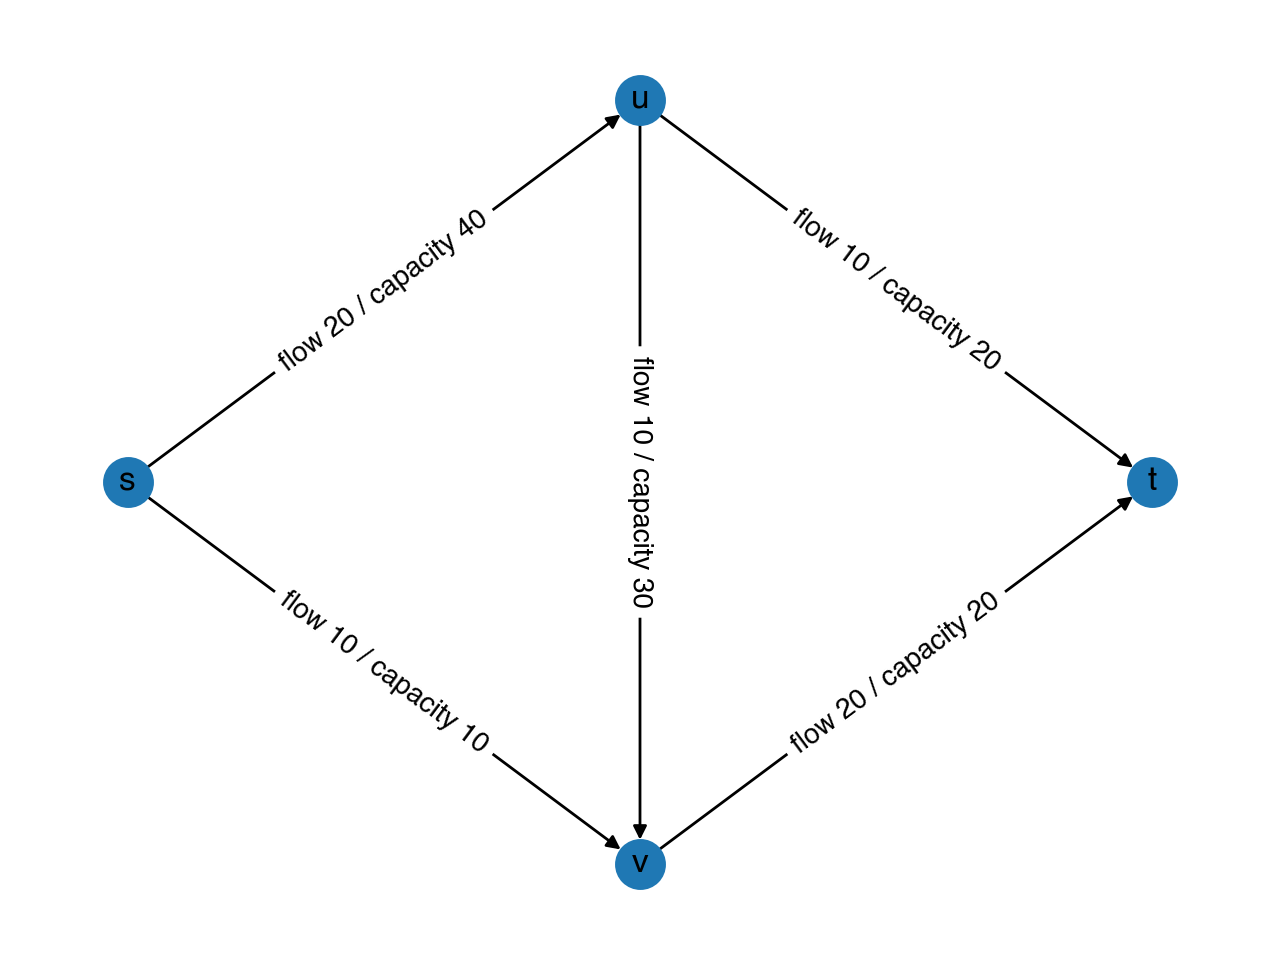

In [824]:
G0, _, _ = flow_network_concept_figure()
plt.show()

#### Flow and capacity


**Flow** $f$ is a function that maps each edge to a non-negative real number, and represents the amount of traffic per unit time that goes through edge. Flow must satisfy the following properties [4]:
- **Capacity conditions**: For each edge $(i, j)$ in $E$,
<!-- $$0 \leq f(e) \leq  c_e$$ -->
$$
0 \leq f_{ij} \leq c_{ij}
$$
- **Conservation conditions**: For each node $j$ other than $s$ and $t$, 
<!-- $$
\sum_{e \text{ into } v} f(e) = \sum_{e \text{ out of  } v} f(e)
$$ -->
$$
\sum_{j : (i, j) \in E} f_{ij} = \sum_{j : (j, i) \in E} f_{ji}

$$

The capacity condition is obvious, and we could think of this using the **analogy of water**. If there was a water pipe with a capacity of 10 gallon per minute (GPM), we cannot have a water traffic exceeding 10 GPM. Adding water flow with a rate of 50 GPM through this water pipe would probably cause it to burst.

The conservation conditions mean that the amount of flow entering must equal the amount of flow leaving. This can also be explained from the analogy of branched water pipes. Assuming that each water pipes has the same capacity of 10 GPM, an incoming water traffic of 10 GPM can for example be splitted into two pipes with each at a rate of 3 GPM and 7 GPM (or at any rates that sums to 10 GPM).

The **value of a flow** $f$, denoted as $v(f)$ is defined as the amount of flow generated at the source $s$.
<!-- $$v(f) = \sum_{e \text{ out of  } s} f(e)$$ -->
$$v(f) = \sum_{j : (s, j) \in E} f_{sj}$$


Now, let's confirm that the flow conditions are true for the graph given above.

In [825]:
# Capacity condition
# Your turn! 

# Task:
# Write a function `check_capacity_conditions()` that checks if the flow on each edge in given graph G satisfies the capacity condition.

# Input:
# G: A directed graph with nodes and edges. Each edge has a 'flow' attribute and a 'capacity' attribute. We will use G0 from the previous example.

# Output:
# A dictionary with the edge as key and a boolean value as value.
# e.g., { ('s', 'u'): True, ('s', 'v'): True, ... }

def check_capacity_conditions(G):

    pass


In [826]:
# Task:
# Write a function `check_capacity_conditions()` that checks if the flow on each edge in given graph G satisfies the capacity condition.

# Input:
# G: A directed graph with nodes and edges. Each edge has a 'flow' attribute and a 'capacity' attribute. We will use G0 from the previous example.

# Output:
# A dictionary with the edge as key and a boolean value as value.
# e.g., { ('s', 'u'): True, ('s', 'v'): True, ... }

def check_capacity_conditions(G):
    capacity_condition_dict = {}

    for edge in G.edges:
        is_capacity_condition_satisfied = \
            (G.edges[edge]['flow'] >= 0) and \
            (G.edges[edge]['flow'] <= G.edges[edge]['capacity'])
        capacity_condition_dict[edge] = is_capacity_condition_satisfied

    return capacity_condition_dict

In [827]:
check_capacity_conditions(G0)

{('s', 'u'): True,
 ('s', 'v'): True,
 ('u', 'v'): True,
 ('u', 't'): True,
 ('v', 't'): True}

In [828]:
# Flow conservation condition
# Your turn!

# Task:
# Write a function `check_flow_conservation_conditions()` that checks if the flow on each edge in given graph G satisfies the flow conservation condition.

# Input:
# G: A directed graph with nodes and edges. Each edge has a 'flow' attribute and a 'capacity' attribute. We will use G0 from the previous example.
# source_node: The name of the source node. In G0, it is 's'.
# target_node: The name of the target node. In G0, it is 't'.

# Output:
# A dictionary with node name as key and a boolean value as value.
# e.g., {'u': True, 'v': True}


def check_flow_conservation_conditions(G, source_node='s', target_node='t'):

    # Hint: Conservation conditions does not apply to source and target nodes 

    pass


In [829]:
# Task:
# Write a function `check_flow_conservation_conditions()` that checks if the flow on each edge in given graph G satisfies the flow conservation condition.

# Input:
# G: A directed graph with nodes and edges. Each edge has a 'flow' attribute and a 'capacity' attribute. We will use G0 from the previous example.
# source_node: The name of the source node. In G0, it is 's'.
# target_node: The name of the target node. In G0, it is 't'.

# Output:
# A dictionary with node name as key and a boolean value as value.
# e.g., {'u': True, 'v': True}


def check_flow_conservation_conditions(G, source_node='s', target_node='t'):
    flow_conservation_condition_dict = {}

    for node in G.nodes:
        if node in [source_node, target_node]:
            continue
        inflow = sum([G.edges[edge]['flow'] for edge in G.in_edges(node)])
        outflow = sum([G.edges[edge]['flow'] for edge in G.out_edges(node)])
        is_flow_conservation_satisfied = (inflow == outflow)

        flow_conservation_condition_dict[node] = is_flow_conservation_satisfied

    return flow_conservation_condition_dict

In [830]:
check_flow_conservation_conditions(G0)

{'u': True, 'v': True}

### Network Optimization Problems
There are various types of mathematical problems that is relevant to network optimization. Throughout the course, we've already studied some of them, that are the **shortest path problem** (Dijkstra algorithm!) and the **traveling salesman problem** (finding the shortest possible route that visits all nodes exactly once and return to the starting node). In this chapter, we'll cover three new problems and respective algorithms that is specifically focused on network flows and its optimization:
- **maximum flow problem**
- **minimum-cost flow problem**
- **cost-efficiency optimization problem**

The detailed explanation for each problems follows in the sections below.

***
<h2 id="max-flow">3. Maximum Flow Problem</h2>

Now that we've learned the concepts necesary to understand network flows, we'll work on one of the most fundamental problem in network flow optimization: **maximum flow problem**.




### Outline of this section
- Understand the problem
- Understand the concept/algorithm
- Implement the algorithm in scratch
- Apply it on sample network data


### Introduction
One of the major problem in the optimization of network flows is the **maximum flow problem** which as the name tells by itself, aims to maximize the flow in a given network.

We can use the same analogy of water from the previous section, to understand this. Imagine that water is sent from a water treatment plant to some factory A. Utilizing all the water pipes around the city, **what is the maximum amount of water that can be transferred in a unit time**?


### Problem Statement

In a **maximum flow problem**, we are **maximizing the flow** given a directed network with **capacity** as follows [5]:
$$
\underset{f} {\operatorname{argmax}} \, v(f) = \sum_{j : (s, j) \in E} f_{sj}
$$


The problem is subject to following constraints [5]:

- Capacity conditions: For each edge $(i, j)$ in $E$,
$$
0 \leq f_{ij} \leq c_{ij}
$$
- Conservation conditions: For each node $j$,
$$
\sum_{j : (i, j) \in E} f_{ij} - \sum_{j : (j, i) \in E} f_{ji} =   \begin{cases}
    v   & \text{for $i=s$,} \\
    0   & \text{for all $i \in V - \{s, t\}$,} \\
    -v  & \text{for $i=t$.}
  \end{cases}
$$

If we think of a set of water pipes again, the edges represent the pipes, the nodes represent the junctions between pipes. Solving the maximum flow problem in this example is equivalent to calculating the  "maximum rate" (the volume of water per unit time that can flow) between two points, using the multiple routes of water pipes.

### Before optimizing...

In [831]:
# Let's create a simple directed graph that we'll use for demonstration
G = nx.DiGraph()
for i in range(0, 6):
    G.add_node(i)

edges = [(0,1), (1,2), (2,3), (3,4), (0,5), (5,6), (6,7), (7,4), (3,5)]
for edge in edges:
    G.add_edge(edge[0], edge[1])

In [832]:
# Manually position nodes
pos = {
    0: [ 0, 0 ],
    1: [ 2, 2 ],
    2: [ 4, 2 ],
    3: [ 6, 2 ],
    4: [ 8, 0 ],
    5: [ 2, -2 ],
    6: [ 4, -2 ],
    7: [ 6, -2 ],
}

In [833]:
# Initialize all edges with capacity of 3
nx.set_edge_attributes(G, 3, 'capacity')

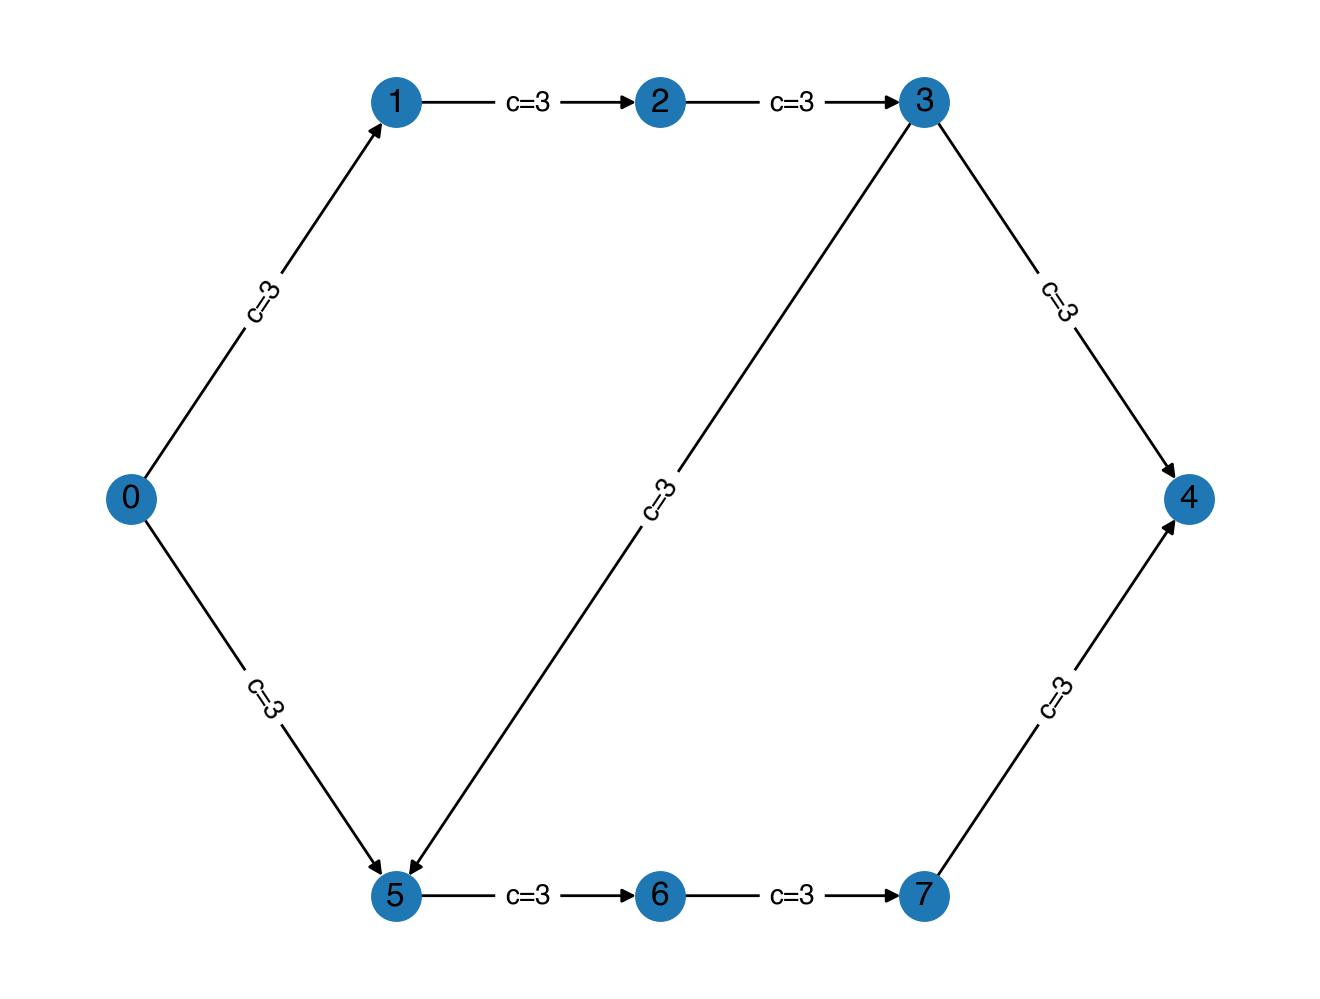

In [834]:
# Plot the graph with 'capacity' labels on edge
nx.draw(G, pos=pos, with_labels=True)
capacity_labels = {(u, v): f"c={data['capacity']}" for u, v, data in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=capacity_labels)
plt.show()

#### Possible paths from source to target
Before we try to obtain the path(s) that can handle have the maximum flow, let's check all the paths from the source (node 0) to the target (node 4).

In [835]:
# Your turn!

# Task:
# Get the list of all simple paths from source to target in the graph G, and save it to 'all_paths' variable

# Input:
# source: the source node
# target: the target node

# Output:
# [[list of nodes in the first path], [list of nodes in the second path], ... ]


source = 0
target = 4

# all_paths = []


In [836]:
# Task:
# Get the list of all simple paths from source to target in the graph G, and save it to 'all_paths' variable

# Input:
# source: the source node
# target: the target node

# Output:
# [[list of nodes in the first path], [list of nodes in the second path], ... ]

source = 0
target = 4

all_paths = list(nx.all_simple_paths(G, source, target))
all_paths

[[0, 1, 2, 3, 4], [0, 1, 2, 3, 5, 6, 7, 4], [0, 5, 6, 7, 4]]

Now, create a 3-panel figure that visualizes each path in the network. Align the subplots horizontally, and set the edge color of the path to green.

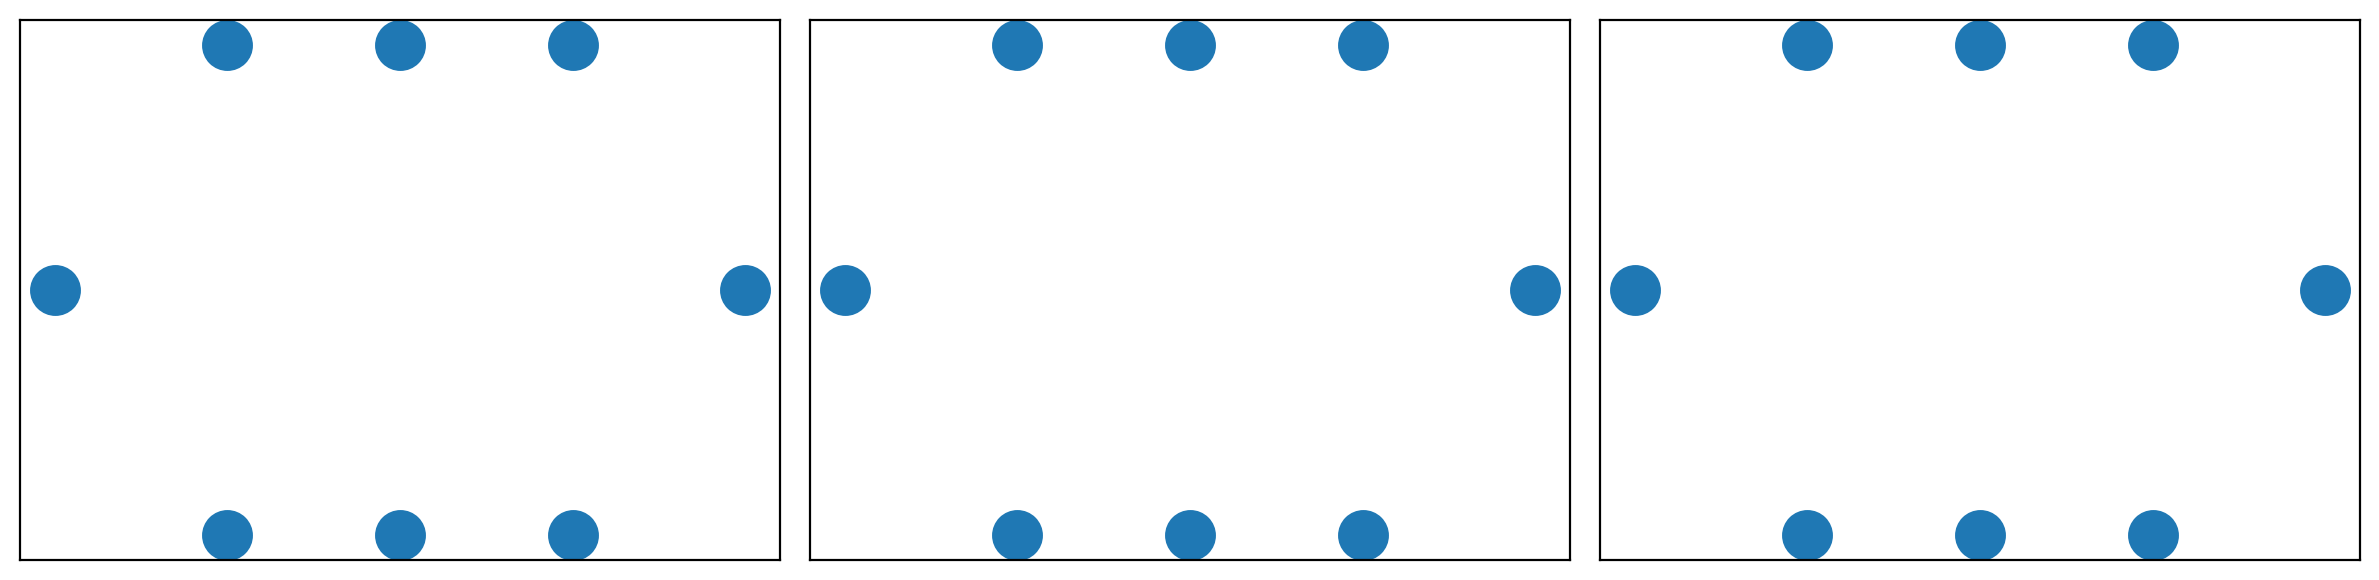

In [ ]:
# Your turn!

# Task:
# Make 3-panel figure that visualizes each path from `all_paths` in the graph G. Draw all edges in black, and the edges in the path in green. Use the following scaffolding code to get started.


fig, ax = plt.subplots(1,3, figsize=(12,3))

for idx, path in enumerate(all_paths):

    # Step 1: Plot the nodes
    nx.draw_networkx_nodes(G, pos, ax=ax[idx])

    # Step 2: Plot the edges of the graph
    # Hint: Use `pos` dictionary for positions

    # Step 3: Plot the edges of the path in green on top
    # Hint: Use edgelist parameter in nx.draw_networkx_edges()

fig.tight_layout()

plt.show()

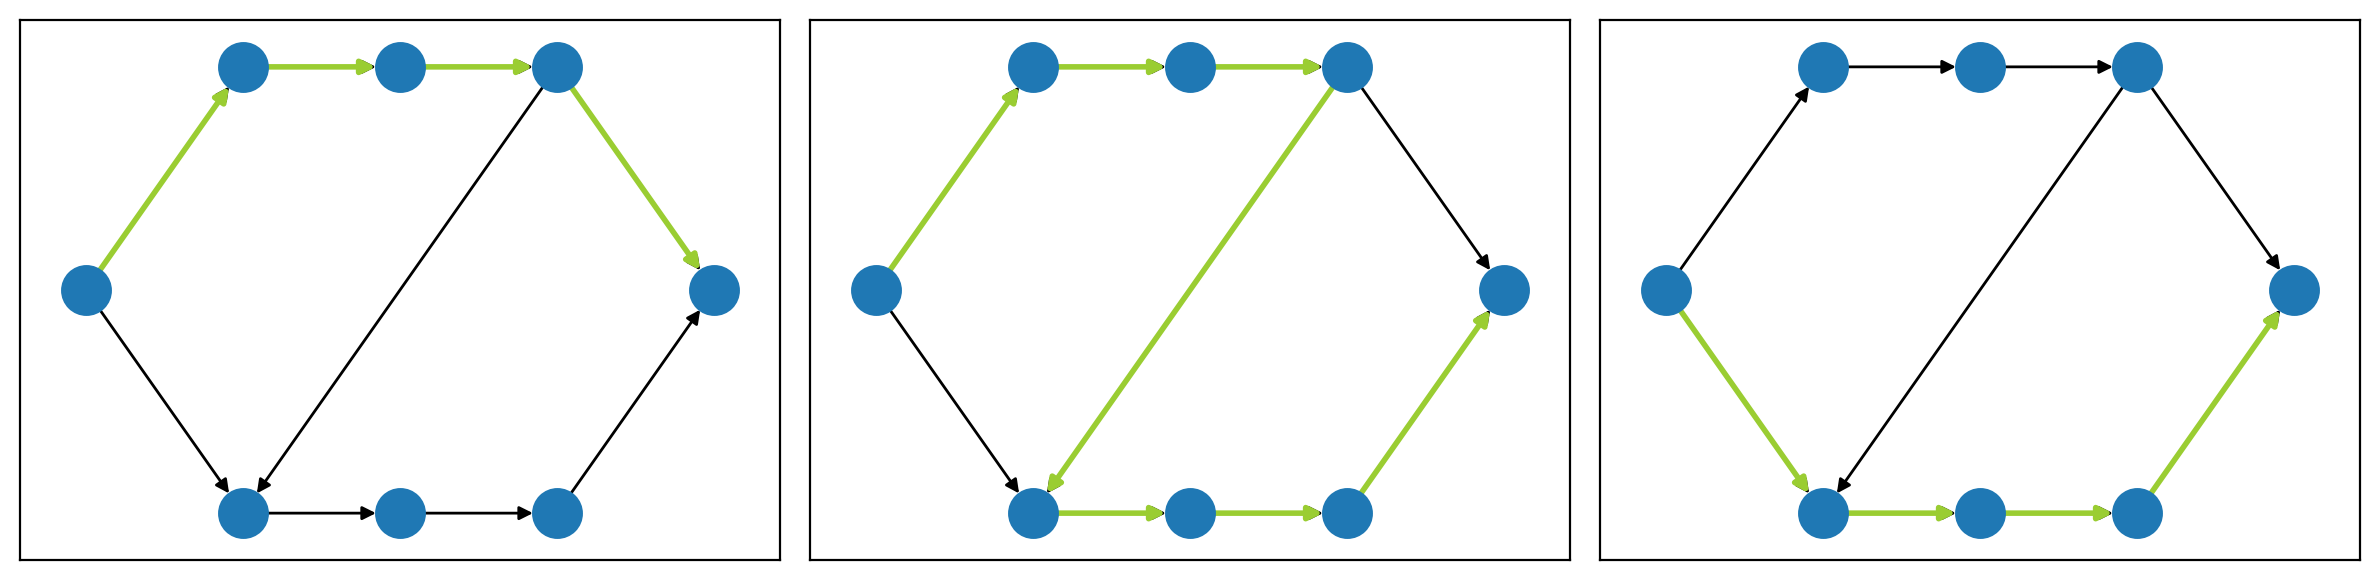

In [ ]:
# Task:
# Make 3-panel figure that visualizes each path from `all_paths` in the graph G. Draw all edges in black, and the edges in the path in "yellowgreen". Use the following scaffolding code to get started.


fig, ax = plt.subplots(1,3, figsize=(12,3))

for idx, path in enumerate(all_paths):

    # Step 1: Plot the nodes
    nx.draw_networkx_nodes(G, pos, ax=ax[idx])

    # Step 2: Plot the edges of the graph
    nx.draw_networkx_edges(G, pos, ax=ax[idx])

    # Step 3: Plot the edges of the path in green on top
    edges = list(zip(path, path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color="yellowgreen", width=2, ax=ax[idx])


fig.tight_layout()

plt.show()

#### Residual network

Now that we know the possible paths from $s$ to $t$, how can we find the paths that can handle the maxium traffic? Before we introduce the augmenting path algorithm to solve this, we need to know a bit about a convinient tool that we use called **residual graph**.

In [839]:
# Function to create a figure to illustrate the concept of residual network
def residual_network_concept_figure():

    # ===== Base graph =====
    # Another sample graph
    G2 = nx.DiGraph()
    G2.add_edge(0, 1, capacity=10, flow=1)
    pos2 = {0: [0, 0], 1: [1, 0]}


    # ===== Residual network construction =====
    # Make a new graph as the base of residual graph
    R2 = nx.DiGraph()
    R2.add_nodes_from(G2.nodes)

    # Add forward capacity
    R2.add_edge(0, 1, capacity=9)

    # Add backward capacity
    R2.add_edge(1, 0, capacity=1)


    # ===== Plot =====
    fig, ax = plt.subplots(1,1, figsize=(8,6))

    # Draw original graph
    nx.draw(G2, pos=pos2, with_labels=True)

    # Add flow and capacity labels of the original graph
    flow_capacity_labels = {(u, v): f"flow {data['flow']} / capacity {data['capacity']}" for u, v, data in G2.edges(data=True)}
    nx.draw_networkx_edge_labels(
        G2,
        pos=pos2,
        edge_labels=flow_capacity_labels,
        ax=ax
    )

    # Preparation for drawing residual graph
    edges = [(u, v) for u, v in R2.edges() if R2.has_edge(u, v)]
    colors = ['blue' if (u, v) in G2.edges() else 'red' for u, v in edges]
    nx.draw_networkx_edges(
        R2, pos2, edgelist=R2.edges(),
        arrowsize=10,
        edge_color=colors,
        connectionstyle="arc3,rad=0.1",
        ax=ax
    )

    # Helper fuction to offset the position of nodes
    def offset_position(pos, offset=-1e-3, direction="y"):
        if direction == "x":
            new_pos = {k: (v[0] + offset, v[1]) for k, v in pos.items()}
        if direction == "y": 
            new_pos = {k: (v[0], v[1] + offset) for k, v in pos.items()}
        return new_pos

    # Draw forward and backward capacities in residual graph
    R2_capacities = nx.get_edge_attributes(R2, 'capacity')
    nx.draw_networkx_edge_labels(
        R2,
        pos=offset_position(pos2, -01e-3, direction="y"),
        edge_labels={(0,1): f"forward capacity {R2_capacities[0,1]}"},
        font_color="blue",
        ax=ax
    )

    nx.draw_networkx_edge_labels(
        R2,
        pos=offset_position(pos2, 01e-3, direction="y"),
        edge_labels={(1,0): f"backward capacity {R2_capacities[1,0]}"},
        font_color="red",
        ax=ax
    )

    fig.show()

    return fig, ax


**Residual graph**, denoted $G_f$, is a directed graph that is defined given a flow network $G$ and its flow $f$. For each node pair $e=(u, v) \in V$, there is a forward edge $e$ with **forward capacity** and a backward edge $e' = (v, u)$  with **backward capacity**. The node set of $G_f$ is the same as that of the original graph $G$ [4].

Here, let's consider a very simple directed graph shown below where there is a edge from node 0 to node 1, $e=(0,1)$, that has a capacity of $c_e=10$ and a flow of $f(e)=1$.

The following figure overlays residual graph $G_f$ (with red and blue edges) over the original graph $G$.

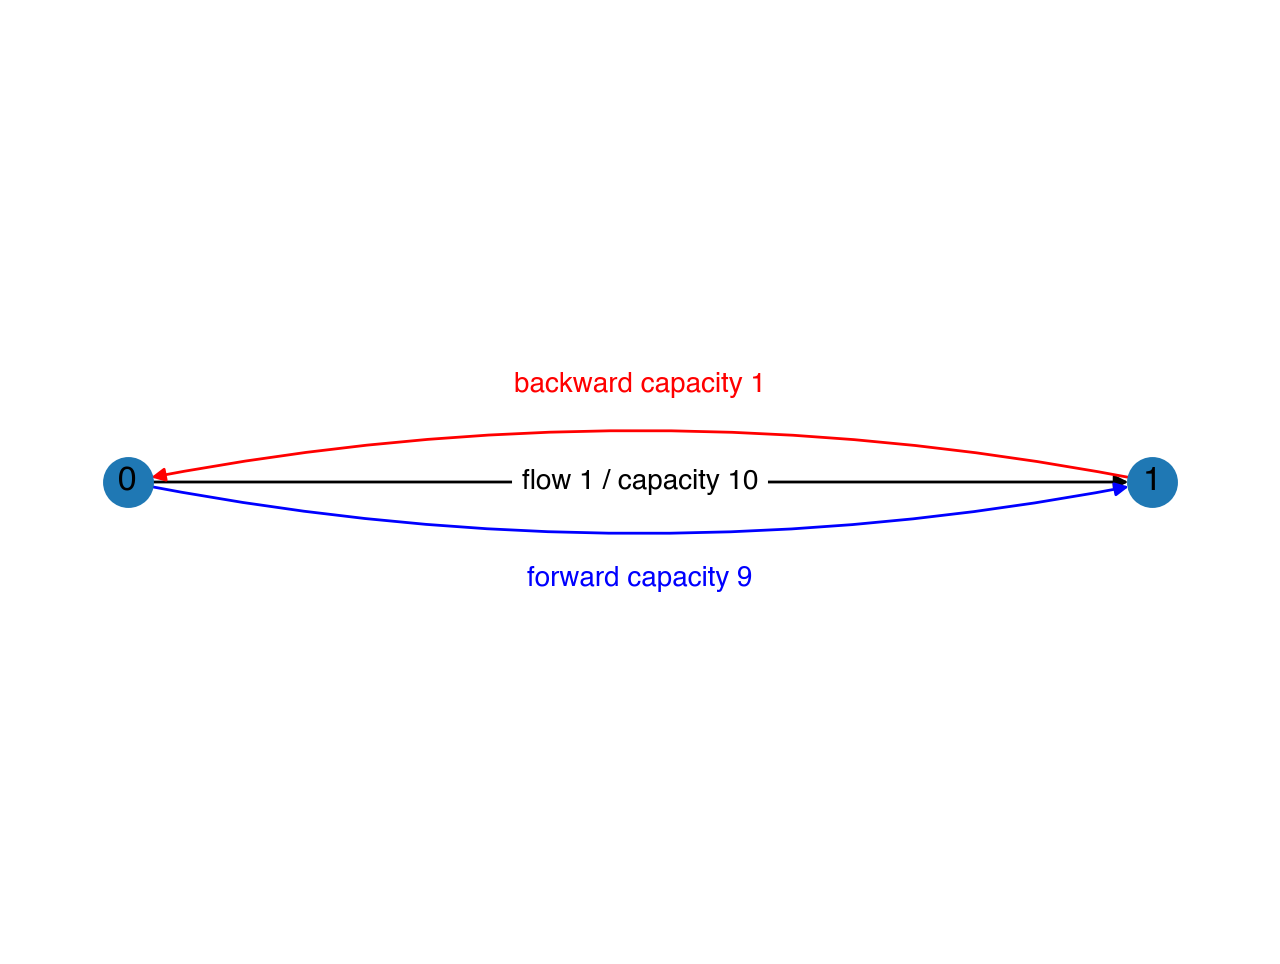

In [840]:
residual_network_concept_figure()
plt.show()


In this case,
- **the forward capacity** (which is the flow that could be added in that direction) is 9, and
- **the backward capacity** (which is the flow that we can "undo" the flow in the opposite direction, $e'$) is 1.

In other words, we can **add 9 more units of flows** in the forward direction (0 to 1), or **revert 1 unit of flow** in the opposite direction (1 to 0).

Generalizing this, there are following edges for each edge $e = (u, v)$ of $G$ given $f$ [4]:
- Forward edge, edge $e = (u, v)$, has capacity of $c_e - f(e)$
- Backward edge, edge $e' = (v, u)$, has capacity of $f(e)$

Note that residual graph $G_f$ continues to be updated as the flow $f$ changes.

In [ ]:
# Generalized function to construct a residual network
def construct_residual_network(G, flow_attribute='flow'):
    """
    Construct a residual network from given network G.add_edge

    Parameters
    ----------
        G: networkx.DiGraph or networkx.Graph
            The network to construct the residual network from
        flow_attribute: str
            The name of the edge attribute used to store the flow. Default is 'flow'

    Returns
    ----------
        R: networkx.DiGraph
            The residual network of G
    """

    R = nx.DiGraph()
    R.add_nodes_from(G.nodes)

    for u, v, data in G.edges(data=True):

        # === Residual capacity ===
        # Capacity of the edge in the original graph
        capacity = data['capacity']

        # If the edge has flow in 'flow' attribute, use that value as current flow
        # Defaults to 0
        try:
            current_flow = nx.get_edge_attributes(G, flow_attribute)[u,v]
        except:
            current_flow = 0

        # The forward capacity 
        forward_capacity = max(0, capacity - current_flow)
        R.add_edge(u, v, capacity=forward_capacity)

        backward_capacity = max(0, current_flow)
        R.add_edge(v, u, capacity=backward_capacity)


        # === Residual cost ===
        if G.has_edge(u, v):
            cost = G.edges[u, v].get('cost', 0)
        else:
            cost = -G.edges[v, u].get('cost', 0)
        
        forward_cost = cost
        backward_cost = -cost
        R.add_edge(u, v, cost=forward_cost)
        R.add_edge(v, u, cost=backward_cost)

    return R

In [ ]:
def filter_residual_graph(R, edge_attribute='capacity'):
    """
    Filter the residual network to only include edges with positive capacity. Resudial network

    Parameters
    ----------
        R : networkx.DiGraph
            The residual network
        edge_attribute : str
            The edge attribute to use for filtering. Default is 'capacity'

    Returns
    -------
        filtered_R : networkx.DiGraph
            The residual network with only edges with positive capacity
    """

    # Make new directed graph
    filtered_R = nx.DiGraph()

    # Copy nodes from R
    filtered_R.add_nodes_from(R.nodes(data=True))
    
    for u, v, data in R.edges(data=True):
        # If the capacity (or other edge attribute) is positive, it will be copied to the new graph
        # Other edge attributes will be copied as well
        if data.get(edge_attribute, 0) > 0:
            filtered_R.add_edge(u, v, **data)
    
    return filtered_R

In [ ]:
def plot_residual_network(R, G, pos=None, fig=None, ax=None):
    """
    Plot a residual network with optional figure and axes.
    
    Parameters
    ----------
        R : networkx.DiGraph
            Residual network to be plotted.
        G : networkx.DiGraph
            Original graph for color reference. Edges in the original graph will be colored 'blue'.
        pos : dict (optional)
            Positions of nodes. Default is nx.spring_layout(R)
        fig : matplotlib.figure.Figure (optional)
            Figure to plot on. Default is None.
        ax : matplotlib.axes.Axes (optional)
            Axes to plot on. Default is None.
    """
    if fig is None or ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.axis('off')

    if pos is None:
        pos = nx.spring_layout(R)
    
    # Draw nodes and node labels
    nx.draw_networkx_nodes(R, pos)
    nx.draw_networkx_labels(R, pos)

    # Set edge colors
    # - Blue edges: forward capacity (edge in the direction as in the original graph)
    # - Red edges: backward capacity (edge in the opposite direction as in the original graph)
    edges = [(u, v) for u, v in R.edges() if R.has_edge(u, v)]
    colors = ['blue' if (u, v) in G.edges() else 'red' for u, v in edges]

    # Draw edges
    nx.draw_networkx_edges(
        R, pos, edgelist=edges,
        arrowsize=10,
        edge_color=colors,
        connectionstyle="arc3,rad=0.1"
    )

    # Set edge label colors
    edge_labels = nx.get_edge_attributes(R, 'capacity')
    label_colors = {edge: 'blue' if (edge in G.edges()) else 'red' for edge in edge_labels}

    # Draw edge labels
    for edge, color in label_colors.items():
        nx.draw_networkx_edge_labels(
            R, pos, edge_labels={edge: edge_labels[edge]},
            label_pos=0.6,
            font_color=color,
            bbox=dict(boxstyle="round,pad=0.2", edgecolor="white", facecolor="white")
        )
    
    plt.show()

Let's see what residual network looks like for the graph we presented above (`G`) where all edges had capacity of 3 and flow of 1.

In [844]:
# Initialize flow on each edge to 1
nx.set_edge_attributes(G, 1, 'flow')

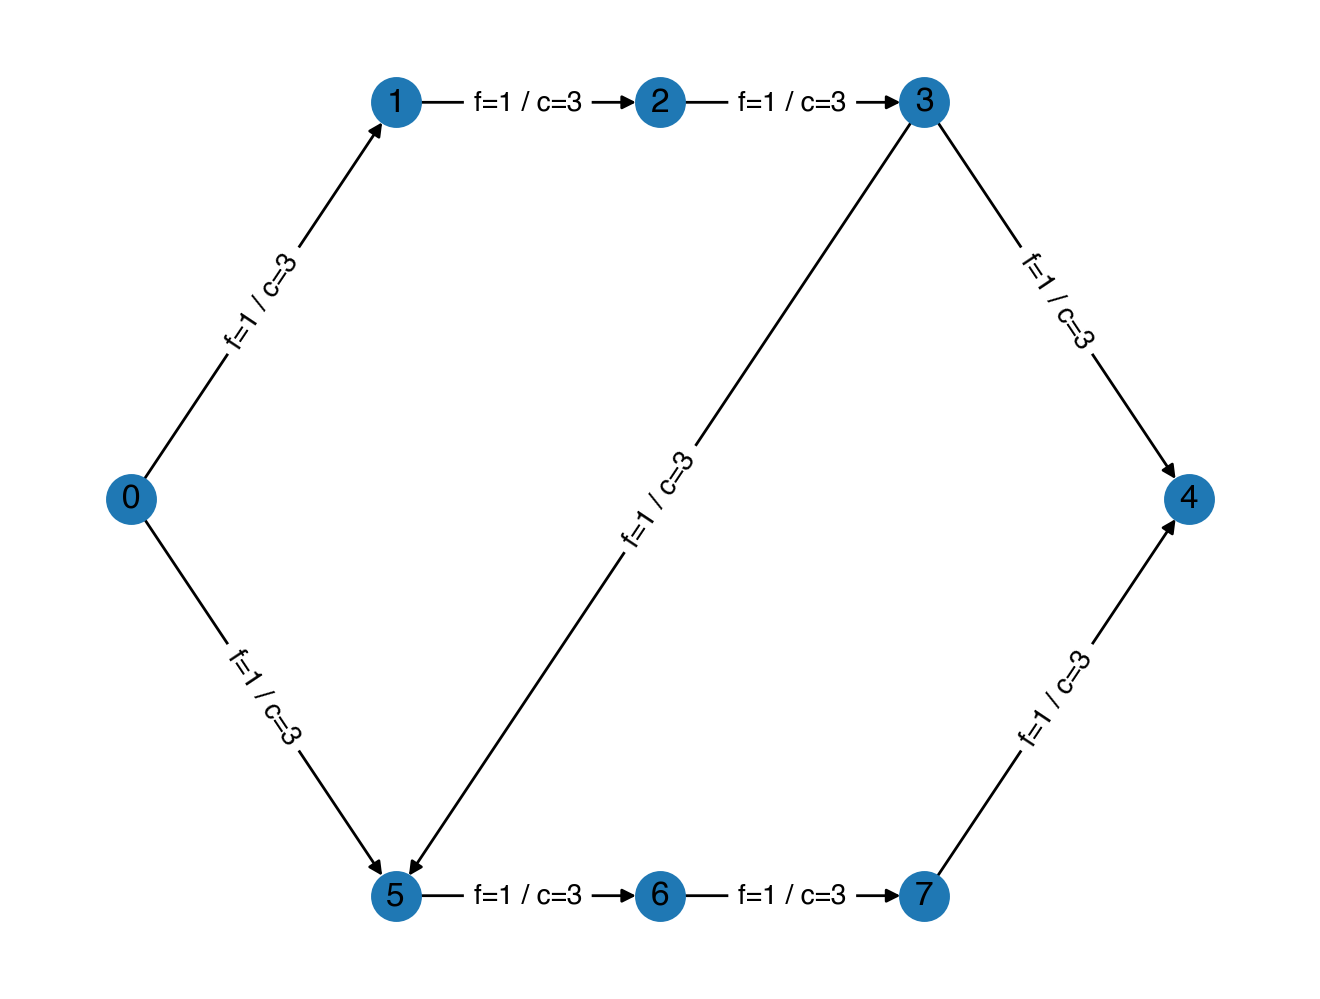

In [845]:
# Confirm the flow and capacity of each edges
nx.draw(G, pos=pos, with_labels=True)
capacity_labels = {(u, v): f"f={data['flow']} / c={data['capacity']}" for u, v, data in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=capacity_labels)
plt.show()

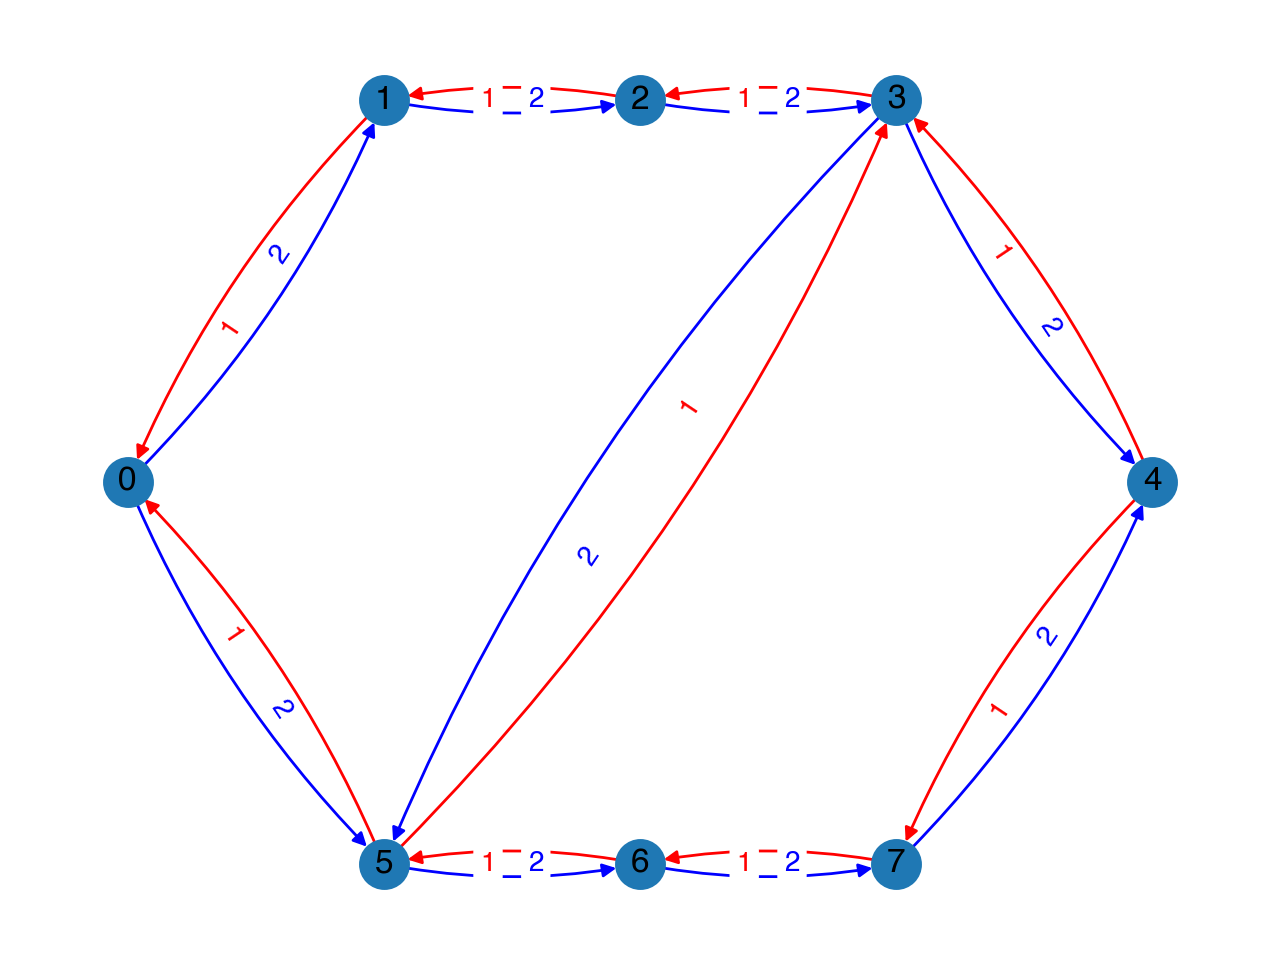

In [846]:
# Residual graph of `G`
R = construct_residual_network(G)
# R = filter_residual_graph(R) # This filters out edges with zero capacity
plot_residual_network(R=R, G=G, pos=pos)

As we observe in the figure and the 'capacity' dictionary,
- the edges in the same direction as the original graph "forward capacity" of 2 (blue) 
- the edges in the opposite direction as the original graph "backward capacity" of 1 (red)

In [847]:
nx.get_edge_attributes(R, 'capacity')

{(0, 1): 2,
 (0, 5): 2,
 (1, 0): 1,
 (1, 2): 2,
 (2, 1): 1,
 (2, 3): 2,
 (3, 2): 1,
 (3, 4): 2,
 (3, 5): 2,
 (4, 3): 1,
 (4, 7): 1,
 (5, 0): 1,
 (5, 3): 1,
 (5, 6): 2,
 (6, 5): 1,
 (6, 7): 2,
 (7, 6): 1,
 (7, 4): 2}

### Augmenting path algorithm (Ford-Fulkerson algorithm)

#### Overview

**Augmenting path algorithm** of Ford and Fulkerson [2] is the simplest method to find the maximum flow in a network. This is **also known as the Ford-Fulkerson algorithm**. The concept behind this algorithm is to
- Find a path from source $s$ to target $t$ using the breadth-first search (BFS) algorithm
- Imagine filling the path (route of water pipes) with water to the capacity. This path cannot carry more flows.
- Find another path from $s$ to $t$ from the remaining edges. Fill the path, and repeat this process until no more path is found.

The important assumption we make here is that we allow the water to flow simultaneously in both ways through the edges. While such flows are not possible in the real world for water pipes, we can imagine that in theory and interpret that the flows "cancel out" with each other if the flow capacity is the same for both directions.

#### Algorithm

This is the steps to carry out the augmenting path algorithm, excerpted from [4].

1. Initialize flow for each edge in $G$ to 0
1. Construct residual graph $G_f$ from $G$
1. While there is a path in residual graph $G_f$:
    - Check that the capacity for for all edges in the path of the residual graph is greater than 0 (There is room for additional flow)
    - Calculate the maximum flow that could be augmented to the path
    - Augment the path

### Implementation
Let's implement the algorithm from scratch!

#### Helper functions
We'll first define some helper functions that we'll use in the main algorithm.

In [ ]:
from collections import deque
def find_all_simple_paths_bfs(G, source, target, sort_paths=False):
    """
    Find all simple paths from source to target using BFS.

    Parameters
    ----------
        G : networkx.Graph
            The graph on which to perform the search.
        source : node
            The starting node for the paths.
        target : node
            The ending node for the paths.
        sort_paths : bool, optional
          If True, the resulting paths will be sorted (default is True).

    Returns
    -------
        paths : list of list of nodes
            A list of all simple paths from source to target. Each path is represented as a list of nodes.
        
    """
    queue = deque([(source, [source])])
    paths = []

    while queue:
        current_node, path = queue.popleft()

        # If we reached the target, add the path to the list
        if current_node == target:
            paths.append(path)
            continue

        for neighbor in G.neighbors(current_node):
            if neighbor not in path:  # Ensure we don't revisit nodes
                queue.append((neighbor, path + [neighbor]))
    
    if sort_paths:
        paths = sorted(paths)
    
    return paths

In [849]:
find_all_simple_paths_bfs(R, 0, 4)

[[0, 5, 3, 4], [0, 1, 2, 3, 4], [0, 5, 6, 7, 4], [0, 1, 2, 3, 5, 6, 7, 4]]

In [850]:
list(nx.all_simple_paths(R, 0, 4))

[[0, 1, 2, 3, 4], [0, 1, 2, 3, 5, 6, 7, 4], [0, 5, 3, 4], [0, 5, 6, 7, 4]]

In [851]:
# Test that the BFS implementation returns the same paths as networkx
sorted(find_all_simple_paths_bfs(R, 0, 4)) == sorted(list(nx.all_simple_paths(R, 0, 4)))

True

In [852]:
def augment_flow(G, R, path, unit_flow=1, update_supply=False, source_node=None, target_node=None):
    """
    Augments the 'flow' along a given path in the graph G and updates the 'capacity' in the residual graph R.

    Parameters
    ----------
        G : networkx.Graph
            The original graph where the flow is being augmented.
        R : networkx.DiGraph
            The residual graph that keeps track of the remaining capacities.
        path : list
            A list of nodes representing the path along which the flow is to be augmented.
        unit_flow : int, optional
            The amount of flow to be augmented along the path (default is 1).
            
    Returns
    -------
        None
    """

    # Get the edges along the path
    edges = zip(path, path[1:])

    for u, v in edges:
        # Update flow in G
        if G.has_edge(u, v):
            G.edges[u, v]['flow'] += unit_flow

        # Update forward and backward capacity in R
        # - forward capacity is reduced by `unit_flow`
        # - Backward capacity is increased by `unit_flow`
        if R.has_edge(u, v):
            R.edges[u, v]['capacity'] -= unit_flow
            # # If it reaches 0, remove the edge
            # if R.edges[u, v]['capacity'] == 0:
            #     R.remove_edge(u, v)
        if R.has_edge(v, u):
            R.edges[v, u]['capacity'] += unit_flow
            # # If it reaches 0, remove the edge
            # if R.edges[v, u]['capacity'] == 0:
            #     R.remove_edge(v, u)

    if update_supply:
        # Update supply of source and target nodes
        # - source node's supply is reduced by `unit_flow`
        # - target node's supply is increased by `unit_flow`
        G.nodes(data=True)[source_node]['supply'] -= unit_flow
        G.nodes(data=True)[target_node]['supply'] += unit_flow


In [853]:
def check_can_flow_over_path(R, path, edge_attribute='capacity'):
    """
    Check if flow can be augmented along a given path in the graph G, using the residual graph R.

    Parameters
    ----------
        G : networkx.Graph
            The original graph where the flow is being augmented.
        R : networkx.DiGraph
            The residual graph that keeps track of the remaining capacities.
        path : list
            A list of nodes representing the path along which the flow is to be augmented.
        edge_attribute : str, optional
            The edge attribute to use for calculating the maximum flow (default is 'capacity').
    
    Returns
    -------
        boolean
            True if flow can be augmented along the path, False otherwise.
    """

    edges = zip(path, path[1:])

    # Not all edges are in R (since edge with capacity 0 is removed)
    edges_in_R = [(u, v) for u, v in edges if R.has_edge(u, v)]

    return all(R.edges[u, v][edge_attribute] > 0 for u, v in edges_in_R)

In [854]:
def calculate_maximum_flow(G, R, path, edge_attribute='capacity'):
    """
    Calculate the maximum flow ("bottleneck") that can be augmented along a given path in the graph G, using the residual graph R.

    Parameters
    ----------
        G : networkx.Graph
            The original graph where the flow is being augmented.
        R : networkx.DiGraph
            The residual graph that keeps track of the remaining capacities.
        path : list
            A list of nodes representing the path along which the flow is to be augmented.
        edge_attribute : str, optional
            The edge attribute to use for calculating the maximum flow (default is 'capacity').
    
    Returns
    -------
        maximum_flow : numeric
            The maximum flow that can be augmented along the path.
    """
    edges = zip(path, path[1:])
    edges_in_R = [(u, v) for u, v in edges if R.has_edge(u, v)]

    maximum_flow = min(G.edges[u,v][edge_attribute] for u, v in edges_in_R)

    return maximum_flow

#### Scratch implementation

In [855]:
# Your turn!

# # Task:
# Write a function `ford_fulkerson()` that calculates the maximum flow in a graph using Ford-Fulkerson algorithm.

def ford_fulkerson(G, source_node, target_node, supress_log=False):
    """
    Calculate the maximum flow in a graph using Ford-Fulkerson algorithm.

    Parameters
    -------
        G : networkx.DiGraph or networkx.Graph
            The graph to calculate the maximum flow.
        source_node : int or str
            The label of the source node of the flow.
        target_node : int or str
            The label of the target node of the flow.
        suppress_log : boolean, optional
            If True, suppress the log output. Default is False.

    Returns
    -------
        G_maxflow: networkx.DiGraph or networkx.Graph
            The original graph after calculating the maximum flow paths. 'flow' attribute is added to each edge.
            
        flows: list of dict
            Each dictionary contains the path (list of nodes) and flow value of the path.
            `[ { 'path:' [0, 1, 2, 3, 4], 'flow': 1 } ]`
        
        max_flow: int
            The value of the maximum flow from source to target.
    """
    
    # Copy the original graph to avoid modifying it, and name it "G_maxflow"
    # We will add the 'flow' attribute to each edges

    
    # Initialize the flow of each edge to 0


    # Construct the residual graph from G_maxflow
    # Make sure to remove edges with zero capacity
    # R = 


    # Get paths from source to target in the residual graph
    paths = []
    
    print("# of simple paths from source to target in R:")
    print(f"{len(paths)}\n")

    # We'll record the paths and flow values of each path that maximizes the flow in the network
    flows = []

    if not supress_log:
        print("Checking if flow can be added in each path:")

    # Iterate over each path
    for path in paths:
        
        # Check if we can argument flow through the path
        # All of the edges in the path should have a forward capacity > 0
        can_flow = True # Change this

        if not supress_log:
            print(f"{path}: {can_flow}")

        if can_flow:
            # Calculate the "bottleneck" of the path
            # additional_flow = 


            # Argument flow along the path
            

            # Record this flow
            flows.append(
                {
                    'path': path,
                    'flow': additional_flow
                }
            )
    
    # Calculate the maximum flow value
    

    return 


In [856]:
# Task:
# Write a function `ford_fulkerson()` that calculates the maximum flow in a graph using Ford-Fulkerson algorithm.

def ford_fulkerson(G, source_node, target_node, supress_log=False):
    """
    Calculate the maximum flow in a graph using Ford-Fulkerson algorithm.

    Parameters
    -------
        G : networkx.DiGraph or networkx.Graph
            The graph to calculate the maximum flow.
        source_node : int or str
            The label of the source node of the flow.
        target_node : int or str
            The label of the target node of the flow.
        suppress_log : boolean, optional
            If True, suppress the log output. Default is False.

    Returns
    -------
        G_maxflow: networkx.DiGraph or networkx.Graph
            The original graph after calculating the maximum flow paths. 'flow' attribute is added to each edge.
            
        flows: list of dict
            Each dictionary contains the path (list of nodes) and flow value of the path.
            `[ { 'path:' [0, 1, 2, 3, 4], 'flow': 1 } ]`
        
        max_flow: int
            The value of the maximum flow from source to target.
    """
    
    # Copy the original graph to avoid modifying it, and name it "G_maxflow"
    # We will add the 'flow' attribute to each edges
    G_maxflow = G.copy()
    
    # Initialize the flow of each edge to 0
    nx.set_edge_attributes(G_maxflow, 0, 'flow')

    # Construct the residual graph from G_maxflow
    # Make sure to remove edges with zero capacity
    R = construct_residual_network(G_maxflow)
    R = filter_residual_graph(R) 

    # Get paths from source to target in the residual graph
    # paths = list(nx.all_simple_paths(R, source_node, target_node))
    paths = find_all_simple_paths_bfs(R, source_node, target_node)
    
    print("# of simple paths from source to target in R:")
    print(f"{len(paths)}\n")

    # We'll record the paths and flow values of each path that maximizes the flow in the network
    flows = []

    if not supress_log:
        print("Checking if flow can be added in each path:")

    # Iterate over each path
    for path in paths:
        
        # Check if we can argument flow through the path
        # All of the edges in the path should have a forward capacity > 0
        can_flow = check_can_flow_over_path(R, path)

        if not supress_log:
            print(f"{path}: {can_flow}")

        if can_flow:
            # Calculate the "bottleneck" of the path
            additional_flow = calculate_maximum_flow(G_maxflow, R, path)

            # Argument flow along the path
            augment_flow(G_maxflow, R, path, unit_flow=additional_flow)

            # Record this flow
            flows.append(
                {
                    'path': path,
                    'flow': additional_flow
                }
            )
    
    # Calculate the maximum flow value
    max_flow_value = sum(flow['flow'] for flow in flows)

    return G_maxflow, flows, max_flow_value


In [857]:
G_maxflow, flows, max_flow_value = ford_fulkerson(G, 0, 4)

# of simple paths from source to target in R:
3

Checking if flow can be added in each path:
[0, 1, 2, 3, 4]: True
[0, 5, 6, 7, 4]: True
[0, 1, 2, 3, 5, 6, 7, 4]: False


In [858]:
# The path that maximizes the flow in the network
flows

[{'path': [0, 1, 2, 3, 4], 'flow': 3}, {'path': [0, 5, 6, 7, 4], 'flow': 3}]

In [859]:
# Extract the paths with maximum flow
max_flow_paths = [flow['path'] for flow in flows]
max_flow_paths

[[0, 1, 2, 3, 4], [0, 5, 6, 7, 4]]

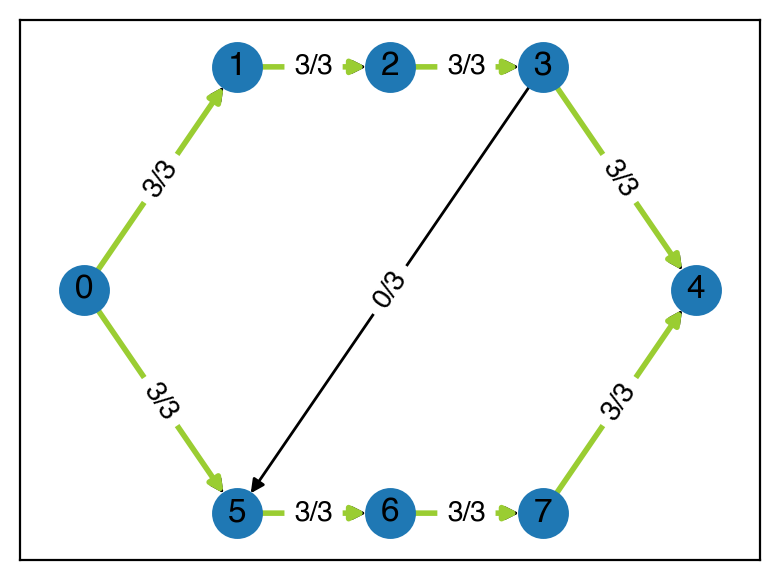

In [860]:
# Visualize the max flow
fig, ax = plt.subplots(1,1, figsize=(4,3))

# Step 1: Plot the node and node label
nx.draw_networkx_nodes(G_maxflow, pos, ax=ax)
nx.draw_networkx_labels(G_maxflow, pos, ax=ax)

# Step 2: Plot the edges of the graph
nx.draw_networkx_edges(G_maxflow, pos, ax=ax)

# Step 3: Plot edges with flow in "yellowgreen"
for idx, path in enumerate(max_flow_paths):

    # Step 3: Plot the edges of the path in red on top
    edges = list(zip(path, path[1:]))
    nx.draw_networkx_edges(G_maxflow, pos, edgelist=edges, edge_color="yellowgreen", width=2, ax=ax)

edge_labels = {
    (u, v): f"{data['flow']}/{data['capacity']}" \
        for u, v, data in G_maxflow.edges(data=True)
}

# Plot edge labels (flow/capacity)
nx.draw_networkx_edge_labels(G_maxflow, pos=pos, edge_labels=edge_labels, ax=ax)


fig.tight_layout()

plt.show()

In [861]:
# The maximum flow of the network
max_flow_value

6

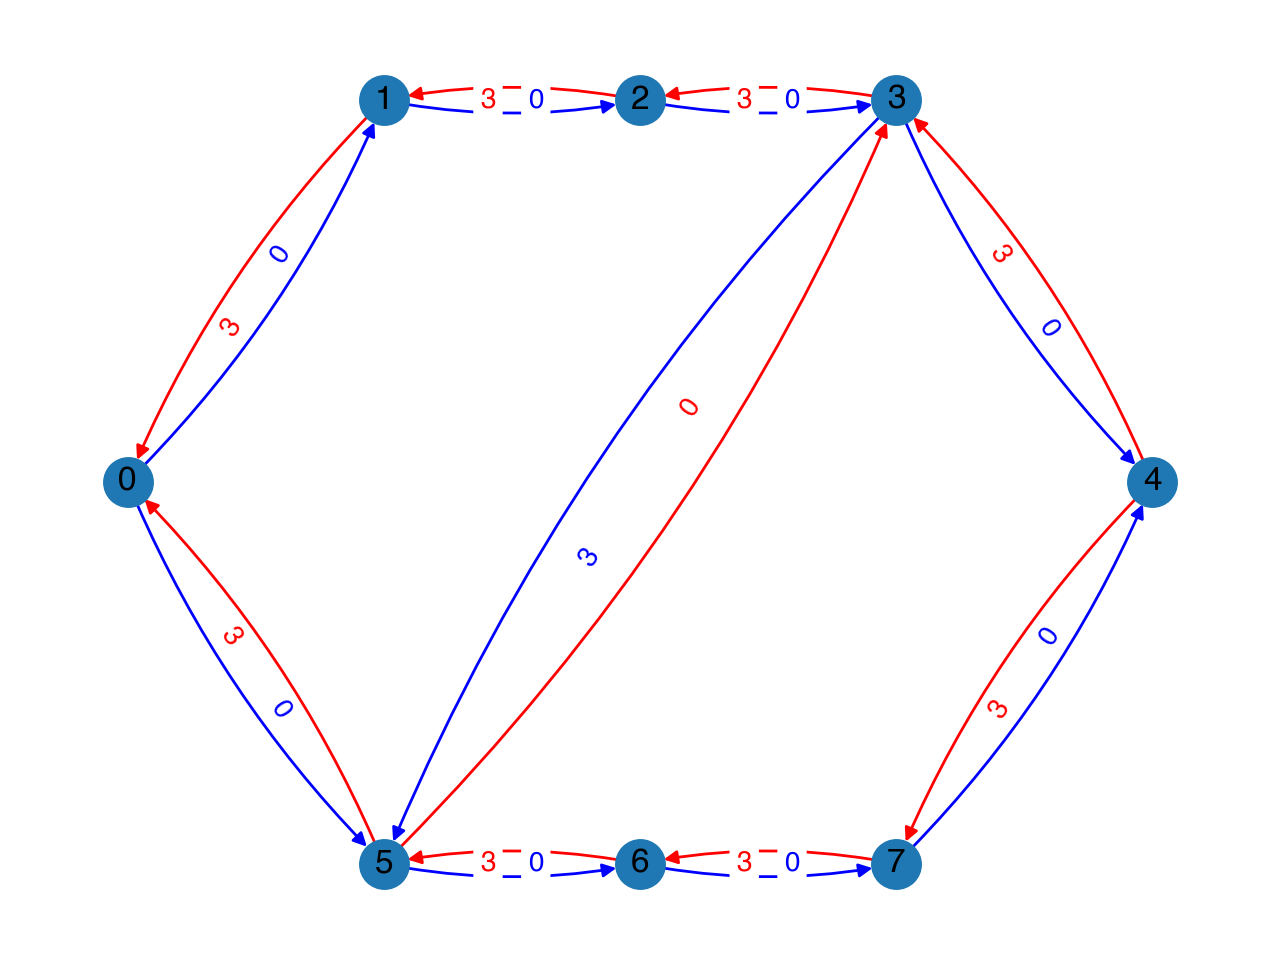

In [862]:
# Residual network for the graph with maximum flow
plot_residual_network(
    R=construct_residual_network(G_maxflow),
    G=G,
    pos=pos
)

#### NetworkX implementations
Let's see if the results from scratch implementation matches the implementation from networkx

In [863]:
max_flow_value_nx, flow_dict_nx = nx.maximum_flow(G, 0, 4)
print(max_flow_value_nx)
print(flow_dict_nx)

6
{0: {1: 3, 5: 3}, 1: {2: 3}, 2: {3: 3}, 3: {4: 3, 5: 0}, 4: {}, 5: {6: 3}, 6: {7: 3}, 7: {4: 3}}


In [864]:
# Compare maximum flow value from scratch implementation of augmenting path algorithm and networkx
max_flow_value == max_flow_value_nx

True

In [865]:
# Reconstruct paths in the flow from flow_dict
def generate_paths_from_flow_dict(flow_dict, source_node, target_node):
    """
    Reconstruct paths in the flow from flow_dict.clear

    Parameters
    ----------
        flow_dict : dict
            The dictionary containing the flow values.
            ```
            flow_value, flow_dict = nx.maximum_flow(G, s, t)
            ``` 
        source_node : int or str
            The source node of the flow.
        target_node : int or str
            The target node of the flow.
    
    Returns
    -------
        paths : list of list
            A list of paths from source to target in the flow.
    """
    paths = []
    visited = set()

    def dfs(node, path):
        if node == target_node:
            paths.append(path)
            return True
        visited.add(node)
        for neighbor, flow in flow_dict[node].items():
            if flow > 0 and neighbor not in visited:
                dfs(neighbor, path + [neighbor])

    dfs(source_node, [source_node])
    return paths

In [866]:
# Reconstruct the paths from the flow dictionary
max_flow_paths_nx = generate_paths_from_flow_dict(flow_dict_nx, 0, 4)
max_flow_paths_nx

[[0, 1, 2, 3, 4], [0, 5, 6, 7, 4]]

In [867]:
# Test that the paths are the same
sorted(max_flow_paths) == sorted(max_flow_paths_nx)

True

#### Testing on larger networks
Let's test this algorithm on a larger network!

In [ ]:
def generate_directed_random_graph(gamma, n):
    """
    Generate a directed random graph using the directed configuration model.

    Parameters
    ----------
        gamma : float
            The exponent parameter for the Zipf distribution.
        n : int
            The number of nodes in the graph.

    Returns
    -------
        G : networkx.DiGraph
            A directed graph generated using the directed configuration model.
    
    """


    # Create in-degree and out-degree sequences
    in_degree_sequence = np.random.zipf(a=gamma, size=n)
    out_degree_sequence = np.random.zipf(a=gamma, size=n)

    # Ensure the sum of in-degrees equals the sum of out-degrees
    while in_degree_sequence.sum() != out_degree_sequence.sum():
        in_degree_sequence = np.random.zipf(a=gamma, size=n)
        out_degree_sequence = np.random.zipf(a=gamma, size=n)

    # Create the directed graph using the directed configuration model
    G = nx.directed_configuration_model(in_degree_sequence, out_degree_sequence)

    # Remove parallel edges and self-loops
    G = nx.DiGraph(G)  # Convert to simple directed graph
    G.remove_edges_from(nx.selfloop_edges(G))

    return G

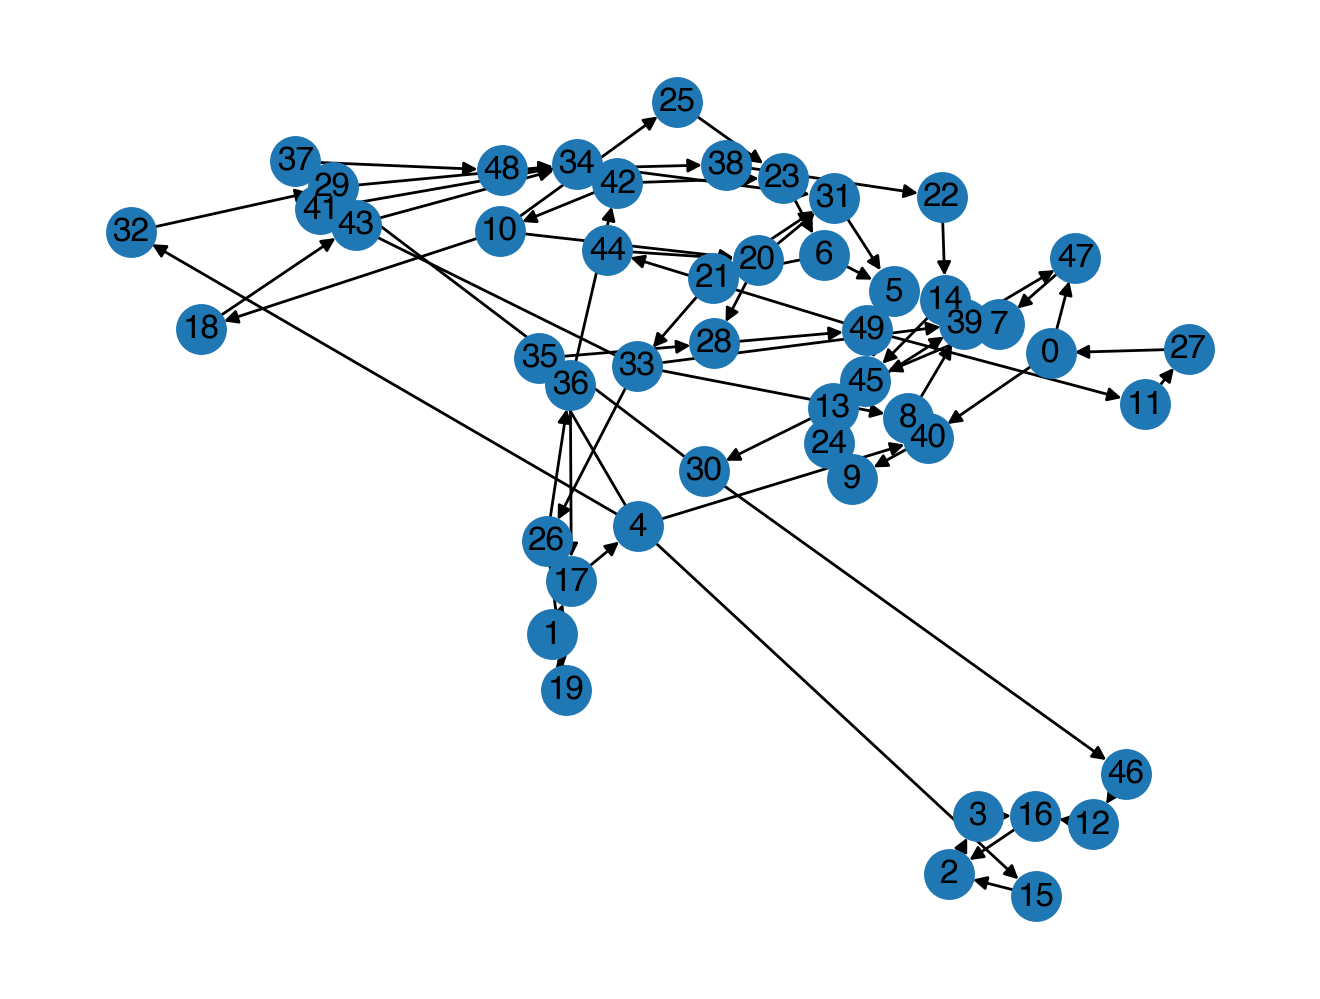

In [869]:
# Generate directed graph with configuration model
G3 = generate_directed_random_graph(gamma=3, n=50)

# Randomly assign capacity
for edge in G3.edges():
    G3[edge[0]][edge[1]]['capacity'] = np.random.randint(0, 100)

# Draw the graph
nx.draw(G3, with_labels=True)
plt.show()

In [ ]:
def select_nodes_randomly_from_lscc(G):
    """
    Select source and target node randomly from the largest strongly connected component of the graph.

    Parameters
    ----------
        G : networkx.DiGraph
            The graph from which to select the nodes.

    Returns
    -------
        source, target : tuple
            The selected source and target nodes.
    """

    # Get the largest strongly connected component
    lscc = max(nx.strongly_connected_components(G), key=len)

    # Create a subgraph of the largest connected component
    G_lscc = G.subgraph(lscc).copy()

    # Choose source and target nodes randomly
    source, target = random.sample(list(G_lscc.nodes()), k=2)

    return source, target

In [871]:
source_random, target_random = select_nodes_randomly_from_lscc(G3)
print("Randomly selected source and targets:")
print(f'Source: {source_random}')
print(f'Target: {target_random}')

Randomly selected source and targets:
Source: 48
Target: 30


In [872]:
# Scratch implementation
G_maxflow_random, flows_random, max_flow_value_random = \
    ford_fulkerson(G3, source_random, target_random, supress_log=True)

# of simple paths from source to target in R:
1



In [873]:
max_flow_value_random_nx, flow_dict_random_nx = nx.maximum_flow(G3, source_random, target_random)

In [874]:
print("Maximum flow value from scratch implementation:")
print(max_flow_value_random)

print("Maximum flow value from networkx:")
print(max_flow_value_random_nx)

print("Do they match?")
print( max_flow_value_random == max_flow_value_random_nx )

Maximum flow value from scratch implementation:
7
Maximum flow value from networkx:
7
Do they match?
True


In [875]:
max_flow_paths_random = [flow['path'] for flow in flows_random]
max_flow_paths_random_nx = generate_paths_from_flow_dict(flow_dict_random_nx, source_random, target_random)

print("Paths from scratch implementation:")
print(max_flow_paths_random)

print("Paths from networkx:")
print(max_flow_paths_random_nx)

print("Do they match?")
print(max_flow_paths_random == max_flow_paths_random_nx)

Paths from scratch implementation:
[[48, 38, 22, 14, 45, 24, 9, 13, 30]]
Paths from networkx:
[[48, 38, 22, 14, 45, 24, 9, 13, 30]]
Do they match?
True


### Discussion
Augmenting path algorithm is a primitive yet powerful algorithm to solve the maximum flow problem, which could be used to in settings such as water or logistic flows.

Even after nearly 70 years since the first proposal of the algorithm by Ford and Fulkerson, approaches to solving maximum flow problem is still evolving. In 2022, a dramatically faster algorithm to compute the maximum flow was proposed:
- Li Chen et al. "Maximum Flow and Minimum-Cost Flow in Almost-Linear Time" https://arxiv.org/abs/2203.00671

***
<h2 id="min-cost-flow">4. Minimum-Cost Flow Problem</h2>


### Outline of this section
- Understand the problem
- Understand the concept/algorithm
- Implement the algorithm in scratch
- Apply it on sample network data

### Introduction
We have learned a simple yet powerful algorithm, that is augmenting path algorithm, that can find the flow that maximizes the flow in a given network. But **do we always want to maximize the flow**? It really depends on the setting, it is common that we want to find flows such that minimizes the cost instead of just maximizing the flow. **Minimum-cost flow problem** is a problem that addresses such conditions to optimize an network.

One of the simple application of minimum-cost flow problem is observed in **logistics**. Imagine that you've ordered an item on Amazon and the package is departing **from a warehouse in Syracuse NY heading Boston MA**. It takes around 5 hours by trucks, or an hour by plane. Ignoring the difference in the duration because it would arrive in the next day for whichever mode is used, the "optimal" route that Amazon chooses here would be to use the land route, because **the shipping cost is presumably significantly lower for the trucks than the planes**.

<!-- While there could be multiple possible routes for the Amazon to route your package from the warehouse to your apartment, they are probably choosing the route that can at most minimize the logstics fee.  -->



### Problem Statement
In a **minimum-cost flow problem**, we are minimizing the cost of flow for a given directed network with **capacities and costs on each edges** as follows [5]:
$$
\underset{f} {\operatorname{argmin}} \, z(f) = \sum_{ij} a_{ij} f_{ij}
$$
where $a$ and $f$ respectively denotes the cost and the flow. We also use the dollar sign $\$$ time-to-time to represent the cost, particularly when drawing conceptual figures. The difference with the maximum-flow problem is that **cost has been added as a new constraint** for each edge.

The problem is subject to following constraints[5]:
- Capacity conditions: For each edge $(i, j)$ in $E$,
$$
f_{ij} \leq c_{ij}
$$
- Conservation conditions: For each node $j$,
$$
\sum_{j : (i, j) \in E} f_{ij} - \sum_{j : (j, i) \in E} f_{ji} = b(i)
$$

Note that the conservation condition is slightly different from the one in maximum flow problem, where the right-hand side was one. This is because we are generalizing the problem by introducing a concept called **flow balance** $b(v)$ for each node $v$ in a network [5]. If $b(v) > 0$, a flow is coming out and is acting as a **supply**. If $b(v) < 0$, a flow is absorved at the node and is acting as a **demand**. Nodes with $b(v) = 0$ does not provide supply nor consume flows but only relays the flow. Using the concept of flow balance allows multiple sources and sinks to exist at the same time in a network. For convinience, **we'll just call $b(s)$ as supply** in this notebook. Positive supply is equivalent to negative demand, and vice versa.

While the source and sink were limited to respectively one node in the maximum flow problem, the introduction of flow balance relaxes the assumption of the network. A network with a single source $s$ and a single sink $t$ could be regarded as the **special case** in terms of $b(v)$, where there is respectively single node with $b(s) < -1$ and $b(t) > -1$.

### Understanding costs

Let's reuse the same graph from maximum flow problem to demonstrate the minimum-cost flow problem. The only difference from the previous is that "cost" was added to all nodes, and "supply" was set to node 0 and 4 (each with value of 1 and -1).

Notice that there are **negative costs on some edges**.

In [876]:
# Set costs to each edges
for edge in G.edges():
    G[edge[0]][edge[1]]['cost'] = 1 # default cost is 1
G[0][1]['cost'] = -100 # cost can be negative!
G[0][5]['cost'] = 100
G[3][4]['cost'] = 100
G[3][5]['cost'] = 1000
G[7][4]['cost'] = 100

In [877]:
# We can use any cost values!
# for edge in G.edges():
#     G[edge[0]][edge[1]]['cost'] = 1
# G[0][1]['cost'] = -100
# G[0][5]['cost'] = 1000
# G[3][4]['cost'] = 10000
# G[3][5]['cost'] = 1
# G[7][4]['cost'] = 100

In [878]:
# Set supply to source and target nodes
nx.set_node_attributes(G, 0, 'supply')
G.nodes(data=True)[0]['supply'] = 1
G.nodes(data=True)[4]['supply'] = -1

In [879]:
def convert_supply_to_demand(G):
    """
    Convert the supply attribute of nodes to demand attribute. Supply and demands are opposite in network flow problems. Positive supply means negative demand, and vice versa. We need this conversion because the nx.min_cost_flow() uses demand, instead of supply

    Parameters
    ----------
        G : networkx.DiGraph
            The graph in which to convert the supply attribute to demand attribute.

    Returns
    -------
        G : networkx.DiGraph
            The graph with the 'demand' attribute. (-1*supply)
    """

    for node in G.nodes():
        if 'supply' in G.nodes[node]:
            G.nodes[node]['demand'] = -G.nodes[node]['supply']

    return G

In [880]:
# We need this conversion because the nx.min_cost_flow() uses demand, instead of supply
G = convert_supply_to_demand(G)

In [881]:
# Confirm supply and demand on each node
list(G.nodes(data=True))

[(0, {'supply': 1, 'demand': -1}),
 (1, {'supply': 0, 'demand': 0}),
 (2, {'supply': 0, 'demand': 0}),
 (3, {'supply': 0, 'demand': 0}),
 (4, {'supply': -1, 'demand': 1}),
 (5, {'supply': 0, 'demand': 0}),
 (6, {'supply': 0, 'demand': 0}),
 (7, {'supply': 0, 'demand': 0})]

In [882]:
# Confirm costs on each edge
list(G.edges(data=True))

[(0, 1, {'capacity': 3, 'flow': 1, 'cost': -100}),
 (0, 5, {'capacity': 3, 'flow': 1, 'cost': 100}),
 (1, 2, {'capacity': 3, 'flow': 1, 'cost': 1}),
 (2, 3, {'capacity': 3, 'flow': 1, 'cost': 1}),
 (3, 4, {'capacity': 3, 'flow': 1, 'cost': 100}),
 (3, 5, {'capacity': 3, 'flow': 1, 'cost': 1000}),
 (5, 6, {'capacity': 3, 'flow': 1, 'cost': 1}),
 (6, 7, {'capacity': 3, 'flow': 1, 'cost': 1}),
 (7, 4, {'capacity': 3, 'flow': 1, 'cost': 100})]

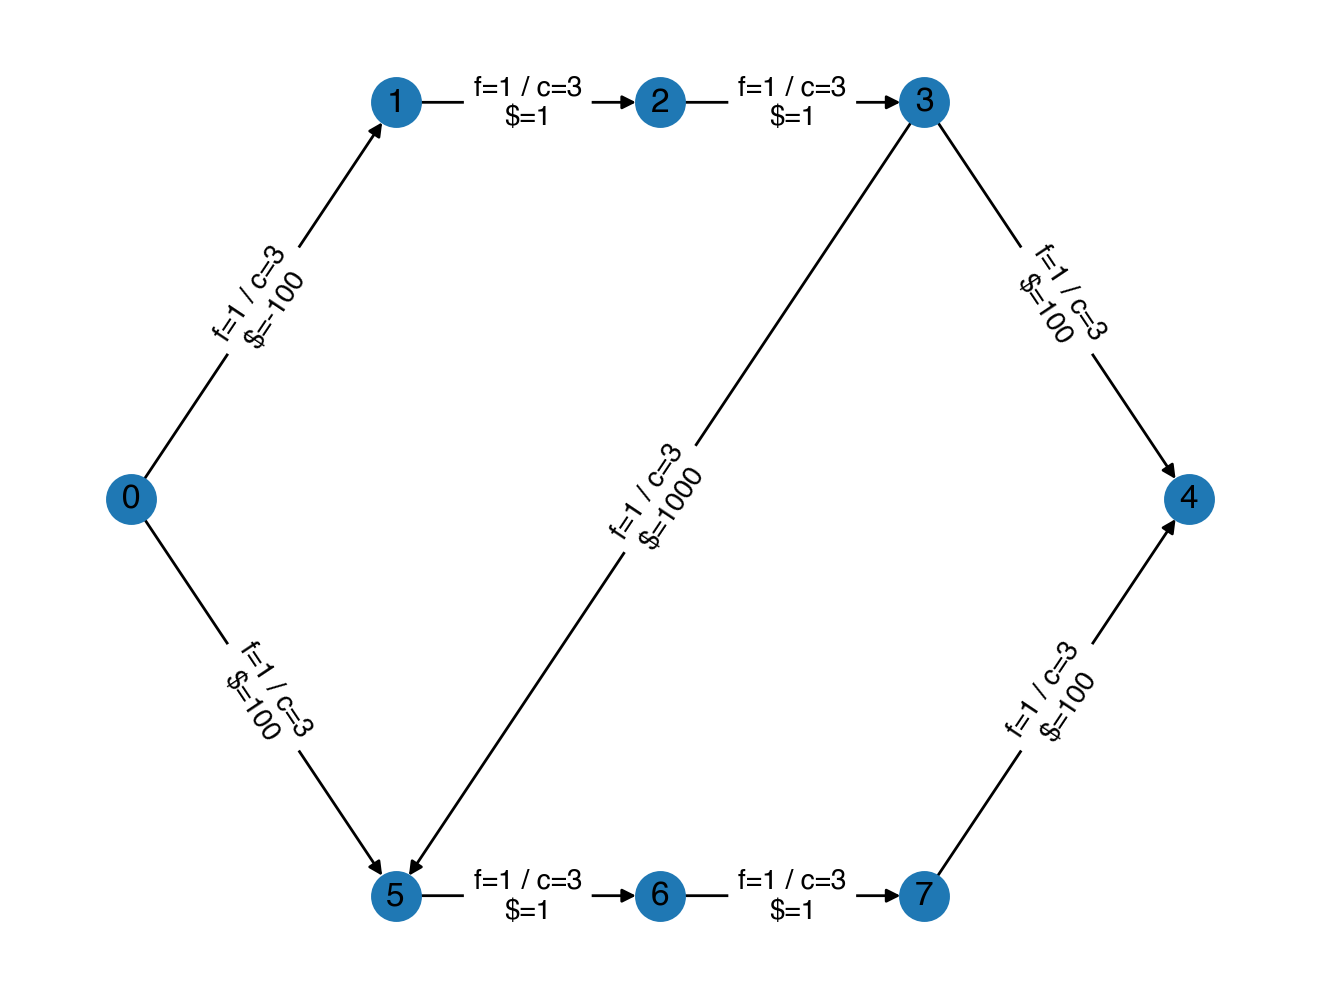

In [883]:
nx.draw(G, pos=pos, with_labels=True)
edge_labels = {(u, v): f"f={data['flow']} / c={data['capacity']}\n$={data['cost']}" for u, v, data in G.edges(data=True)}

nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels)
plt.show()

### Successive shortest path algorithm

#### Overview
**Successive shortest path algorithm** is one of the major algorithms to iteratively solve the minimum-cost flow problem [5]. Similar to the augmenting path algorithm for maximum flow problem, the algorithm **leverages the residual network** to determine the amount of flow that can be augmented along a path. By calculating the **shortest path with regard to the cost** from the source node with $b(v)>0$ to the target node with $b(v)<0$, the algorithm accounts for the costs in the network.

While we'll not cover in this chapter, **cycle-canceling algorithm** [6] is also an another algorithm to solve the minimum-cost flow problem.

#### Algorithm
The algorithm follows following steps [7]:
- Initialize the flow of each edge to 0
- Choose source $s$ and sink $t$ by the supply value.
    - Source would be node $s$ with $b(s) > 0$
    - Sink/target would be node $t$ with $b(t) < 0$
    - If none exist, terminate
- Construct residual graph $R$ from the graph
- While source and sink nodes exist:
    - Calculate the shortest path from $s$ to $t$ with positive capacity, with regard to cost in network. We used Bellman-Ford algorithm to allow for negative costs.
    - Check that a flow can be augmented along the path. All of the edges in the path should have a forward capacity > 0
    - Calculate the "bottleneck" of the path $\Delta$, which is the maximum amount of flow that can be augmented along the path
    - Augment flow along the path
        - Add $\Delta$ to the forward link
        - Subtract $\Delta$ from the reverse link
        - Add $\Delta$ to $b(t)$
        - Subtract $\Delta$ from $b(s)$
    - Choose source $s$ and sink $t$ by the supply value.

### Implementation

#### Helper functions
We'll first define some helper functions that we'll use in the main algorithm.

In [884]:
def get_nodes_by_supply(G, node_type=None, supply_attribute='supply'):

    if node_type is None:
        print("node_type should be 'source' or 'target'")
        return None
    
    if node_type == 'source':
        # source is node with positive supply (== negative demand)
        target_nodes = [node for node, supply in nx.get_node_attributes(G, supply_attribute).items() if supply > 0]
    elif node_type == 'target':
        # source is node with negative supply (== positive demand)
        target_nodes = [node for node, supply in nx.get_node_attributes(G, supply_attribute).items() if supply < 0]

    # if len(target_nodes) > 0:
    #     print(f"Supply of {node_type} ({target_nodes[0]}): {G.nodes(data=True)[target_nodes[0]][supply_attribute]}")
        
    # There could be more than one!
    return target_nodes

In [885]:
get_nodes_by_supply(G, 'source')

[0]

In [886]:
get_nodes_by_supply(G, 'target')

[4]

In [887]:
def sum_edge_attribute_over_path(G, path, edge_attribute):
    """
    Calculate the sum of an edge attribute for all edges along a path.

    Parameters
    ----------
        G : networkx.Graph
            The graph to calculate the sum of the edge attribute.
        path : list
            A list of nodes representing the path over which to calculate the sum.
        edge_attribute : str
            The name of the edge attribute to sum over the path.

    Returns
    -------
        sum_value : float
            The sum of the edge attribute over the path.
    """

    edges = zip(path, path[1:])
    sum_value = sum(G.edges[u, v][edge_attribute] for u, v in edges)
    
    return sum_value

In [888]:
def calculate_maximum_flow_sspa(G, R, path, source_node, target_node, edge_attribute='capacity'):

    """
    Calculate the maximum flow that can be augmented along a given pathin the graph G, using the residual graph R. This function is used in the Shortest Path Augmentation Algorithm, where supply is specified for source and target nodes.

    Parameters
    ----------
        G : networkx.Graph
            The original graph where the flow is being augmented.
        R : networkx.DiGraph
            The residual graph that keeps track of the remaining capacities.
        path : list
            A list of nodes representing the path along which the flow is to be augmented.
        source_node: str or int
            The name of the source node. Used to get the supply of the source node.
        target_node: str or int
            The name of the target node. Used to get the supply of the source node.
        edge_attribute : str, optional
            The edge attribute to use for calculating the maximum flow (default is 'capacity').
    
    Returns
    -------
        maximum_flow : numeric
            The maximum flow that can be augmented along the path.
    """
    
    edges = zip(path, path[1:])
    min_list= [R.edges[u,v][edge_attribute] for u, v in edges]

    # Get supply for source and target nodes
    # Note that we take absolute value of the supply of the target node (because supply at the target node is negative)
    source_supply = G.nodes(data=True)[source_node]['supply']
    target_supply = abs(G.nodes(data=True)[target_node]['supply'])

    min_list.extend([source_supply,target_supply])
    maximum_flow = min(min_list)
    
    return maximum_flow

#### Scratch implementation

In [889]:
def successive_shortest_path_algorithm(G, supress_log=False):
    """
    Calculate the flow with minimum cost in a graph using Successive Shortest Path Algorithm.

    Parameters
    -------
        G : networkx.DiGraph or networkx.Graph
            The graph to calculate the maximum flow.
        source_node : int or str
            The label of the source node of the flow.
        target_node : int or str
            The label of the target node of the flow.
        suppress_log : boolean, optional
            If True, suppress the log output. Default is False.

    Returns
    -------
        G_mincost: networkx.DiGraph or networkx.Graph
            The original graph with minimum cost. 'flow' attribute is added/updated for each edge.
            
        flows: list of dict
            Each dictionary contains the path (list of nodes) and flow value of the path.
            `[ { 'path:' [0, 1, 2, 3, 4], 'flow': 1 } ]`
        
        min_cost_value: int
            The value of the minimum cost along paths in flow from source to target.
    """
    
    # Copy the original graph to avoid modifying it
    # We will add the 'flow' attribute to each edges
    G_mincost = G.copy()
    
    # Initialize the flow of each edge to 0
    nx.set_edge_attributes(G_mincost, 0, 'flow')

    # Choose source and sink by supply value
    source_nodes = get_nodes_by_supply(G_mincost, node_type='source')
    target_nodes = get_nodes_by_supply(G_mincost, node_type='target')

    # Construct the residual graph
    R = construct_residual_network(G_mincost)
    R = filter_residual_graph(R, edge_attribute='capacity')

    # We'll record the paths and flow values of each path that maximizes the flow in the network
    flows = []

    while (len(source_nodes) > 0 and len(target_nodes) > 0):

        source_node = source_nodes[0]
        target_node = target_nodes[0]

        print(source_node, target_node)

        # Calculate the shortest path from source to target in the residual graph
        # We use Bellman-Ford algorithm to handle negative edge weights [9]
        try:
            path = list(
                nx.shortest_path(R, source_node, target_node, weight='cost', method='bellman-ford')
            )
        except nx.NetworkXNoPath:
            raise nx.NetworkXUnfeasible("No feasible flow since there is no augmentable path for flow.")


        # Check if we can augment flow along the path
        # All of the edges in the path should have a forward capacity > 0
        can_flow = check_can_flow_over_path(R, path)

        if not supress_log:
            print("Checking if flow can be added along path:")
            print(f"{path}: {can_flow}")

        if can_flow:

            # Calculate the "bottleneck" of the path
            # Here, we also consider the supply values of the source and target nodes in addition to the edge capacities in the residual network
            additional_flow = calculate_maximum_flow_sspa(
                G_mincost,
                R,
                path,
                source_node=source_node,
                target_node=target_node
            )
            print(f'Augmenting flow by {additional_flow}')

            # Augment flow along the path
            # We also update the supply values of the source and target nodes
            augment_flow(
                G_mincost,
                R,
                path,
                unit_flow=additional_flow,
                update_supply=True,
                source_node=source_node,
                target_node=target_node
            )

            # Calculate the cost along this path
            cost_path = additional_flow * sum_edge_attribute_over_path(G_mincost, path, 'cost')

            flows.append(
                {
                    'path': path,
                    'cost': cost_path,
                    'flow': additional_flow
                }
            )

            source_nodes = get_nodes_by_supply(G_mincost, node_type='source')
            target_nodes = get_nodes_by_supply(G_mincost, node_type='target')
        
        else:
            cost_path = None
            flows = None
            G_mincost = G
            raise nx.NetworkXUnfeasible("No feasible flow since there is no augmentable path for flow.")

    min_cost_value = cost_path
    print(f'Cost: {min_cost_value}')

    return G_mincost, flows, min_cost_value

In [890]:
# Scratch implementation
G_mincost, flows, min_cost_value = successive_shortest_path_algorithm(G)

0 4
Checking if flow can be added along path:
[0, 1, 2, 3, 4]: True
Augmenting flow by 1
Cost: 2


In [891]:
print(flows)
print(min_cost_value)

[{'path': [0, 1, 2, 3, 4], 'cost': 2, 'flow': 1}]
2


In [892]:
min_cost_flow_paths = [flow['path'] for flow in flows]
min_cost_flow_paths

[[0, 1, 2, 3, 4]]

#### Networkx implementation

In [893]:
# networkx implementation
min_cost_value_nx, min_cost_flow_dict_nx = nx.network_simplex(G, weight="cost")

In [894]:
# Reconstruct the paths from the flow dictionary
min_cost_flow_paths_nx = generate_paths_from_flow_dict(
    min_cost_flow_dict_nx,
    source_node=0,
    target_node=4
)
min_cost_flow_paths_nx

[[0, 1, 2, 3, 4]]

#### Comparison

In [895]:
# Compare the minimum cost value from scratch implementation and networkx
min_cost_value == min_cost_value_nx

True

In [896]:
# Test that the paths are the same
sorted(min_cost_flow_paths) == sorted(min_cost_flow_paths_nx)

True

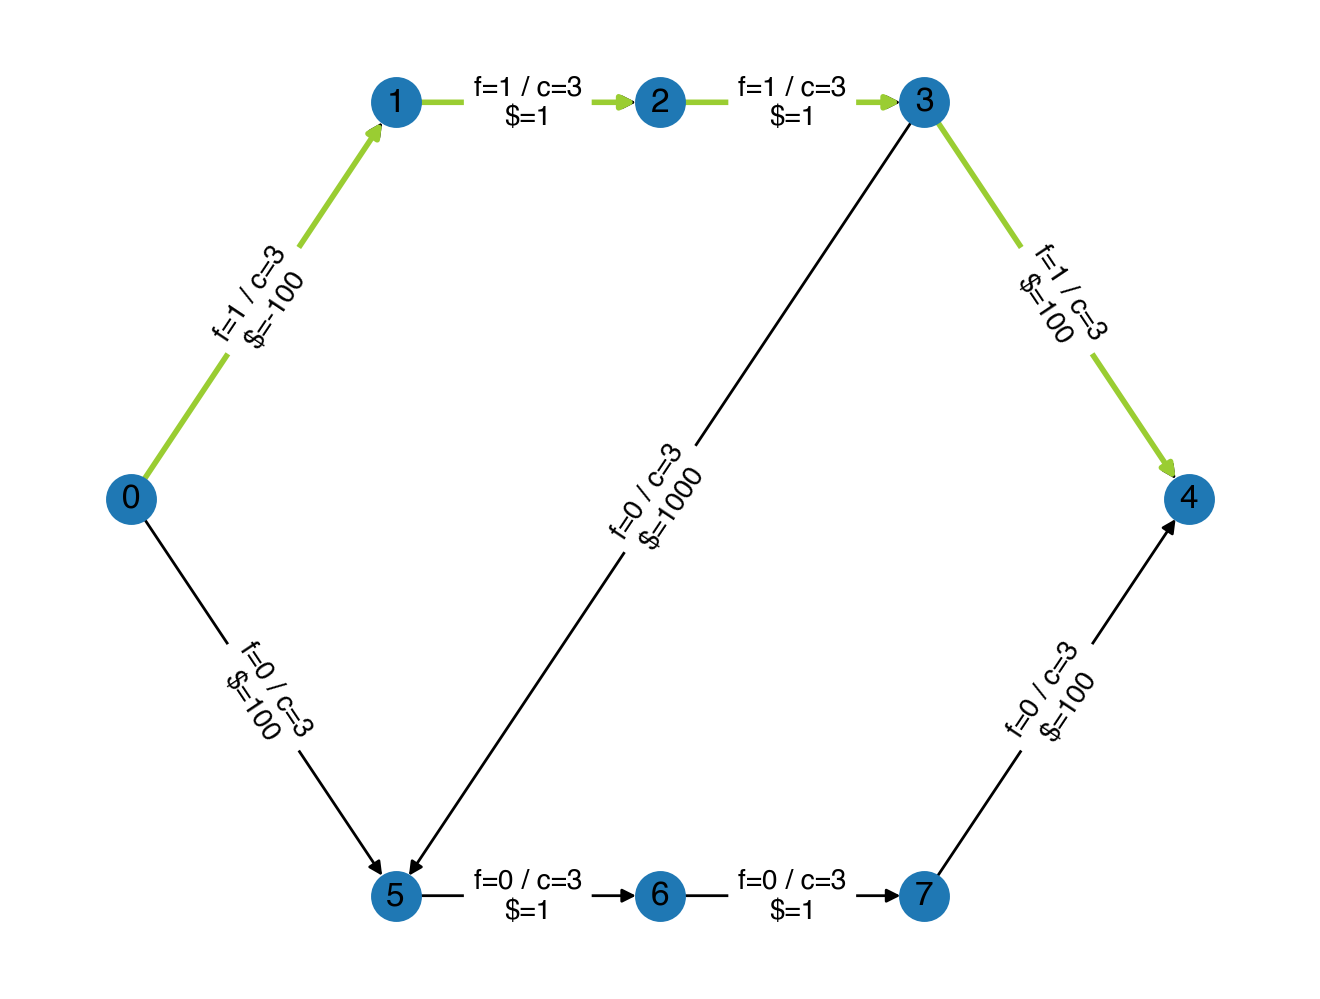

In [897]:
nx.draw(G_mincost, pos=pos, with_labels=True)
edge_labels = {(u, v): f"f={data['flow']} / c={data['capacity']}\n$={data['cost']}" for u, v, data in G_mincost.edges(data=True)}


all_paths = [flow['path'] for flow in flows]
for idx, path in enumerate(all_paths):
    edges = list(zip(path, path[1:]))
    nx.draw_networkx_edges(G_mincost, pos=pos, edgelist=edges, edge_color="yellowgreen", width=2)

nx.draw_networkx_edge_labels(G_mincost, pos=pos, edge_labels=edge_labels)

plt.show()

#### Testing on larger network

In [910]:
# If you encounter "NetworkXUnfeasible" error below, it means that there is feasible path that we can augment the flow. You have to repeat this random selection process until we are selecting a node pair that has an augmentable path.
source_random, target_random = select_nodes_randomly_from_lscc(G3)
print("Randomly selected source and targets:")
print(f'Source: {source_random}')
print(f'Target: {target_random}')

Randomly selected source and targets:
Source: 13
Target: 30


In [911]:
# Set supply to source and target nodes
nx.set_node_attributes(G3, 0, 'supply')
G3.nodes(data=True)[source_random]['supply'] = 10
G3.nodes(data=True)[target_random]['supply'] = -10
G3 = convert_supply_to_demand(G3)

In [912]:
# Set random cost
for edge in G3.edges():
    G3[edge[0]][edge[1]]['cost'] = np.random.randint(0, 10)

In [923]:
_, flows_random, min_cost_value_random  = successive_shortest_path_algorithm(G3)

13 30
Checking if flow can be added along path:
[13, 30]: True
Augmenting flow by 10
Cost: 90


In [924]:
min_cost_value_random_nx, min_cost_flow_dict_random_nx = nx.network_simplex(G3, weight="cost")

In [925]:
print("Minimum cost from scratch implementation:")
print(min_cost_value_random)

print("Minimum cost from networkx:")
print(min_cost_value_random_nx)

print("Do they match?")
print(min_cost_value_random == min_cost_value_random_nx)

Minimum cost from scratch implementation:
90
Minimum cost from networkx:
90
Do they match?
True


In [926]:
min_cost_flow_paths_random = [flow['path'] for flow in flows_random]
min_cost_flow_paths_random_nx = generate_paths_from_flow_dict(min_cost_flow_dict_random_nx, source_random, target_random)

print("Paths from scratch implementation:")
print(min_cost_flow_paths_random)

print("Paths from networkx:")
print(min_cost_flow_paths_random_nx)

print("Do they match?")
print(min_cost_flow_paths_random == min_cost_flow_paths_random_nx)

Paths from scratch implementation:
[[13, 30]]
Paths from networkx:
[[13, 30]]
Do they match?
True


### Discussion

Successive shortest path algorithm is one of the powerful algorithms to solve the minimum cost flow problem, which could easily be understood in extension of the augmenting path algorithm. There are some elements in common, including the concept of residual networks and to augment a flow along a path.

The strength of this algorithm is that it takes the **cost** into account for each edges, which is a frequently observed restriction in the real world settings. Unlike imaginary graphs in the mathematical world (where we can even handle "infinite" capacity), the problem has to be solved within a limited resource space, meeting the restrictions of time or the budget. Let's see how this algorithm can be applied in actual datasets in the later part of this chapter.

***
<h2 id="cost-efficiency">5. Cost-Efficiency Optimization Problem</h2>
Here, we will study a model that balances network efficiency and cost.




### Outline of this section
- Understand the problem
- Understand the concept/algorithm
- Implement the algorithm in scratch
- Apply it on sample network data, and confirm the property presented in the paper


### Trade-offs in networks

In the previous sections, we've explored two approaches to optimizing paths in networks. The first approach was to select paths that maximize the flow, and the second aimed to minimize the cost. However, these two approaches have limitations when addressing real-world problems. For instance, one example where neither approach fits into is the **optimization of airline networks**. Since it costs a lot for the airline companies to operate aircrafts, they are always making efforts to **minimize the operational cost while offering routes with smaller number of layovers** that can satisfy its customers. To solve this problem, we need a different approach!

Let's try examining how infeasible it is to operate direct flights to meet all possible needs by the customers.  Imagine the holiday season is approaching: one traveler might want to fly from Boston (BOS) to London (LHR) to visit family, while another might want to fly from Toronto (YYZ) to Madagascar (TNR) to enjoy the wildlife and warm climate on the other side of the planet. While there is a direct flight for BOS-LHR, the best option for YYZ-TNR is a series of connecting flights with a layover in Paris (CDG). Although Madagascar is a great winter destination, the demand for transportation between YYZ and TNR is likely to be far smaller than that for BOS-LHR, making it economically irrational for the airlines to operate direct flights on such routes. In fact, with over 47,000 airports worldwide, the possible number of pairs of direct flights would be 1,104,476,500 (47,000 choose 2); yet **there are only 67,000 routes (0.006%) that are actually operated as of 2023** [8].

Returning to our original topic, airline companies optimize the airline networks by operating flights that satisfies both the **network density** (proportional to number of routes they operate) and the **shortest path length between node pairs** (proportional to number of layovers for all possible departure-destination airport pairs). This is the kind of problem that we will study in this section.



### Ferrer i Cancho and Solé model

#### Definitions
**Ferrer i Cancho and Solé model** is one of the simplest models that addresses the problem that we are interested in here, which is to **balance between the cost and the distance** [10]. The algorithm aims to minimize the **energy function** $E$ defined as follows:
$$
E(\lambda) = \lambda d + ( 1 - \lambda ) \rho
$$
where $0 \leq \lambda , d, \rho \leq 1$.

Given $\lambda$, the energy $E$ can be calculated for any given graph by computing $d$ and $\rho$ as defined below.

$d$ (also noted as $m$ in Newman's textbook) is the normalized shortest path length (vertex-vertex distance) defined as follows:
$$
d = \frac{D}{D_{\rm{linear}}}
$$

$D_{ij}$ is the shortest path length between node $i$ and $j$,
$D$ is the average shortest path length, and $D_{\rm{linear}}$ is the maximum value of $D$ that can be achieved by a connected network.
$$
D = \frac{1}{\binom{n}{2}} \sum_{i < j} D_{ij}
$$
$$
D_{\rm{linear}} = \frac{n+1}{3}
$$

$\rho$ (also noted as $l$ in Newman's textbook) is the normalized number of links in the network, which is equivalent to the network density.
$$
\rho = \frac{1}{\binom{n}{2}} \sum_{i < j} a_{ij} = \frac{\langle k \rangle}{ n - 1}
$$


$\lambda$ is the parameter that models the fundamental concept of the model, which is to balance the weight between the cost $\rho$ and distance $d$. As can be immediately be infered from the energy equation, lambda determines the energy:
- If $\lambda=1$, the quality function would be $E=m$ meaning that the network would be optimized only by the distance $d$, regardless of density $\rho$.
- Similarly, if $\lambda=0$, energy function would be $E=l$ meaning that the network will be optimized only by minimizing density $\rho$, regardless of distance $d$.

#### Algorithm
The optimization algorithm is as follows [10]:
- At $t=0$, initialize graph with ER graph (following a Poissonian distribution of degrees) with a density of $\rho(0)$. This means $G = \rm{ER}(n, p=\rho(0))$
- At time $t > 0$,
    - Modify the graph by randomly changing the state of edges. For all edge pairs, each edge can either be removed or added with probability $\nu$.
    - Calculate energy for the modified graph
    - If the energy for the modified graph is greater than the previous graph, $E(\lambda, t + 1) < E(\lambda, t)$, accept the new graph. If not, try the modification process again.
- The modification process stops when the modification is not accepted $T$ times in a row

This algorithm is classified as one of the **greedy algorithms** because it aims to obtain **immediate improvements in the loss value** (which is measured using energy function $E$ in this case), by comparing the loss only between the networks before and after the modification. If the modified network has smaller loss, the modification is accepted; otherwise it is rejected and attempts an another try until acception.

### Implementation

Using the equations and algorithms defined above, let's implement the model from scratch.

The final objective once we implement the model is be to reproduce the following two figures from [[10]](
https://link.springer.com/chapter/10.1007/978-3-540-44943-0_7).

<img src="images/ferrer-lambda.png" width="500">
<img src="images/ferrer-lambda-entropy.png" width="500">

#### Helper functions
We'll first implement the following helper functions that calculates:
- rho
- d
- energy
- entropy

In [1115]:
# Helper function to calculate normalized number of links (ρ)
def calculate_rho(G, n=None):
    """
    Calculate normalized number of links rho. This is equivalent to network density.

    rho = ( 1 / (nC2) ) * sum_{i<j} a_{ij}
        = (langle k rangle) / (n-1)
    
    Parameters
    ----------
        G : networkx.Graph
            Input graph.
        n: int, optional
            Number of nodes in the graph (default is None). If None, it will be calculated from the graph.
    
    Returns
    ----------
        rho : float
            Normalized vertex-vertex distance d.
    """

    # Calculate number of node if not provided
    if n is None:
        n = G.number_of_nodes()
    
    num_links = G.number_of_edges()
    max_links = n * (n - 1) / 2

    rho = num_links / max_links

    return rho

In [1116]:
def calculate_d(G, n=None):
    """
    Calculate the normalized vertex-vertex distance (d) for a graph. This is calculated from following formula:
    d = D / D_linear
    where
    - D is the average minimum distance between nodes
        D = (1 / nC2 ) * sum_{i<j} D_{ij}
    - D_{ij} is the shortest path length between nodes i and j
    - D_linear is the maximum value of D that can be achieved by a connected network
        D_linear = (n + 1) / 3

    Parameters
    ----------
        G : networkx.Graph
            Input graph.
        n: int, optional
            Number of nodes in the graph (default is None). If None, it will be calculated from the graph.
    
    Returns
    ----------
        d : float
            Normalized vertex-vertex distance d.
    """

    from itertools import combinations

    if n is None:
        n = G.number_of_nodes()

    # Calculate D (average minimum distance between nodes)
    if nx.is_connected(G):

        # D_ij for all node pairs
        distances = dict(nx.all_pairs_shortest_path_length(G))

        total_distance = 0
        num_pairs = 0 # This is equal to nC2 (all possible pairs)

        for u, v in combinations(G.nodes, 2):
            total_distance += distances[u][v]
            num_pairs += 1

        D = total_distance / num_pairs
    else:
        # If the graph is disconnected, D is infinite
        return float('inf')

    # Calculate D_linear (max possible D)
    D_linear = (n + 1) / 3

    # Calculate normalized distance d
    d = D / D_linear

    return d

In [1117]:
# These two calculates the same thing. The difference is only the input parameters (graph or d and rho).

def calculate_energy_from_graph(G, lam):
    """
    Calculate the energy from a graph, given lambda.

    Parameters
    ----------
        G : networkx.Graph
            The input graph for which the energy is to be calculated.
        lam : float
            Lambda parameter controlling the tradeoff between distance and density.


    Returns
    -------
        energy: float
            The calculated energy value based on the input graph and parameters.
    """

    d = calculate_d(G)
    rho = calculate_rho(G)
    energy = ((lam * d) + ((1 - lam) * rho))
    return energy

def calculate_energy_from_d(lam, d, rho):
    """
    Calculate the energy from d and rho, given lambda.

    Parameters
    ----------
        lam : float
            Lambda parameter controlling the tradeoff between distance and density.
        d : float
            The normalized vertex-vertex distance of the graph.
        rho : float
            A parameter that represents an additional factor in the energy calculation.

    Returns
    -------
        energy: float
            The calculated energy value based on the input graph and parameters.
    """
    energy = ((lam * d) + ((1 - lam) * rho))
    return energy

In addition to $\rho$, $d$, and $E$, we define another metric called "degree entropy" which we denote using $H$. This metric quantifies the diversity or homogeneity of the degree distribution by the equation defined below.

For example, if the degree distribution is highly skewed (as in star networks), the entropy would be small. Conversely, if the degree distribution is uniform, we would obtain a larger entropy value.

$$
H({p_k}) = - \sum_{k=1}^{n-1} p_k \log p_k
$$

In [930]:
def calculate_degree_entropy(G):
    """
    Calculate the degree entropy of a graph.
    
    Parameters
    ----------
        G : networkx.Graph
            Input graph to calculate degree entropy
    
    Returns
    -------
        entropy : float
            Degree entropy H({p_k}).
    """
    
    # Get degree distribution
    degrees = list(dict(G.degree()).values())

    # Calculate the frequency of each degree
    from collections import Counter
    degree_counts = Counter(degrees)
    
    # Calculate probability for degree distribution
    total_nodes = G.number_of_nodes()
    p_k = np.array(list(degree_counts.values())) / total_nodes
    
    # Extract p_k > 0 since log(0) is undefined
    nonzero_p_k = p_k[p_k > 0]

    # Calculate entropy
    entropy = -np.sum( nonzero_p_k * np.log(nonzero_p_k) )

    return entropy

#### Optimization function

In [931]:
# Your turn!

# Task:
# Implement the Ferrer i Cancho and Solé optimization algorithm to optimize a graph based on the energy function. Refer to the docstring for input and output of the function.

def ferrer_cancho_sole_optimization(lam, nu, max_rejections, n=None, p=None, G=None):
    """
    Optimize a graph using the Ferrer i Cancho and Solé model.
    
    Parameters
    -------
        lam : float
            Lambda parameter controlling the tradeoff between distance and density.
        nu : float
            Probability of flipping an edge during each iteration.
        max_rejections : int
            Maximum number of consecutive rejections before stopping.
        n : int
            Number of nodes in the graph. Used to generate initial ER graph (Required if G is not provided).
        p : float
            Initial connection probability for the random graph. Used to generate initial ER graph (Required if G is not provided).
        G : networkx.Graph, optional
            Initial graph to optimize. You can either pass pre-generated G or and n and p pairs to generate a random graph inside this function.

    Returns
    -------
        optimized_G : networkx.Graph
            Optimized graph.
        interations : int
            Number of iterations until reaching the maximum number of rejections.
    """

    # Step 1: Generate the initial ER graph
    # Initial graph follows a Poisson degree distribution
    G = "foo"
    # ____YOUR_CODE_HERE____

    # Step 2: Calculate energy for graph (use the helper functions above!)
    # ____YOUR_CODE_HERE____

    # Step 3: Initialize counts
    consecutive_rejections = 0
    iterations = 0

    # Repeat until consecutive rejections reach the maximum
    # while SOME_CONDITION_HERE:

        # Create "modified_G" which is the copy of the graph that we'll modify
        # ____YOUR_CODE_HERE____

        # Add or remove edges with probability "nu" in modified_G
        # Hint:
        # - Use nx.non_edges and G.edges 
        # - Generate some random number and compare it with ____ to decide whether to add or remove the edge
        # ____YOUR_CODE_HERE____

        # Calculate new energy and store it in "new_energy"
        # ____YOUR_CODE_HERE____

        # Comapre new_energy and energy
        # Accept the new graph if energy is lower than the current energy

        # if SOME_CONDITION_HERE:
        #     ___YOUR_CODE_HERE____
        # else:
        #     # If rejected, increase the consecutive_rejections
        #     ___YOUR_CODE_HERE____

        # iterations += 1
    
    optimized_G = G

    return optimized_G, iterations

In [932]:
def ferrer_cancho_sole_optimization(lam, nu, max_rejections, n=None, p=None, G=None):
    """
    Optimize a graph using the Ferrer i Cancho and Solé model.
    
    Parameters
    -------
        lam : float
            Lambda parameter controlling the tradeoff between distance and density.
        nu : float
            Probability of flipping an edge during each iteration.
        max_rejections : int
            Maximum number of consecutive rejections before stopping.
        n : int
            Number of nodes in the graph. Used to generate initial ER graph (Required if G is not provided).
        p : float
            Initial connection probability for the random graph. Used to generate initial ER graph (Required if G is not provided).
        G : networkx.Graph, optional
            Initial graph to optimize. You can either pass pre-generated G or and n and p pairs to generate a random graph inside this function.

    Returns
    -------
        optimized_G : networkx.Graph
            Optimized graph.
        interations : int
            Number of iterations until reaching the maximum number of rejections.
    """

    # Step 1:Generate the initial ER graph
    # Initial graph follows a Poisson degree distribution
    if G is None:
        G = nx.erdos_renyi_graph(n, p)

    # Step 2: Calculate energy for graph(use the helper functions above!)
    rho = calculate_rho(G)
    d = calculate_d(G)
    energy = calculate_energy_from_d(lam=lam, d=d, rho=new_rho)

    # Step 3: Initialize counts
    consecutive_rejections = 0
    iterations = 0

    # Repeat until consecutive rejections reach the maximum
    while consecutive_rejections < max_rejections:

        # Create a modified copy of the graph
        modified_G = G.copy()

        # Add or remove edges with probability "nu" in modified_G
        # Hint:
        # - Use nx.non_edges and G.edges 
        # - Generate some random number and compare it with ____ to decide whether to add or remove the edge
        for u, v in nx.non_edges(G):
            if np.random.rand() < nu:
                modified_G.add_edge(u, v)
        for u, v in list(G.edges):
            if np.random.rand() < nu:
                modified_G.remove_edge(u, v)

        # Calculate new energy and store it in "new_energy"
        new_rho = calculate_rho(modified_G, n)
        new_d = calculate_d(modified_G, n)
        new_energy = calculate_energy_from_d(lam=lam, d=new_d, rho=new_rho)

        # Accept the new graph if energy is lower than the current energy
        if new_energy < energy:
            G = modified_G
            energy = new_energy

            # Reset the consecutive_rejections if accepted
            consecutive_rejections = 0
        else:
            # If rejected, increase the consecutive_rejections
            consecutive_rejections += 1

        iterations += 1
    
    optimized_G = G

    return optimized_G, iterations

### Running optimization

#### Preparation
We'll use following parameters in this notebook to reproduce the results from the paper. The system size is set to 50 nodes, where as the original paper used 100 nodes. (This is to reduce the computation time.)

In [933]:
import math
n = 50  # Number of nodes
p = 0.2 # Initial connection probability
# lam = 0.1  # Lambda parameter
nu = 2/math.comb(n, 2) # Edge flip probability
max_rejections = min(500, math.comb(n, 2)) # Stopping criterion

print(f'n={n}, p={p}, nu={nu}, max_rejections={max_rejections}')

n=50, p=0.2, nu=0.0016326530612244899, max_rejections=500


In [934]:
# Generate the initial state of graph
G_FCS_original = nx.erdos_renyi_graph(n, p)
G_FCS_original.number_of_nodes()

50

In [935]:
lambdas = [i / 100 for i in range(0, 100+1, 5)] # 0 to 1 in 0.05 increments

# We'll repeat the optimization for 50 times for each lambda value, and take average for metrics
num_iterations = 50

# Lambda iteration list for for-loop
lam_iterations = np.array(
        [[lam]*num_iterations for lam in lambdas]
    ).reshape(-1).tolist()

In [936]:
len(lam_iterations)

1050

#### Running inside Jupyter
The following cell runs optimization for the initial graph inside Jupyter (in parallel).

In [937]:
# import concurrent.futures

# def optimize_graph(lam):
#     optimized_G, it = ferrer_cancho_sole_optimization(
#         lam=lam,
#         nu=nu,
#         max_rejections=max_rejections,
#         G=G_FCS_original
#     )
#     return lam, optimized_G, it

# with concurrent.futures.ProcessPoolExecutor(max_workers=3) as executor:
#     results = list(tqdm(executor.map(optimize_graph, lam_iterations), total=len(lam_iterations)))

# optimized_graphs = defaultdict(list)
# for lam, optimized_G, it in results:
#     optimized_graphs[lam].append(optimized_G)

#### Running in parallel in Slurm
If you have access to Discovery (high performance computing cluster), you could do the same computation in parallel using large number of cores (e.g., 100 cores!).



First, make initial graph and save it as `out/graph_initial_{n}.pkl`
```sh
python3 init_graph.py
```

Next, run the slurm job. This script repeats the optimization process for num_iterations*len(lambdas) times. Optimized graph is saved as `out/n_50/optimized_G/{task_id}.pkl`
```sh
sbatch optimize.sh
```

In [938]:
# Run this after the optimization is done in Slurm

# We'll load the optimized graphs from the out directory, and store it in a dictionary

optimized_graphs = defaultdict(list)
graph_count = 0

for lam in lambdas:

    lam_str = f"{lam:.2f}"
    
    lam_dir = f"out/n_{n}/optimized_G/{lam_str}"
    if not os.path.exists(lam_dir):
        print(f"Directory {lam_dir} does not exist, skipping...")
        continue
    
    # Collect all .pkl files in the lambda directory
    pkl_files = [f for f in os.listdir(lam_dir) if f.endswith(".pkl")]

    for pkl_file in pkl_files:
        pkl_path = os.path.join(lam_dir, pkl_file)
        
        # Load the graph
        with open(pkl_path, "rb") as file:
            optimized_G = pickle.load(file)
        
        # Store the graph in the dictionary
        optimized_graphs[lam].append(optimized_G)

        graph_count  += 1

# Verify the loaded data
for lam, graphs in optimized_graphs.items():
    print(f"Lambda: {lam}, Number of Graphs: {len(graphs)}")

Lambda: 0.0, Number of Graphs: 50
Lambda: 0.05, Number of Graphs: 50
Lambda: 0.1, Number of Graphs: 50
Lambda: 0.15, Number of Graphs: 50
Lambda: 0.2, Number of Graphs: 50
Lambda: 0.25, Number of Graphs: 50
Lambda: 0.3, Number of Graphs: 50
Lambda: 0.35, Number of Graphs: 50
Lambda: 0.4, Number of Graphs: 50
Lambda: 0.45, Number of Graphs: 50
Lambda: 0.5, Number of Graphs: 50
Lambda: 0.55, Number of Graphs: 50
Lambda: 0.6, Number of Graphs: 50
Lambda: 0.65, Number of Graphs: 50
Lambda: 0.7, Number of Graphs: 50
Lambda: 0.75, Number of Graphs: 50
Lambda: 0.8, Number of Graphs: 50
Lambda: 0.85, Number of Graphs: 50
Lambda: 0.9, Number of Graphs: 50
Lambda: 0.95, Number of Graphs: 50
Lambda: 1.0, Number of Graphs: 50


In [939]:
graph_count == len(lam_iterations)

True

### Optimization results

Once we obtain the optimized graphs in either ways, we can calculate the metrics for each iterations or the mean values of each metrics for each lambda.

In [940]:
# Calculate metrics for each optimized graph
energy_s = defaultdict(list)
d_s = defaultdict(list)
rho_s = defaultdict(list)
entropy_s = defaultdict(list)
clustering_coef_s = defaultdict(list)

for lam, Gs in tqdm(optimized_graphs.items()):
    for optimized_G in Gs:
        energy = calculate_energy_from_graph(
            G=optimized_G,
            lam=lam
        )
        d = calculate_d(optimized_G)
        rho = calculate_rho(optimized_G)
        entropy = calculate_degree_entropy(optimized_G)
        clustering = nx.average_clustering(optimized_G)

        energy_s[lam].append(energy)
        rho_s[lam].append(rho)
        d_s[lam].append(d)
        entropy_s[lam].append(entropy)
        clustering_coef_s[lam].append(clustering)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:02<00:00,  7.84it/s]


In [941]:
# Calculate mean values for each lambda
mean_energy_s = {}
mean_d_s = {}
mean_rho_s = {}
mean_entropy_s = {}
mean_clustering_coef_s = {}
for lam, optimized_G in tqdm(optimized_graphs.items()):
    mean_energy_s[lam] = np.mean(energy_s[lam])
    mean_d_s[lam] = np.mean(d_s[lam])
    mean_rho_s[lam] = np.mean(rho_s[lam])
    mean_entropy_s[lam] = np.mean(entropy_s[lam])
    mean_clustering_coef_s[lam] = np.mean(clustering_coef_s[lam])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:00<00:00, 5995.94it/s]


### Visualization and Plots


#### Property plots
Let's reproduce this figure which presents the major metrics of the network as a function of $\lambda$. You can ignore the dotted lines and arrows. The values would not perfectly match because we are using slightly different parameters (n=100) from the original paper, but the overall trend should look the same.

You first calculate each metrics for each optimized networks, and then average it over iterations in the same $\lambda$ value.


<img src="images/ferrer-lambda.png" width="500">

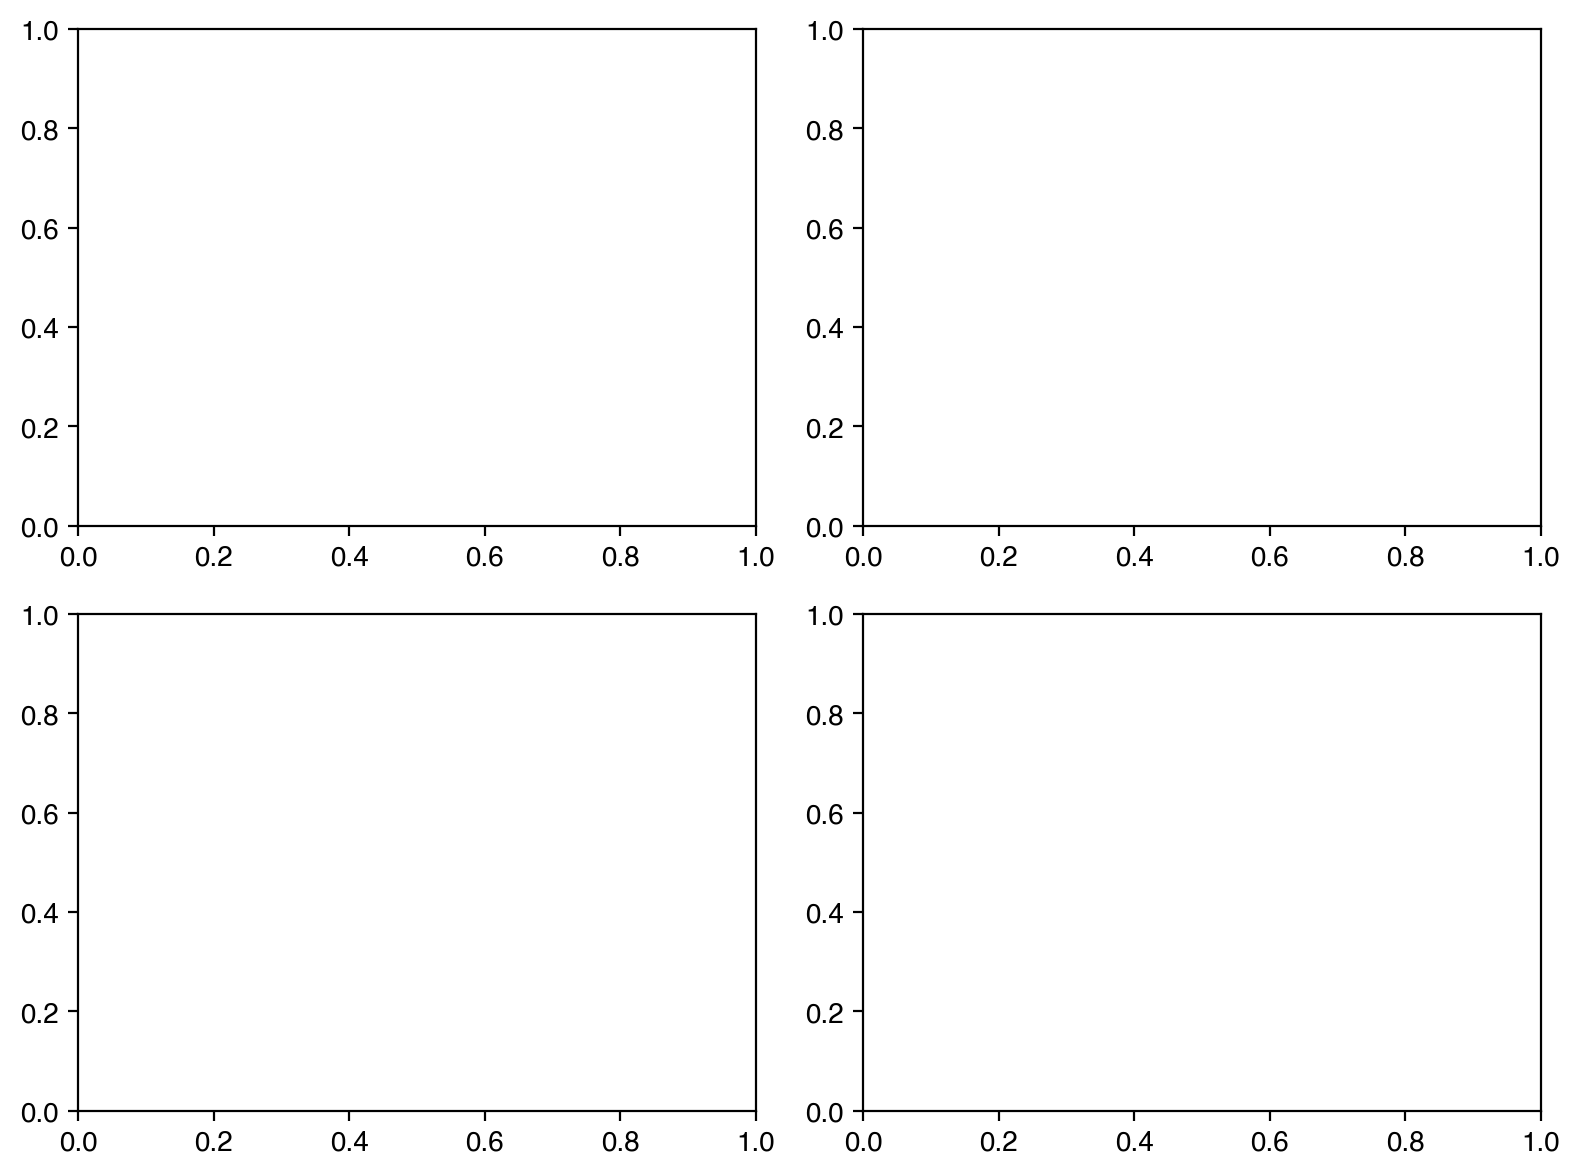

In [942]:
# Your turn!

# Task:
# Make a figure that has subplots of density, energy, clustering coefficient, and distance for each lambda value.

fig_property, axs = plt.subplots(2,2, figsize=(4*2,3*2))

# Plot density, energy, clustering coefficient, and distance

# Values are stored in following dictionaries (key is lambda)
# mean_energy_s, mean_d_s, mean_rho_s, mean_clustering_coef_s

# ____YOUR_CODE_HERE____

fig_property.tight_layout()

plt.show()


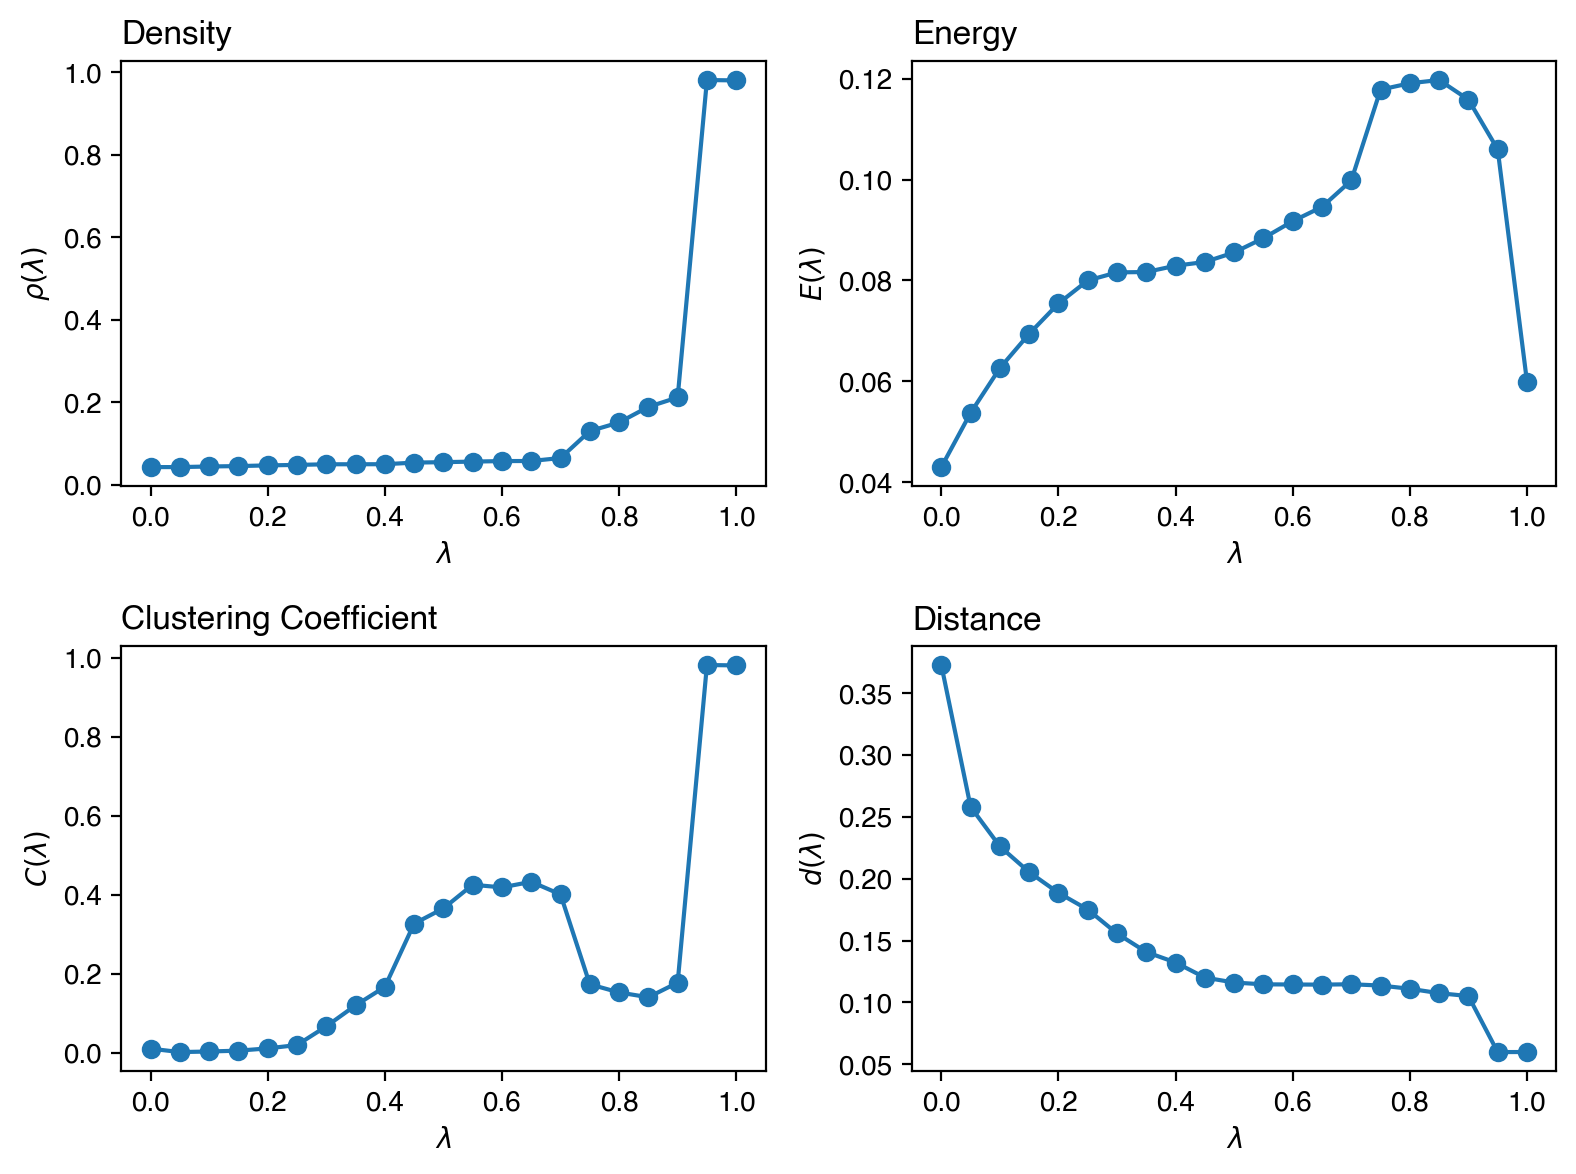

In [ ]:
fig_property, axs = plt.subplots(2,2, figsize=(4*2,3*2))

axs_1d = axs.reshape(-1)

# Plot density, energy, clustering coefficient, and distance

# Values are stored in following dictionaries (key is lambda)
# mean_energy_s, mean_d_s, mean_rho_s, mean_clustering_coef_s

axs_1d[0].plot(mean_rho_s.keys(), mean_rho_s.values(), 'o-')
axs_1d[0].set_title("Density", loc='left')
axs_1d[0].set_ylabel(r"$\rho(\lambda)$")
axs_1d[0].set_xlabel(r"$\lambda$")
# axs_1d[0].set_xlim(0.5, 1)

axs_1d[1].plot(mean_energy_s.keys(), mean_energy_s.values(), 'o-')
axs_1d[1].set_title("Energy", loc='left')
axs_1d[1].set_ylabel(r"$E(\lambda)$")
axs_1d[1].set_xlabel(r"$\lambda$")
# axs_1d[1].set_xlim(0.4, 1)

axs_1d[2].plot(mean_clustering_coef_s.keys(), mean_clustering_coef_s.values(), 'o-')
axs_1d[2].set_title("Clustering Coefficient", loc='left')
axs_1d[2].set_ylabel(r"$C(\lambda)$")
axs_1d[2].set_xlabel(r"$\lambda$")


axs_1d[3].plot(mean_d_s.keys(), mean_d_s.values(), 'o-')
axs_1d[3].set_title("Distance", loc='left')
axs_1d[3].set_ylabel(r"$d(\lambda)$")
axs_1d[3].set_xlabel(r"$\lambda$")



fig_property.tight_layout()

# plt.savefig('fig/ferrer_cancho_sole_properties.pdf', bbox_inches='tight')
# plt.savefig('fig/ferrer_cancho_sole_properties.png', bbox_inches='tight', dpi=300)

plt.show()



<img src="images/ferrer-lambda.png" width="500">

#### Entropy plots
Let's reproduce this figure. You can ignore the graph visualizations for specific lambda values. The values would not perfectly match because we are using slightly different parameters (n=100) from the original paper, but the overall trend should look the same.

<img src="images/ferrer-lambda-entropy.png" width="500">


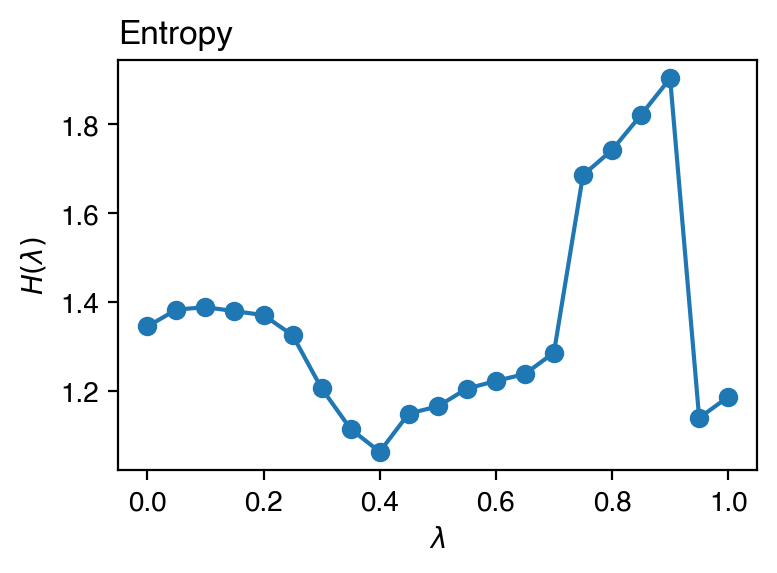

In [ ]:
fig_entropy, ax = plt.subplots(1,1, figsize=(4,3))

ax.plot(mean_entropy_s.keys(), mean_entropy_s.values(), 'o-')
ax.set_title("Entropy", loc='left')
ax.set_ylabel(r"$H(\lambda)$")
ax.set_xlabel(r"$\lambda$")

fig_entropy.tight_layout()

# plt.savefig('fig/ferrer_cancho_sole_entropy.pdf', bbox_inches='tight')
# plt.savefig('fig/ferrer_cancho_sole_entropy.png', bbox_inches='tight', dpi=300)

plt.show()


#### Graph visualization by lambda: different network structues
In the entropy plot, we skipped the "overlayed" visualization of graphs at certain lambda values. Instead, let's plot each graphs in a grid style for different lambda values from 0 to 1 with step of 0.1.

According to the paper, the graph structures after optimization should vary by the value of lambda like this:



In [945]:
# This is the lambda values that we'll plot
plot_lams = [i/10 for i in range(0, 10+1)]

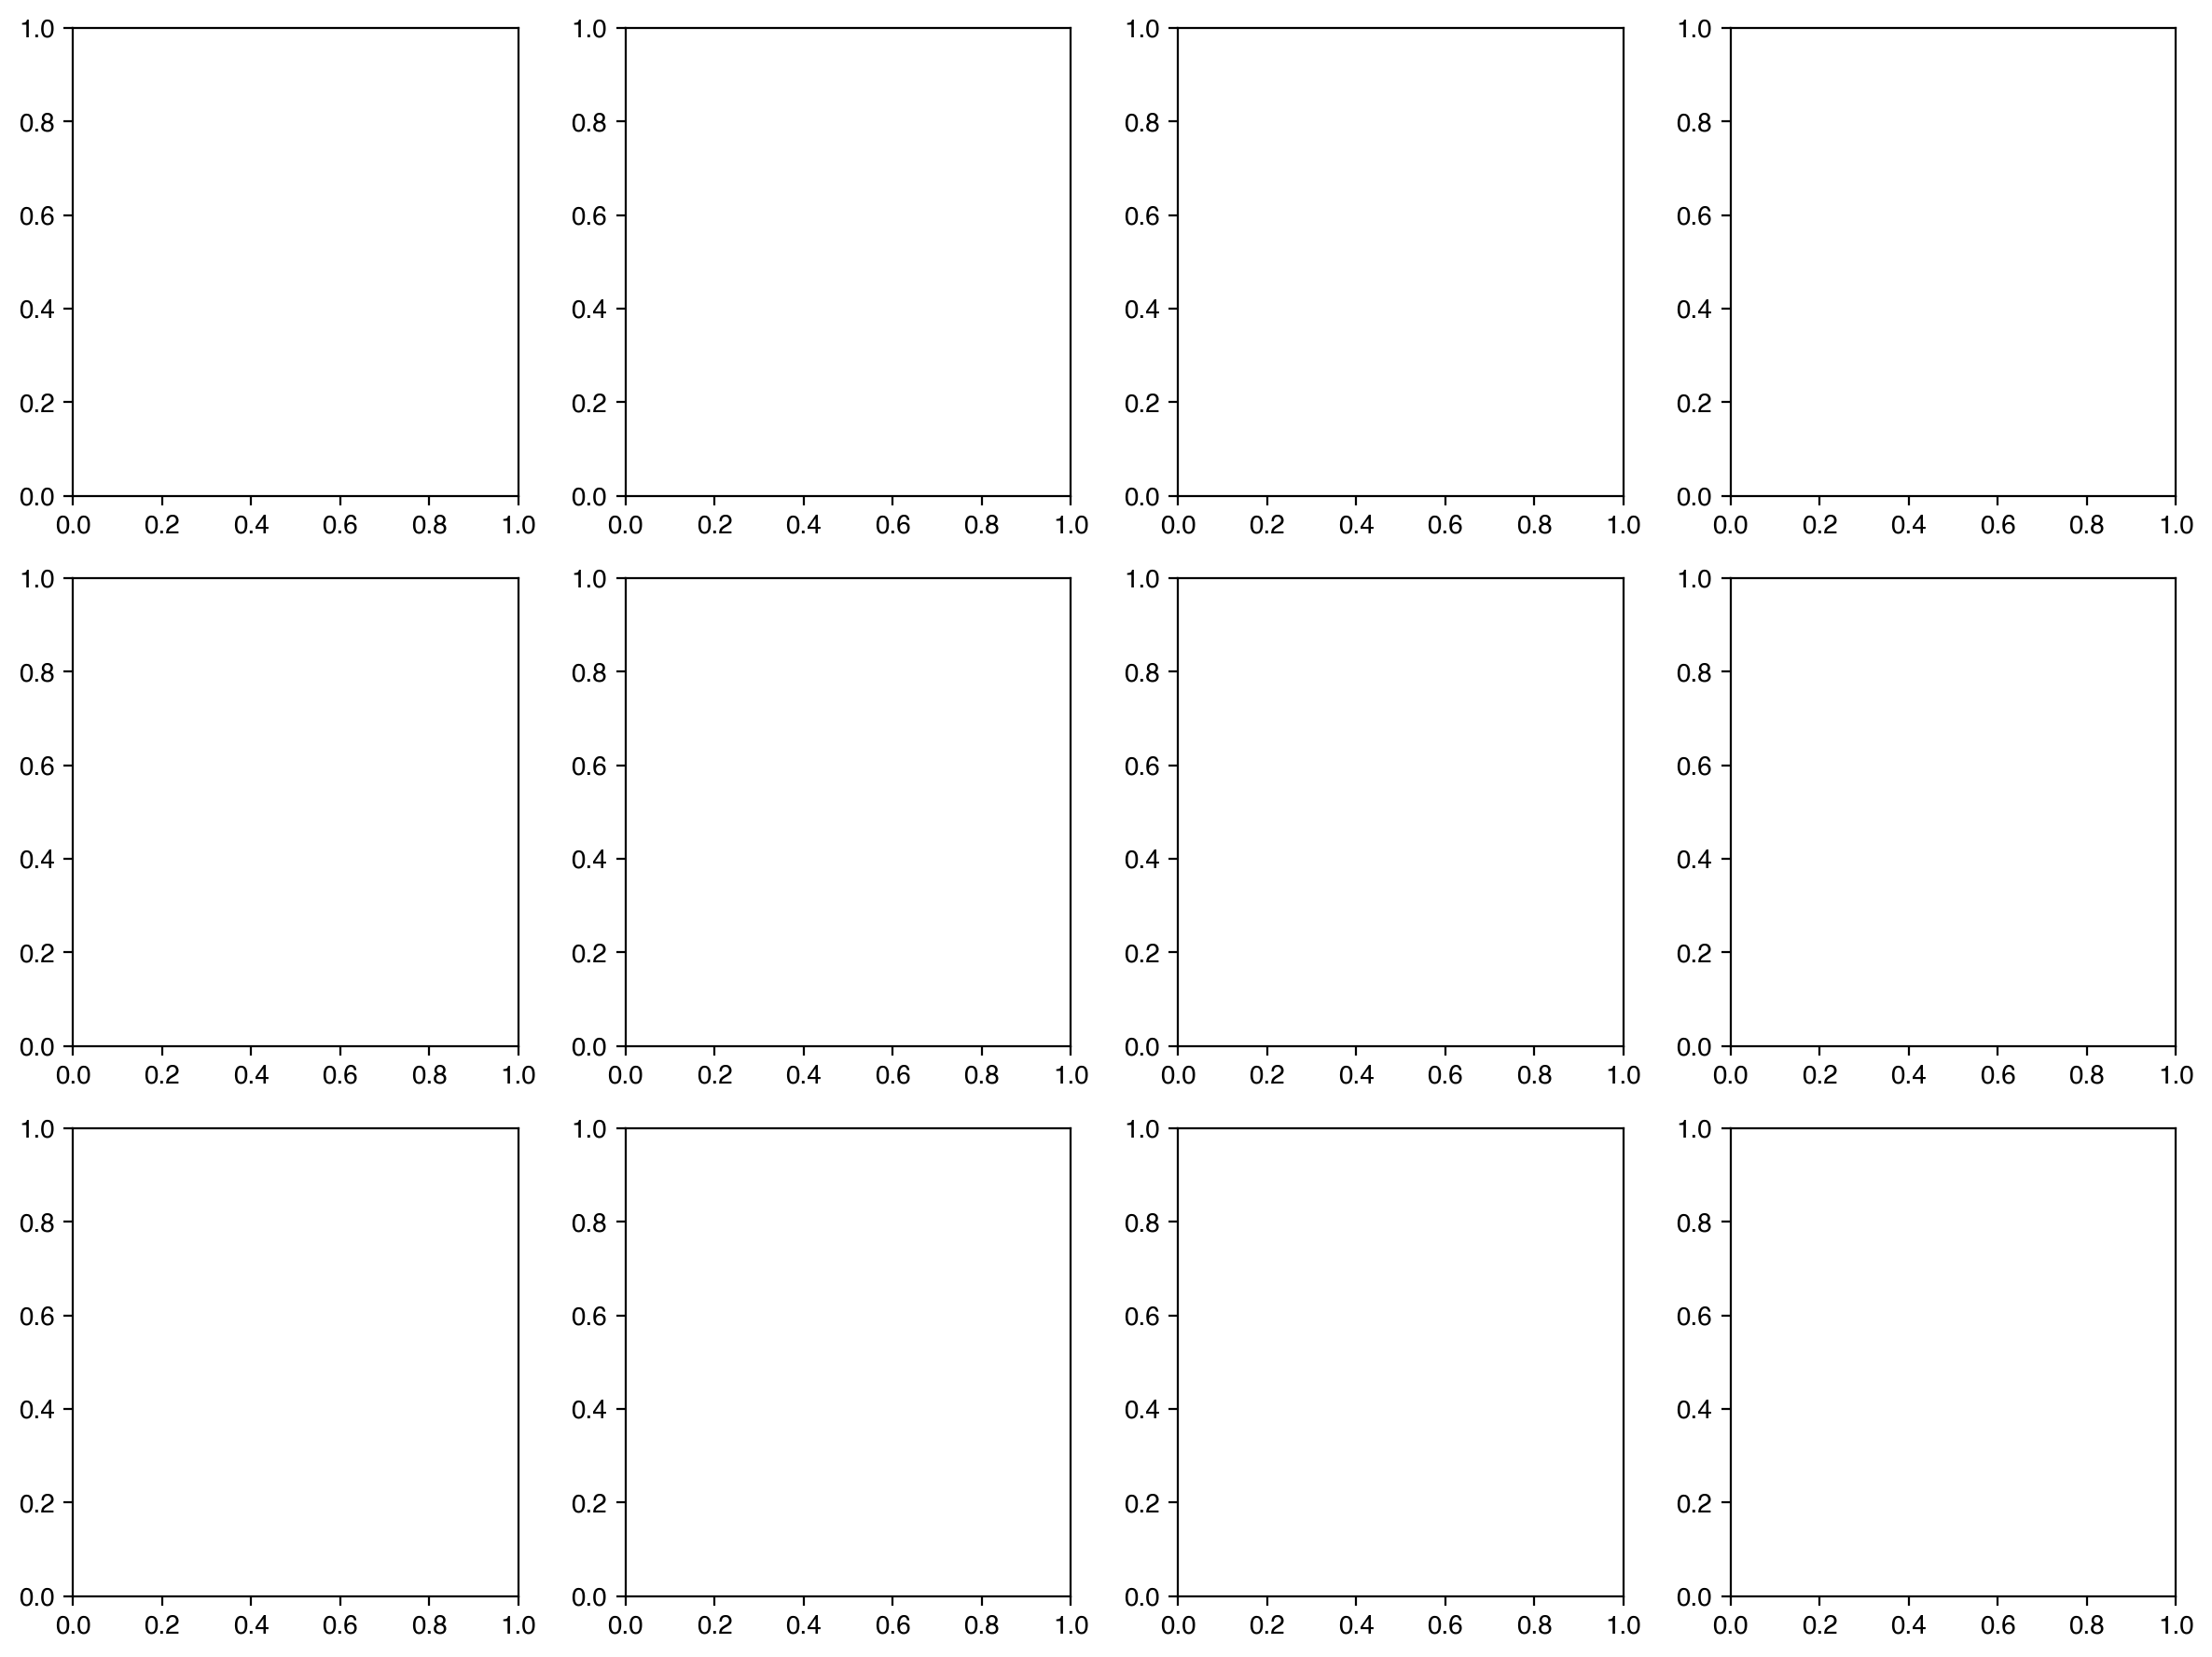

In [946]:
# Your turn!

# Task:
# Make a figure that visualizes the optimized graph for each lambda value in plot_lams.


# Make 3 row * 4 column subplot
fig_network_lambda, axs = plt.subplots(3, 4, figsize=(3*4,3*3))

# For each lambda value in plot_lams, plot the 0-th element in optimized_graphs[lam]
# Set the title of the subplot as the $\lambda={lam}$
# ____YOUR_CODE_HERE____

fig_network_lambda.tight_layout()
plt.show()

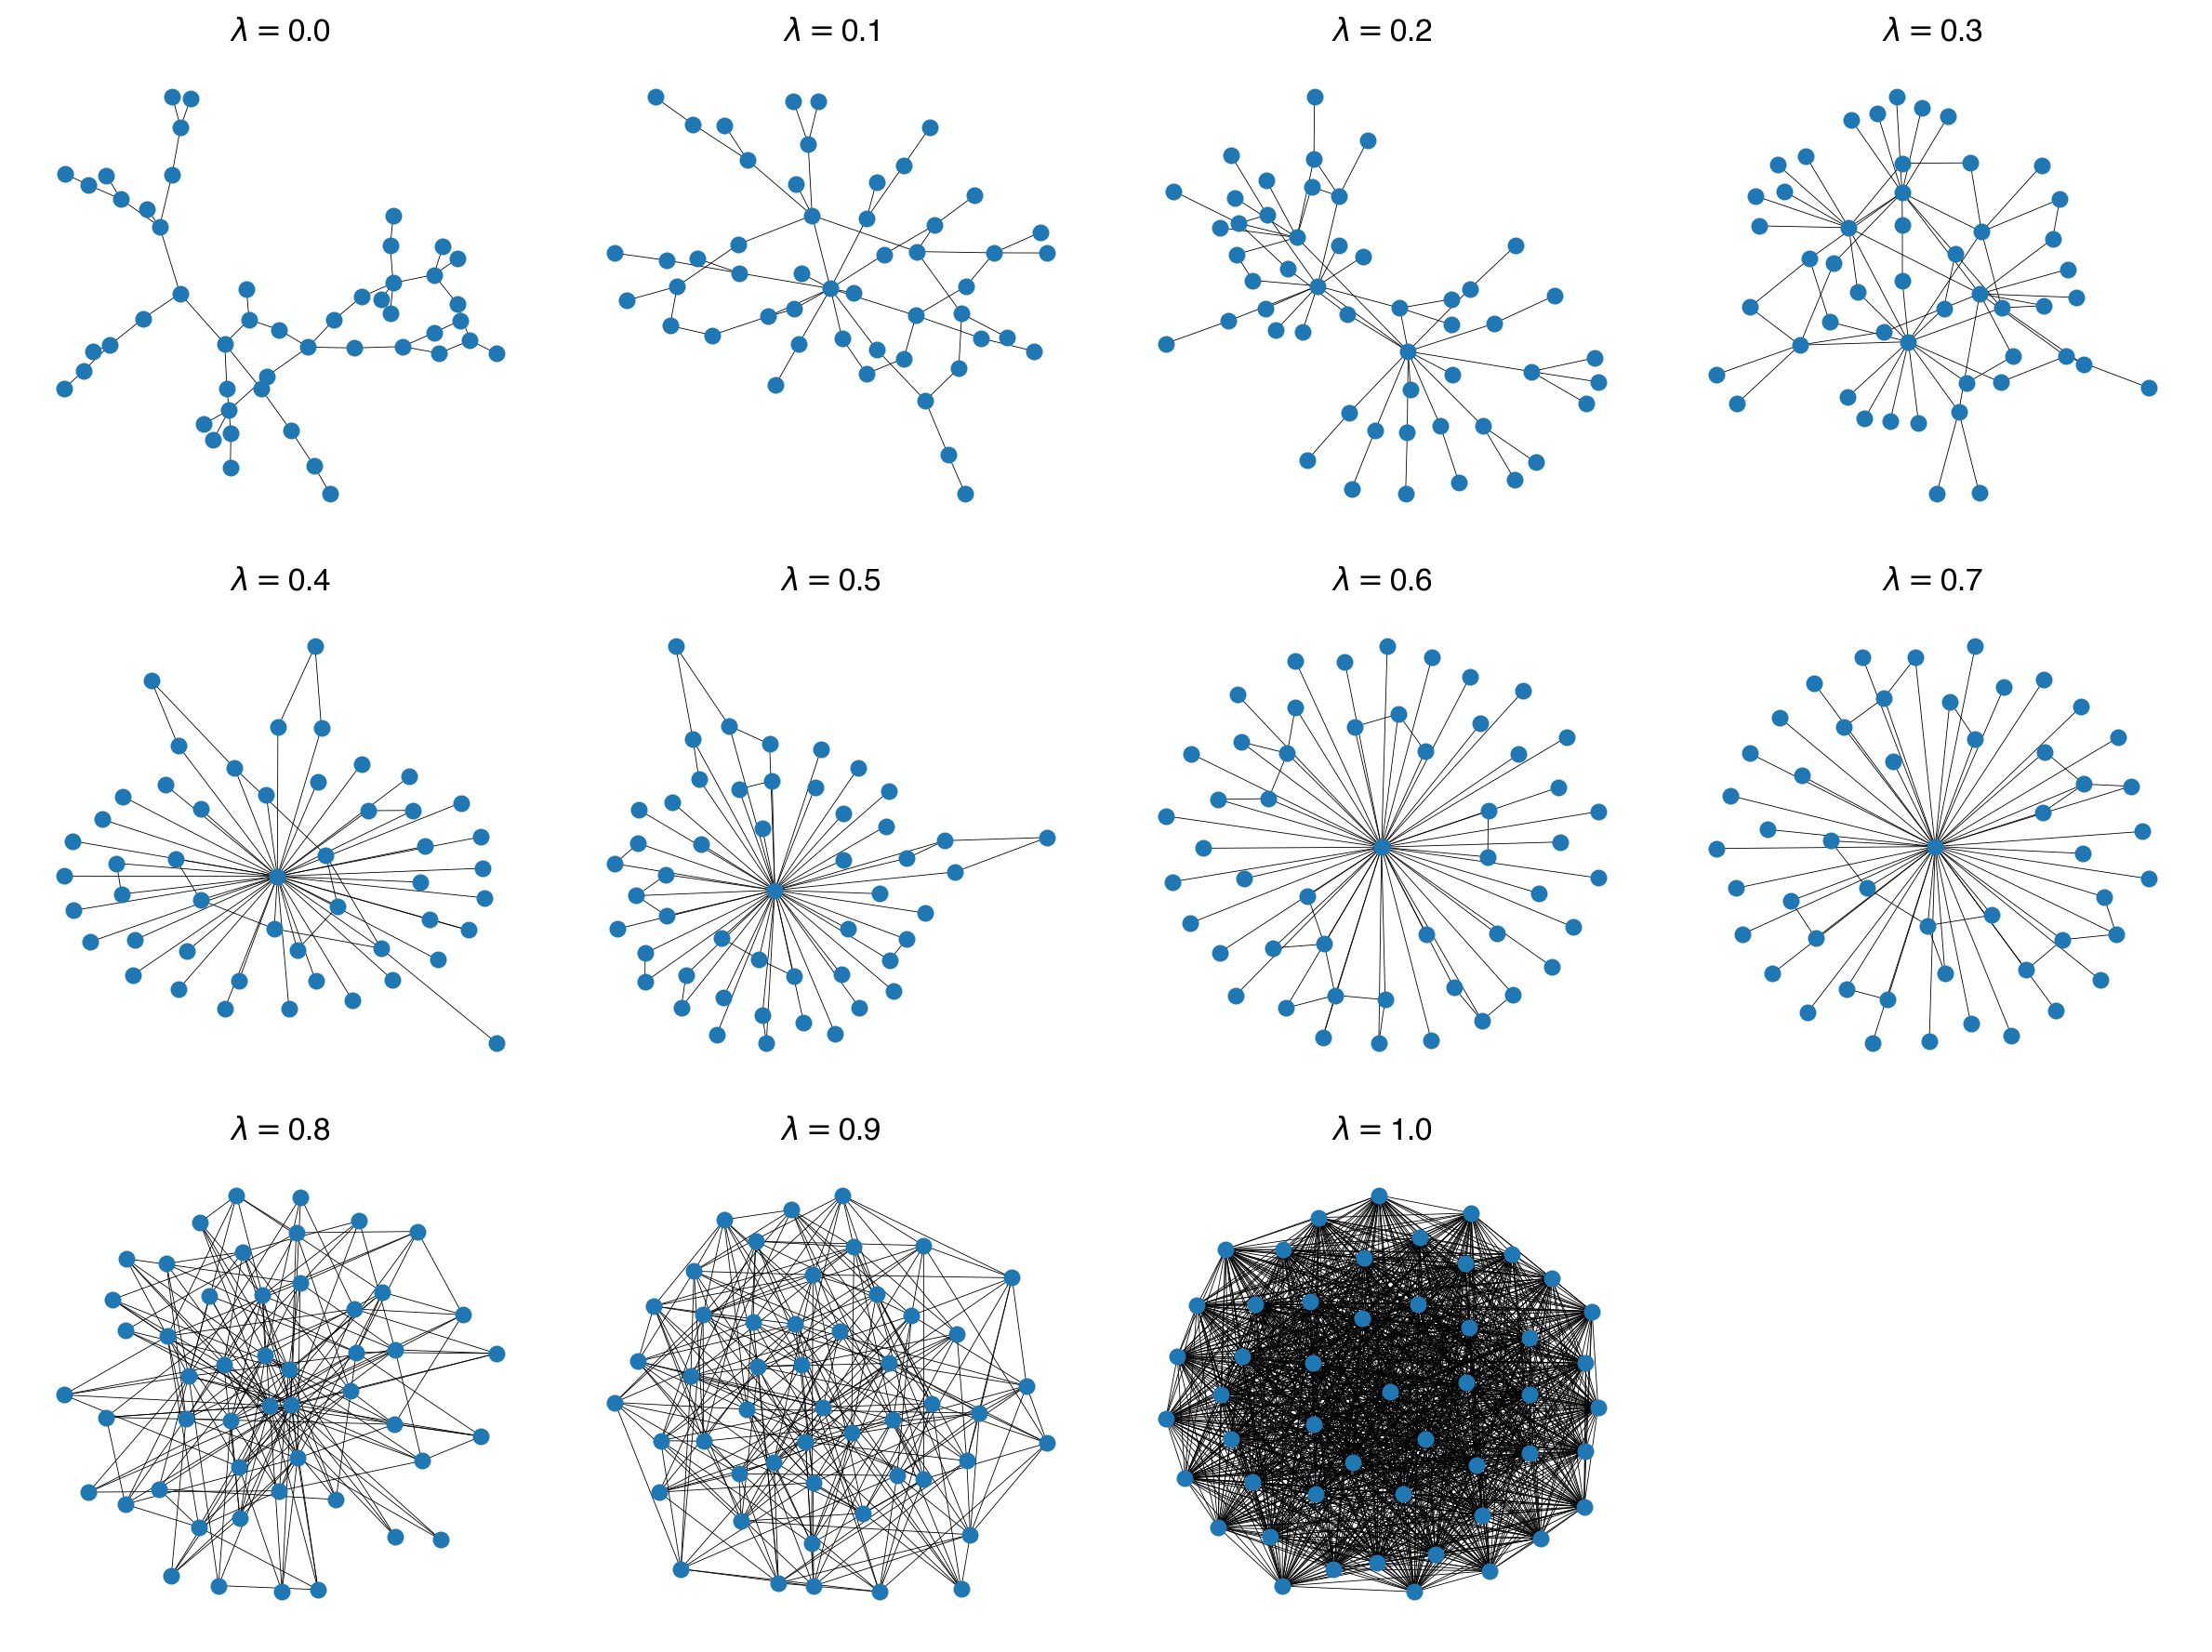

In [1047]:
# Make 3 row * 4 column subplot
fig_network_lambda, axs = plt.subplots(3, 4, figsize=(3*4,3*3))
axs_1d = axs.reshape(-1)

# For each lambda value in plot_lams, plot the 0-th element in optimized_graphs[lam]
# Set the title of the subplot as the $\lambda={lam}$
# ____YOUR_CODE_HERE____

for i, lam in enumerate(plot_lams):

    optimized_G = optimized_graphs[lam][0]
    ax = axs_1d[i]

    nx.draw(optimized_G, with_labels=False, node_size=30, width=0.3, ax=ax)

    ax.set_title(rf"$\lambda=${lam}")
    ax.set_xlabel("")
    ax.set_ylabel("")


axs_1d[11].axis('off')

fig_network_lambda.tight_layout()

# plt.savefig('fig/ferrer_cancho_sole_graph_visualizations.pdf', bbox_inches='tight')
# plt.savefig('fig/ferrer_cancho_sole_graph_visualizations.png', bbox_inches='tight', dpi=300)

plt.show()

### Discussion
As we can see from the plots of average metrics and the graph visualization, for sufficiently large $\lambda$ (excluding lambda close to 0 and 1), **the network with the smallest value of the quality function is the always the star graph**. (Newman)In this case, it's the network with $\lambda$ around 0.4 to 0.6.

Star network is a "hub-and-spoke" system which concentrates all the traffics to a single huge "hub" which accomplishes relatively short distance while keeping the cost (equivalent to the cost) low. Going back to the airline network example that we've mentioned earlier, such star-structured network makes sense for the airline companies because it is indeed **balancing the operation cost (equivalent to density $\rho$) as well as the travel time (equivalent to $d$)**.

However, it should be noted that the algorithm does not guarantee the optimized network to have the **global minimum** of $E$ due to its design. Rather, since the algorithm only compares the value of $E$ **before and after the change** (and ends after reaching certain number of consequtive rejections), the solution obtained is just a **local minima**. There could still be some possibilities of networks with different edge pairs that has smaller values of $E$.

***
<h2 id="casestudy-airport">6. Case Study: Airport Network</h2>

Let's try answering the following questions by applying the algorithms that we've studied to the airline network in the United States. We'll set that the departure and destination airport are Boston Logan International Airport (BOS) and Seattle-Tacoma International Airport (SEA).
1. Which flow minimizes the cost (in terms of the eucledean distance) between BOS and SEA?
2. What is the maximum number of people that can travel from BOS to SEA per day, if we were to use all possible routes without putting any limits in layovers? How many routes are there that satisfies this condition?

Since the information limited in the dataset is limited, we'll set following assumptions:
- The "capacity" of each edge (route) is the average number of passengers per day. Since the values in the "PASSENGER" column is the total number of passengers in a year, we'll divide this by 365.
- The "cost" of each edge (route) is the eucledean distance between the departure and the destination airport.


### Import data
We'll use airport data from the "Network Analysis Made Simple" repository [11]. The files we're using are specifically:
- `data/GlobalAirportDatabase.txt`: Global airport database which includes IATA codes, longitude, latitudes, and etc.
- `data/passengers.csv`: Annual passenger statistics for each airline routes.

#### Passengers data
For each airport pairs, the total number of passengers are recorded. It contains data from 1990 to 2015.

In [948]:
df_passengers = pd.read_csv("data/passengers.csv")
df_passengers

,id,YEAR,ORIGIN,DEST,UNIQUE_CARRIER_NAME,PASSENGERS
0,0,1990,ABE,ACY,{'US Airways Inc.'},73.0
1,1,1990,ABE,ATL,{'Eastern Air Lines Inc.'},73172.0
2,2,1990,ABE,AVL,{'Westair Airlines Inc.'},0.0
3,3,1990,ABE,AVP,"{'Westair Airlines Inc.', 'US Airways Inc.', '...",8397.0
4,4,1990,ABE,BHM,{'Eastern Air Lines Inc.'},59.0
...,...,...,...,...,...,...
457977,457977,2015,ZXU,ACK,{'Tradewind Aviation'},2.0
457978,457978,2015,ZXU,BDL,{'Tradewind Aviation'},2.0
457979,457979,2015,ZXU,HPN,{'Tradewind Aviation'},6.0
457980,457980,2015,ZXU,JZI,{'Tradewind Aviation'},7.0


#### Airport location data

In [949]:
df_airports = pd.read_csv("data/GlobalAirportDatabase.txt", sep=":", header=None)
df_airports.columns = [
    "ICAO_CODE",
    "IATA_CODE",
    "CITY",
    "PROVINCE",
    "COUNTRY",
    "UNKNOWN1",
    "UNKNOWN2",
    "UNKNOWN3",
    "UNKNOWN4",
    "UNKNOWN5",
    "UNKNOWN6",
    "UNKNOWN7",
    "UNKNOWN8",
    "UNKNOWN9",
    "LATITUDE",
    "LONGITUDE"
]
df_airports

,ICAO_CODE,IATA_CODE,CITY,PROVINCE,COUNTRY,UNKNOWN1,UNKNOWN2,UNKNOWN3,UNKNOWN4,UNKNOWN5,UNKNOWN6,UNKNOWN7,UNKNOWN8,UNKNOWN9,LATITUDE,LONGITUDE
0,AYGA,GKA,GOROKA,GOROKA,PAPUA NEW GUINEA,6,4,54,S,145,23,30,E,1610,-6.082,145.392
1,AYLA,LAE,NaN,LAE,PAPUA NEW GUINEA,0,0,0,U,0,0,0,U,0,0.000,0.000
2,AYMD,MAG,MADANG,MADANG,PAPUA NEW GUINEA,5,12,25,S,145,47,19,E,7,-5.207,145.789
3,AYMH,HGU,MOUNT HAGEN,MOUNT HAGEN,PAPUA NEW GUINEA,5,49,34,S,144,17,46,E,1643,-5.826,144.296
4,AYNZ,LAE,NADZAB,NADZAB,PAPUA NEW GUINEA,6,34,11,S,146,43,34,E,73,-6.570,146.726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9288,ZYTK,NaN,NaN,SHENYANG,CHINA,0,0,0,U,0,0,0,U,0,0.000,0.000
9289,ZYTL,DLC,ZHOUSHUIZI,DALIAN,CHINA,38,57,56,N,121,32,18,E,33,38.966,121.538
9290,ZYXC,NaN,NaN,XIANCHENG,CHINA,0,0,0,U,0,0,0,U,0,0.000,0.000
9291,ZYYC,NaN,NaN,YICHUN,CHINA,0,0,0,U,0,0,0,U,0,0.000,0.000


In [950]:
all_airport_list = sorted(list(set(list(df_passengers['ORIGIN']) + list(df_passengers['DEST']))))

In [951]:
# We'll extract the airports in US
df_airports_us = df_airports.query(
    "IATA_CODE in @all_airport_list \
    and COUNTRY == 'USA'"
).drop_duplicates(subset=["IATA_CODE"]).set_index("IATA_CODE")
df_airports_us

,ICAO_CODE,CITY,PROVINCE,COUNTRY,UNKNOWN1,UNKNOWN2,UNKNOWN3,UNKNOWN4,UNKNOWN5,UNKNOWN6,UNKNOWN7,UNKNOWN8,UNKNOWN9,LATITUDE,LONGITUDE
IATA_CODE,,,,,,,,,,,,,,,
ABI,KABI,ABILENE RGNL,ABILENE,USA,32,24,40,N,99,40,54,W,546,32.411,-99.682
ABQ,KABQ,NaN,ALBUQUERQUE,USA,0,0,0,U,0,0,0,U,0,0.000,0.000
ACK,KACK,NANTUCKET MEM,NANTUCKET,USA,41,15,10,N,70,3,36,W,15,41.253,-70.060
ACT,KACT,WACO RGNL,WACO,USA,31,36,40,N,97,13,49,W,158,31.611,-97.230
ACY,KACY,ATLANTIC CITY INTERNATIONAL,ATLANTIC CITY,USA,39,27,27,N,74,34,37,W,23,39.458,-74.577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HNL,PHNL,HONOLULU INTERNATIONAL,HONOLULU,USA,21,18,57,N,157,55,36,W,4,21.316,-157.927
LNY,PHNY,LANAI,LANAI,USA,20,47,8,N,156,57,5,W,399,20.786,-156.951
OGG,PHOG,KAHULUI,KAHULUI,USA,20,53,55,N,156,25,50,W,17,20.899,-156.431


### Construct airline network

In [952]:
# Add airports as nodes
G_airport = nx.MultiDiGraph()
for index, row in df_airports_us.iterrows():
    G_airport.add_node(index, pos=(row['LONGITUDE'], row['LATITUDE']))

In [953]:
pos_airport = nx.get_node_attributes(G_airport, 'pos')

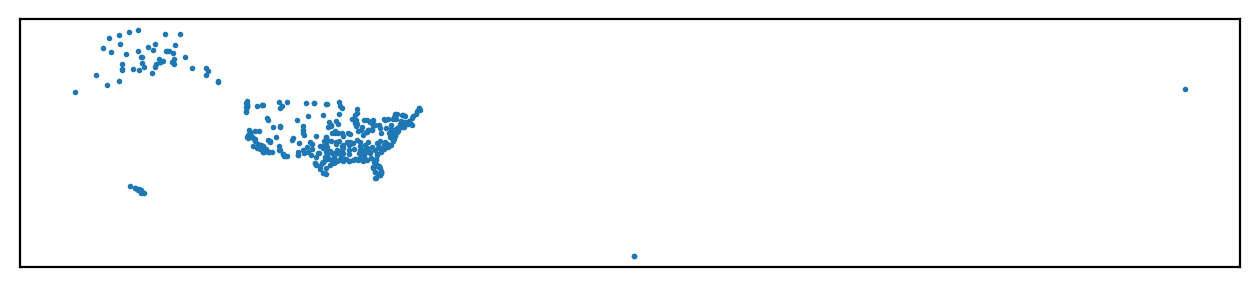

In [954]:
# Let's plot the airports!

fig, ax = plt.subplots(1,1)

nx.draw_networkx_nodes(G_airport, ax=ax, pos=pos_airport, node_size=1)

ax.set_title("", loc='left')
ax.set_xlabel("")
ax.set_ylabel("")

fig.tight_layout()
ax.set_aspect('equal')

plt.show()


In [955]:
us_airport_list = list(df_airports_us.index)

In [956]:
# We'll filter the passengers data to only include the flights between US airports in 2015
df_passengers_us = df_passengers.query(
    "ORIGIN in @us_airport_list and \
    DEST in @us_airport_list and \
    YEAR == 2015"
)
df_passengers_us

,id,YEAR,ORIGIN,DEST,UNIQUE_CARRIER_NAME,PASSENGERS
432729,432729,2015,ABI,AEX,"{'Caribbean Sun Airlines, Inc. d/b/a World Atl...",0.0
432730,432730,2015,ABI,AMA,"{'Allegiant Air', 'Republic Airlines'}",294.0
432731,432731,2015,ABI,AUS,"{'Federal Express Corporation', 'American Airl...",261.0
432733,432733,2015,ABI,COS,{'American Airlines Inc.'},137.0
432734,432734,2015,ABI,DFW,"{'Federal Express Corporation', 'Boutique Air'...",94089.0
...,...,...,...,...,...,...
457949,457949,2015,YNG,TPA,{'Allegiant Air'},162.0
457952,457952,2015,YNG,YIP,{'USA Jet Airlines Inc.'},0.0
457953,457953,2015,YUM,PHX,"{'Mesa Airlines Inc.', 'SkyWest Airlines Inc.'}",75379.0
457954,457954,2015,YUM,PSP,{'SkyWest Airlines Inc.'},0.0


In [957]:
# Add US domestic flights as edges
for index, row in df_passengers_us.iterrows():
    G_airport.add_edge(
        row['ORIGIN'],
        row['DEST'],
        passengers=row['PASSENGERS'] / 365,
        capacity=row['PASSENGERS'] / 365
    )

In [958]:
list(G_airport.nodes(data=True))[:2]

[('ABI', {'pos': (-99.682, 32.411)}), ('ABQ', {'pos': (0.0, 0.0)})]

In [959]:
# Project the map to a coordinate reference system "EPSG:2163" (US National Atlas Equal Area) so that it looks nice when plotted
import pyproj
proj = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:2163", always_xy=True)

In [960]:
# Add a projected position attribute to each node
for node in G_airport.nodes:
    lon, lat = pos_airport[node]
    x, y = proj.transform(lon, lat)
    G_airport.nodes[node]['pos_projected'] = (x, y)

In [961]:
# We have projected coordinates!
list(G_airport.nodes(data=True))[:2]

[('ABI',
  {'pos': (-99.682, 32.411),
   'pos_projected': (30032.74109055987, -1396962.4877308642)}),
 ('ABQ',
  {'pos': (0.0, 0.0),
   'pos_projected': (9473741.421579048, 1181205.063594951)})]

In [962]:
# Calculate eucledean distance, which we'll use as the "cost"
import scipy
for u, v, data in G_airport.edges(data=True):
    x1, y1 = G_airport.nodes[u]['pos']
    x2, y2 = G_airport.nodes[v]['pos']
    distance = scipy.spatial.distance.euclidean((x1, y1), (x2, y2))
    data['distance'] = distance
    data['cost'] = distance

In [963]:
# We have projected coordinates!
list(G_airport.edges(data=True))[:2]

[('ABI',
  'AEX',
  {'passengers': 0.0,
   'capacity': 0.0,
   'distance': 7.215886085575354,
   'cost': 7.215886085575354}),
 ('ABI',
  'AMA',
  {'passengers': 0.8054794520547945,
   'capacity': 0.8054794520547945,
   'distance': 3.4614216732435246,
   'cost': 3.4614216732435246})]

In [964]:
pos_proj_airport = nx.get_node_attributes(G_airport, 'pos_projected')

### Visualization: US Airports and Flights

In [965]:
G_airport.number_of_nodes(), G_airport.number_of_edges()

(421, 10823)

In [1070]:
# def sampled_subgraph(G, p=0.1):
#     num_edges = len(G.edges())
#     sample_size = int(p * num_edges)
#     sampled_edges = random.sample(list(G.edges()), sample_size)

#     sampled_G = nx.MultiDiGraph()
#     sampled_G.add_edges_from((u, v, G[u][v][0]) for u, v in sampled_edges)
    
#     for node in G.nodes(data=True):
#         sampled_G.add_node(node[0], **node[1])

#     return sampled_G

In [ ]:
# Since there are large number of edges, we'll sample edges and create a subgraph to save time.
def subgraph_by_edge_attribute(G, edge_attribute, condition):
    """
    Create a subgraph based on an edge attribute condition.

    Parameters
    ----------
        graph : nx.Graph
            The original graph.
        edge_attribute : str
            The edge attribute to filter on.
        condition : function
            A function that takes an attribute value and returns True or False.

    Returns
    ----------
        subgraph: nx.Graph
            A new subgraph containing only the edges that satisfy the condition.
    """
    # Filter edges based on the condition
    filtered_edges = [
        (u, v, d) for u, v, d in G.edges(data=True) if condition(d.get(edge_attribute))
    ]
    
    # Create a subgraph and add filtered edges
    subgraph = G.__class__()  # Preserve the original graph type
    subgraph.add_edges_from(filtered_edges)
    
    # Optionally, add nodes with attributes from the original graph
    subgraph.add_nodes_from((n, G.nodes[n]) for n in subgraph.nodes)
    
    return subgraph

In [1072]:
# We'll extract top 30% of routes based on the number of passengers
passenger_threshold_percentage = 0.3

passengers = np.sort(list(dict(nx.get_edge_attributes(G_airport, 'passengers')).values()))

for u, v, data in G_airport.edges(data=True):
    data['top_passenger_routes'] = data['passengers'] > np.percentile(passengers, 100 - (passenger_threshold_percentage*100))

In [1073]:
# Sample some percentage of edges
G_airport_sampled = subgraph_by_edge_attribute(G_airport, 'top_passenger_routes', lambda x: x)

In [ ]:
# Filter edges with positive passengers
# G_airport_sampled = subgraph_by_edge_attribute(G_airport_sampled, 'passengers', lambda x: x > 0)

In [1076]:
# Remove selfloops
G_airport_sampled.remove_edges_from(nx.selfloop_edges(G_airport_sampled))

In [1077]:
def convert_to_undirected_with_sum_attributes(directed_graph, attribute_name):
    """
    Converts a directed graph to an undirected graph, summing the specified edge attribute for both directions.
    
    Parameters
    ----------
        directed_graph: nx.DiGraph
            The input directed graph.
        attribute_name: str
            The edge attribute to sum.

    Returns
    ----------
        undirected_graph: nx.Graph
            The resulting undirected graph.
    """
    # Create an empty undirected graph
    undirected_graph = nx.Graph()
    
    # Iterate through edges in the directed graph
    for u, v, data in directed_graph.edges(data=True):
        # Get the attribute value for the current edge
        attr_value = data.get(attribute_name, 0)
        
        # Add the attribute value to the undirected graph
        if undirected_graph.has_edge(u, v):
            # If the edge already exists, sum the attribute
            undirected_graph[u][v][attribute_name] += attr_value
        else:
            # Otherwise, create the edge with the initial attribute
            undirected_graph.add_edge(u, v, **{attribute_name: attr_value})
    
    return undirected_graph

In [1078]:
# Aggregate the passenger counts for both directions for plot
U_airport = convert_to_undirected_with_sum_attributes(G_airport, 'passengers')
U_airport_sampled = convert_to_undirected_with_sum_attributes(G_airport_sampled, 'passengers')

In [1079]:
# Colors and weights for each edges

# Get passenger values for each routes
passengers = list(dict(nx.get_edge_attributes(U_airport_sampled, "passengers")).values())
edges_sorted = sorted(U_airport_sampled.edges(data=True), key=lambda x: x[2]['passengers'])
passengers_sorted = [data['passengers'] for _, _, data in edges_sorted]
passengers_min = np.min( passengers )
passengers_max = np.max( passengers )

# Normalize and define colormap
vmin_rounded = int(np.floor(passengers_min / 1000) * 1000)
vmax_rounded = int(np.ceil(passengers_max / 1000) * 1000)
norm = mcolors.Normalize(vmin=vmin_rounded, vmax=vmax_rounded)
cmap = cm.GnBu

# Map edge colors
edge_colors = [cmap(norm(p)) for p in passengers_sorted]

# Define edge widths
min_width, max_width = 0.5, 2
edge_widths = [
    (p - passengers_min) / (passengers_max - passengers_min) * (max_width - min_width) + min_width
    for p in passengers_sorted
]

In [1080]:
# Calculate plotting ranges

# Probably this is the airport located at the most (or almost at the) north-west in this data
airport_map_min_x = G_airport.nodes(data=True)["SEA"]['pos_projected'][0] - 1000000

# Probably this is the airport located at the most (or almost at the) north-east in this data
airport_map_max_x = G_airport.nodes(data=True)["PQI"]['pos_projected'][1] +  2500000

airport_map_min_y = min(
    [ 
        val[1] for val in list(dict(nx.get_node_attributes(G_airport_sampled, 'pos_projected')).values())
    ]
) - 100000

airport_map_max_y = G_airport.nodes(data=True)["PQI"]['pos_projected'][1] + 400000

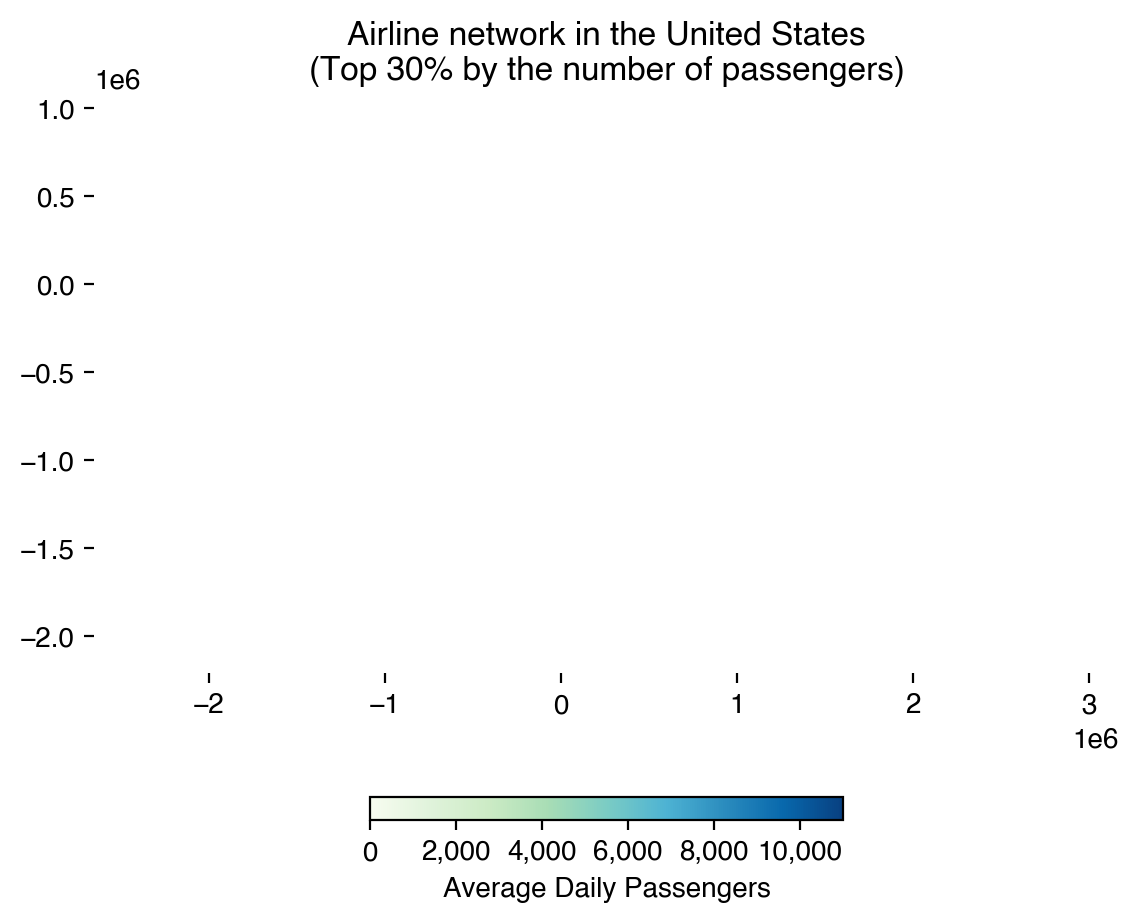

In [1086]:
# Your turn!

# Task:
# Plot the US domestic flights network with the sampled edges.
# Use the projected coordinates for plotting.

fig_airport, ax = plt.subplots(1,1)

# Plot all airports
# Hint: Use pos=pos_proj_airport


# Plot sampled airline routes
# Hint: Use pos=pos_proj_airport


# Set plotting range
ax.set_xlim(airport_map_min_x, airport_map_max_x)
ax.set_ylim(airport_map_min_y, airport_map_max_y)

# Colorbars
cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Average Daily Passengers', orientation='horizontal', shrink=0.4)

ticks = np.arange(vmin_rounded, vmax_rounded + 1, 2000)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{int(tick):,}" for tick in ticks])

# Title and labels
ax.set_title(f"Airline network in the United States\n(Top {passenger_threshold_percentage*100:.0f}% by the number of passengers)")
ax.set_xlabel("")
ax.set_ylabel("")

# Hide borders
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

# We need this to plot in a good aspect ratio
ax.set_aspect('equal')

# X/Y axis ticks for debugging
# ax.tick_params(axis='x', which='both', labelbottom=True)
# ax.tick_params(axis='y', which='both', labelleft=True)

fig_airport.tight_layout()

# plt.savefig('fig/fig_name.pdf', bbox_inches='tight')
plt.show()

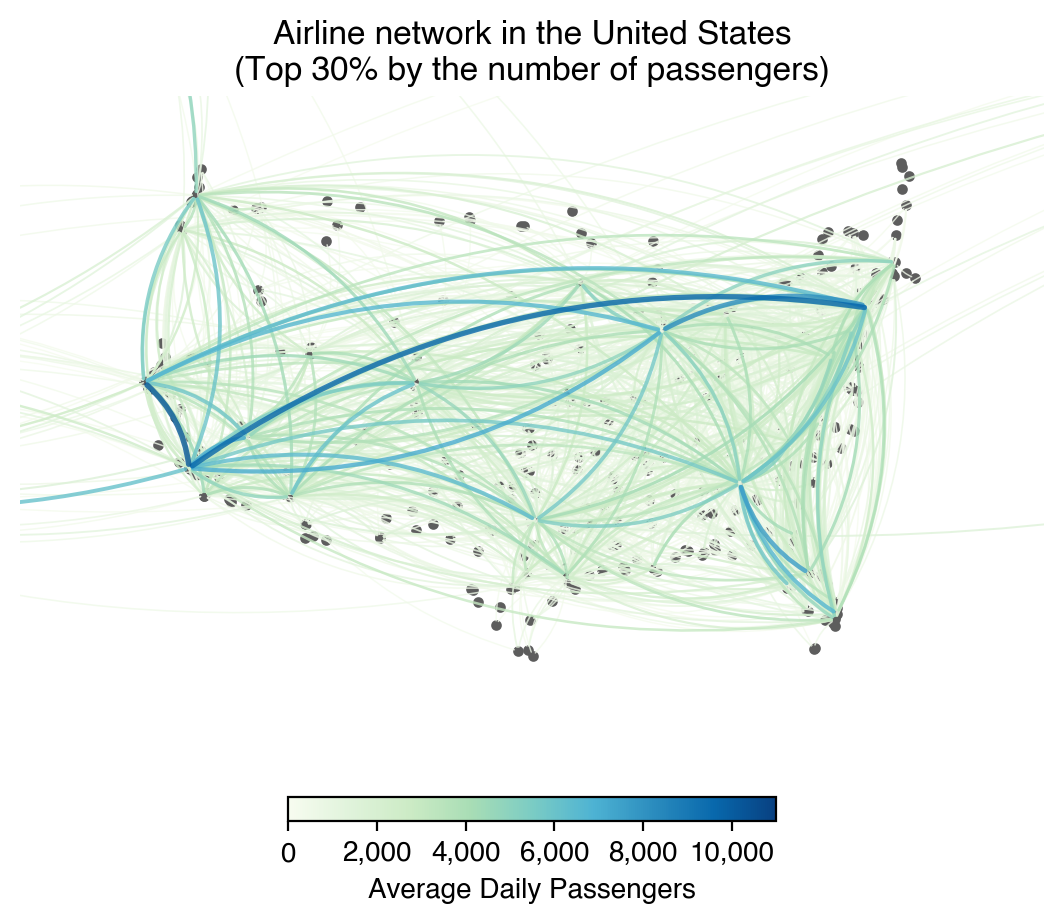

In [1088]:
# Task:
# Plot the US domestic flights network with the sampled edges.
# Use the projected coordinates for plotting.

fig_airport, ax = plt.subplots(1,1)

# Plot all airports
# Hint: Use pos=pos_proj_airport
airport_layer = nx.draw_networkx_nodes(
    G_airport,
    ax=ax,
    pos=pos_proj_airport,
    node_size=8,
    # node_color="#9f9f9f"
    node_color="#5d5d5d"
)
airport_layer.set_zorder(-1)

# Plot sampled airline routes
# Hint: Use pos=pos_proj_airport
for i, (u, v, data) in enumerate(edges_sorted):
    nx.draw_networkx_edges(
        U_airport_sampled,
        ax=ax,
        pos=pos_proj_airport,
        edgelist=[(u, v)],
        node_size=8,
        width=edge_widths[i],  # Use calculated widths
        edge_color=[edge_colors[i]],  # Use calculated colors
        alpha=0.8,
        connectionstyle='arc3,rad=0.2',  # Curved edges
        arrows=True,
        arrowsize=1,
        # arrowstyle='->'
    )

# Set plotting range
ax.set_xlim(airport_map_min_x, airport_map_max_x)
ax.set_ylim(airport_map_min_y, airport_map_max_y)

# Colorbars
cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Average Daily Passengers', orientation='horizontal', shrink=0.4)

ticks = np.arange(vmin_rounded, vmax_rounded + 1, 2000)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{int(tick):,}" for tick in ticks])

# Title and labels
ax.set_title(f"Airline network in the United States\n(Top {passenger_threshold_percentage*100:.0f}% by the number of passengers)")
ax.set_xlabel("")
ax.set_ylabel("")

# Hide borders
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

# We need this to plot in a good aspect ratio
ax.set_aspect('equal')

# X/Y axis ticks for debugging
# ax.tick_params(axis='x', which='both', labelbottom=True)
# ax.tick_params(axis='y', which='both', labelleft=True)

fig_airport.tight_layout()

# plt.savefig('fig/airline_network.pdf', bbox_inches='tight')
# plt.savefig('fig/airline_network.png', bbox_inches='tight', dpi=300)

plt.show()

### Applying algorithms to the airline network

(Repeated from introduction of the section):  
Once again, here are the questions that we are trying to explore using the data and the algorithms:

1. Which flow minimizes the cost (in terms of the eucledean distance) between BOS and SEA?
2. What is the maximum number of people that can travel from BOS to SEA per day, if we were to use all possible routes without putting any limits in layovers? How many routes are there that satisfies this condition?

Since the information limited in the dataset is limited, we'll set following assumptions:
- The "capacity" of each edge (route) is the average number of passengers per day. Since the values in the "PASSENGER" column is the total number of passengers in a year, we'll divide this by 365.
- The "cost" of each edge (route) is the eucledean distance between the departure and the destination airport.


In [1001]:
# MultiDiGraph is not supported for the algorithms that we'll apply
D_airport = nx.DiGraph(G_airport)

In [1002]:
# Let's find the minimum-cost 
departure_airport = "BOS"
destination_airport = "SEA"

In [1003]:
nx.set_node_attributes(D_airport, 0, 'supply')
D_airport.nodes(data=True)[departure_airport]['supply'] = 100
D_airport.nodes(data=True)[destination_airport]['supply'] = -100

D_airport = convert_supply_to_demand(D_airport)

#### 1. Minimum Cost Flow
**Question:**  
Which flow minimizes the cost (in terms of the eucledean distance) between BOS and SEA?

In [1004]:
min_cost_value_airport, min_cost_flow_dict_airport = \
    nx.network_simplex(
        D_airport,
        capacity="passengers",
        weight="distance"
    )

In [1005]:
min_cost_value_airport

-13673.686505703357

In [1006]:
# Reconstruct the paths from the flow dictionary
min_cost_flow_paths_airport = generate_paths_from_flow_dict(
    min_cost_flow_dict_airport,
    source_node=departure_airport,
    target_node=destination_airport
)
min_cost_flow_paths_airport

[['BOS', 'SEA']]

**Answer:**  
Obviously as you can observe in the following figure, the flow that minimizes the cost (in terms of the eucledean distance) is the **direct flight between BOS-SEA**.

In [1007]:
def extract_edges_as_lists(paths):
    """
    Extract all unique edges from a list of paths and return them as lists.

    Parameters
    ----------
        paths (list of lists)
            Each inner list is a path represented by a sequence of nodes.

    Returns
    ----------
        list of lists
            Each inner list represents an edge [u, v].
    """

    edges = set()

    for path in paths:
        for i in range(len(path) - 1):
            u, v = path[i], path[i + 1]
            edges.add(frozenset([u, v]))

    return [list(edge) for edge in edges]

In [1008]:
min_cost_flow_edges_airport = extract_edges_as_lists(min_cost_flow_paths_airport)

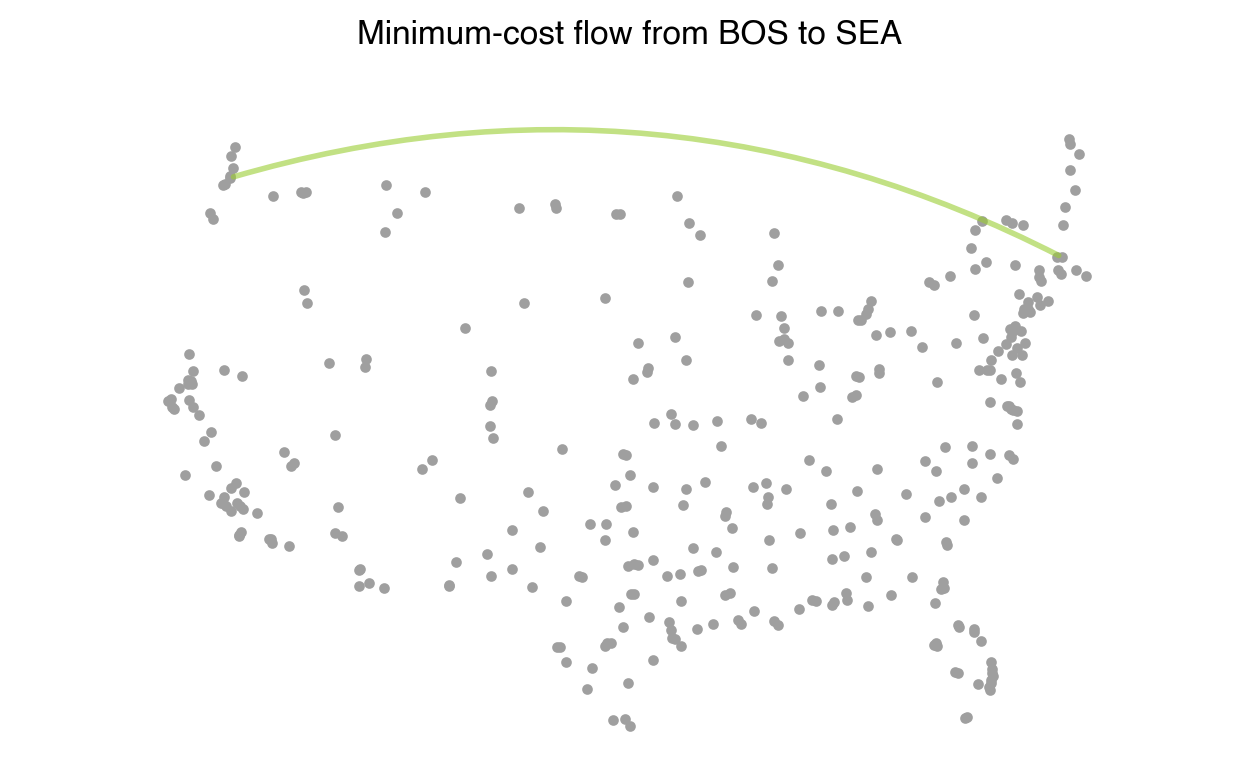

In [ ]:
fig_airport_mincost, ax = plt.subplots(1,1)

airport_layer = nx.draw_networkx_nodes(
    G_airport,
    ax=ax,
    pos=pos_proj_airport,
    node_size=8,
    node_color="#9f9f9f"
)
airport_layer.set_zorder(-1)

nx.draw_networkx_edges(
    U_airport,
    ax=ax,
    pos=pos_proj_airport,
    edgelist=min_cost_flow_edges_airport,
    node_size=8,
    width=2,
    edge_color='yellowgreen',
    alpha=0.6,
    connectionstyle='arc3,rad=-0.2',
    arrows=True,
    arrowsize=1,
)

# Set plotting range
ax.set_xlim(airport_map_min_x, airport_map_max_x)
ax.set_ylim(airport_map_min_y, airport_map_max_y)

# Title and labels
ax.set_title("Minimum-cost flow from BOS to SEA")
ax.set_xlabel("")
ax.set_ylabel("")

# Hide borders
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

# We need this to plot in a good aspect ratio
ax.set_aspect('equal')

fig_airport_mincost.tight_layout()

# plt.savefig('fig/airline_min-cost_BOS-SEA.pdf', bbox_inches='tight')
# plt.savefig('fig/airline_min-cost_BOS-SEA.png', bbox_inches='tight', dpi=300)

plt.show()

#### 2. Maximum flow problem
**Question:**  
What is the maximum number of people that can travel from BOS to SEA per day, if we were to use all possible routes without putting any limits in layovers? How many routes are there that satisfies this condition?

In [1011]:
max_flow_value_airport_nx, flow_dict_airport_nx = nx.maximum_flow(
    D_airport,
    departure_airport,
    destination_airport,
    capacity='passengers'
)

In [1012]:
max_flow_value_airport_nx

37120.96712328765

In [1013]:
max_flow_paths_airport = generate_paths_from_flow_dict(flow_dict_airport_nx, departure_airport, destination_airport)
max_flow_paths_airport[:3]

[['BOS', 'ABQ', 'ATL', 'ANC', 'SEA'],
 ['BOS', 'ABQ', 'ATL', 'AUS', 'BOI', 'GEG', 'SEA'],
 ['BOS', 'ABQ', 'ATL', 'AUS', 'BOI', 'SEA']]

In [1014]:
len(max_flow_paths_airport)

75

In [1015]:
# This is the average number of passengers in a direct flight per day
average_passengers = D_airport.edges[departure_airport, destination_airport]['passengers']
average_passengers

631.8164383561644

In [1016]:
max_flow_value_airport_nx / average_passengers

58.75277195995018

In [1017]:
max_flow_edges_airport = extract_edges_as_lists(max_flow_paths_airport)

In [1018]:
max_flow_edges_airport[:3]

[['ONT', 'IAH'], ['SEA', 'RNO'], ['SEA', 'HLN']]

**Answer:**  
The maximum flow from BOS to SEA includes 75 routes, which can tranport a total of 37,120 people per day. This is 58 times the number of passengers that a direct flight can carry per day.

As you can observe in the following figure, it utilizes the airline network across the country to achieve the maximum flow (maximum number of passengers) in a day from BOS to SEA.

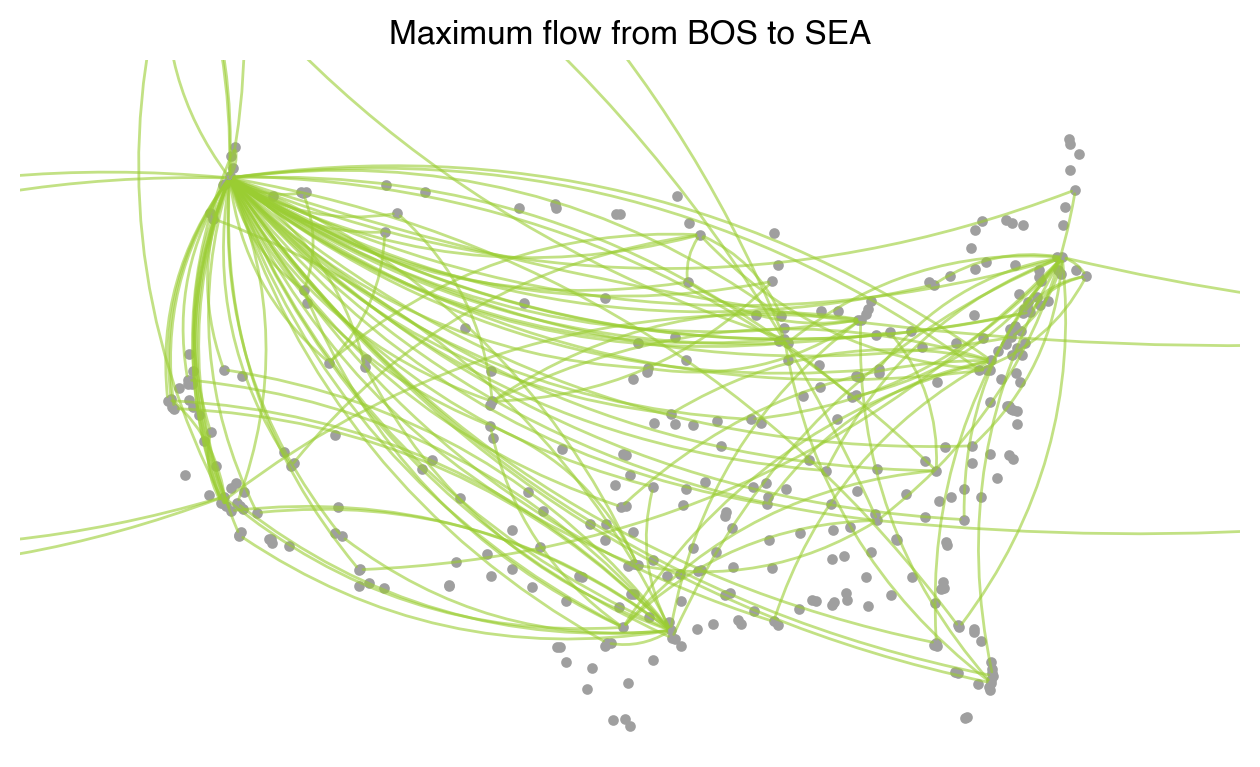

In [1021]:
# Let's try plotting all the routes that maximizes the flow

fig_airport_maxflow, ax = plt.subplots(1,1)

airport_layer = nx.draw_networkx_nodes(
    G_airport,
    ax=ax,
    pos=pos_proj_airport,
    node_size=8,
    node_color="#9f9f9f"
)
airport_layer.set_zorder(-1)

nx.draw_networkx_edges(
    U_airport,
    ax=ax,
    pos=pos_proj_airport,
    edgelist=max_flow_edges_airport,
    node_size=8,
    width=1,
    edge_color='yellowgreen',
    alpha=0.6,
    connectionstyle='arc3,rad=0.2',  # Curved edges
    arrows=True,
    arrowsize=1,
)

# Set plotting range
ax.set_xlim(airport_map_min_x, airport_map_max_x)
ax.set_ylim(airport_map_min_y, airport_map_max_y)

# Title and labels
ax.set_title("Maximum flow from BOS to SEA")
ax.set_xlabel("")
ax.set_ylabel("")

# Hide borders
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

# We need this to plot in a good aspect ratio
ax.set_aspect('equal')

fig_airport_maxflow.tight_layout()

# plt.savefig('fig/airline_max-flow_BOS-SEA.pdf', bbox_inches='tight')
# plt.savefig('fig/airline_max-flow_BOS-SEA.png', bbox_inches='tight', dpi=300)

plt.show()

***
<h2 id="casestudy-osm">7. Case Study: OpenStreet Map</h2>

We can also apply the same algorithms to roads, using the data from OpenStreet Map with `osmnx` package [12]. For this dataset, we'll try to answer the following questions:
1. Which is the route(s) that has the minimum distance from Network Science Intititue to Boston Logan International airport?
2. Assuming that the car runs at a constant speed from start to end, in which route(s) can we run at the fastest speed?

The assumptions we set here are:
- The "capacity" of each edge is the speed limit of each road, in km/h.
- The "cost" of each edge is the length/distance of each road.

### Import data

In [1022]:
import osmnx as ox

In [1023]:
# Download the street network from OpenStreetMap
place = "Boston, MA, USA"  # Replace with your desired location
G_osm = ox.graph_from_place(place, network_type="drive")

In [ ]:
G_osm = ox.routing.add_edge_speeds(G_osm, fallback=-float("inf")) #This adds speeds in km/h
G_osm = ox.routing.add_edge_travel_times(G_osm)

### Construct network

In [1089]:
# Some conversion of edge attributes to make it compatible with the optimization model

for u, v, data in G_osm.edges(data=True):
    # Use 'length' as the cost (distance in meters)
    data["cost"] = data.get("length", float("inf"))

    # Cost has to be integer to use nx.maximum_flow()
    if data["cost"] != float("inf"):
        data["cost"] = int(data["cost"])
    
    # Use speed (in km/h) as the capacity
    data["capacity"] = data.get("speed_kph", 0)
    
    if data["capacity"] < 0:
        # There cannot be negative capacity
        data["capacity"] = 0
    else:
        # Capacity has to be integer to use nx.maximum_flow()
        data["capacity"] = int(data["capacity"])


In [1090]:
list(G_osm.edges(data=True))[0]

(30730954,
 61441677,
 {'osmid': 197230699,
  'highway': 'residential',
  'lanes': '2',
  'maxspeed': '25 mph',
  'name': 'Logan Memorial Way',
  'oneway': True,
  'reversed': False,
  'length': np.float64(33.07297223949995),
  'geometry': <LINESTRING (-71.022 42.368, -71.022 42.368, -71.022 42.368, -71.022 42.368)>,
  'speed_kph': 40.2335,
  'travel_time': 2.9592926308225684,
  'cost': 33,
  'capacity': 40})

In [1094]:
# Source: NetSI at 177 Huntington Ave.
source_point = (42.344893765894646, -71.08272996457559) 

# Target: Boston Logan International Airport
target_point = (42.369136316492515, -71.02049657834628)

# Find the nearest nodes to the given points
source = ox.distance.nearest_nodes(G_osm, X=source_point[1], Y=source_point[0])
target = ox.distance.nearest_nodes(G_osm, X=target_point[1], Y=target_point[0])

print(f"Name of source node: {source}")
print(f"Name of target node: {target}")

Name of source node: 61371329
Name of target node: 61548256


In [1095]:
# Set supply to source and target nodes
nx.set_node_attributes(G_osm, 0, 'supply')
G_osm.nodes(data=True)[source]['supply'] = 10
G_osm.nodes(data=True)[target]['supply'] = -10
G_osm = convert_supply_to_demand(G_osm)

In [1096]:
# Convert to DiGraph to apply algorithms
D_osm = ox.convert.to_digraph(G_osm)

### Applying algorithms

#### 1. Minimum cost problem

In [1097]:
min_cost_value_osm, min_cost_flow_dict_osm = \
    nx.network_simplex(D_osm, weight="cost", capacity="capacity")

In [1098]:
min_cost_paths_osm = generate_paths_from_flow_dict(min_cost_flow_dict_osm, source, target)

In [1099]:
# Travel distance for the minimum cost flow path
sum_edge_attribute_over_path(D_osm, min_cost_paths_osm[0], 'cost') / 1000

8.668

In [1100]:
min_cost_edges_osm = extract_edges_as_lists(min_cost_paths_osm)

#### 2. Maximum flow problem

In [1101]:
max_flow_value_osm, flow_dict_osm = nx.maximum_flow(
    D_osm,
    source,
    target,
    capacity="capacity"
)

In [1102]:
max_flow_value_osm

45

In [1103]:
max_flow_paths_osm = generate_paths_from_flow_dict(flow_dict_osm, source, target)

In [1104]:
len(max_flow_paths_osm)

1

In [1105]:
# Travel distance for the minimum cost flow path (in kilometers)
sum_edge_attribute_over_path(D_osm, max_flow_paths_osm[0], 'cost') / 1000

17.182

In [1106]:
max_flow_edges_osm = extract_edges_as_lists(max_flow_paths_osm)

### Visualization

In [1107]:
xpos_osm = nx.get_node_attributes(G_osm,'x')
ypos_osm = nx.get_node_attributes(G_osm,'y')
pos_init = {i:(xpos_osm[i],ypos_osm[i]) for i in G_osm.nodes()}

In [1108]:
G_osm.remove_edges_from(list(nx.selfloop_edges(G_osm)))

In [1109]:
# Calculate plotting range
x_min_osm = min(list(dict(nx.get_node_attributes(G_osm, 'x')).values()))
x_max_osm = max(list(dict(nx.get_node_attributes(G_osm, 'x')).values()))
y_min_osm = min(list(dict(nx.get_node_attributes(G_osm, 'y')).values()))
y_max_osm = max(list(dict(nx.get_node_attributes(G_osm, 'y')).values()))

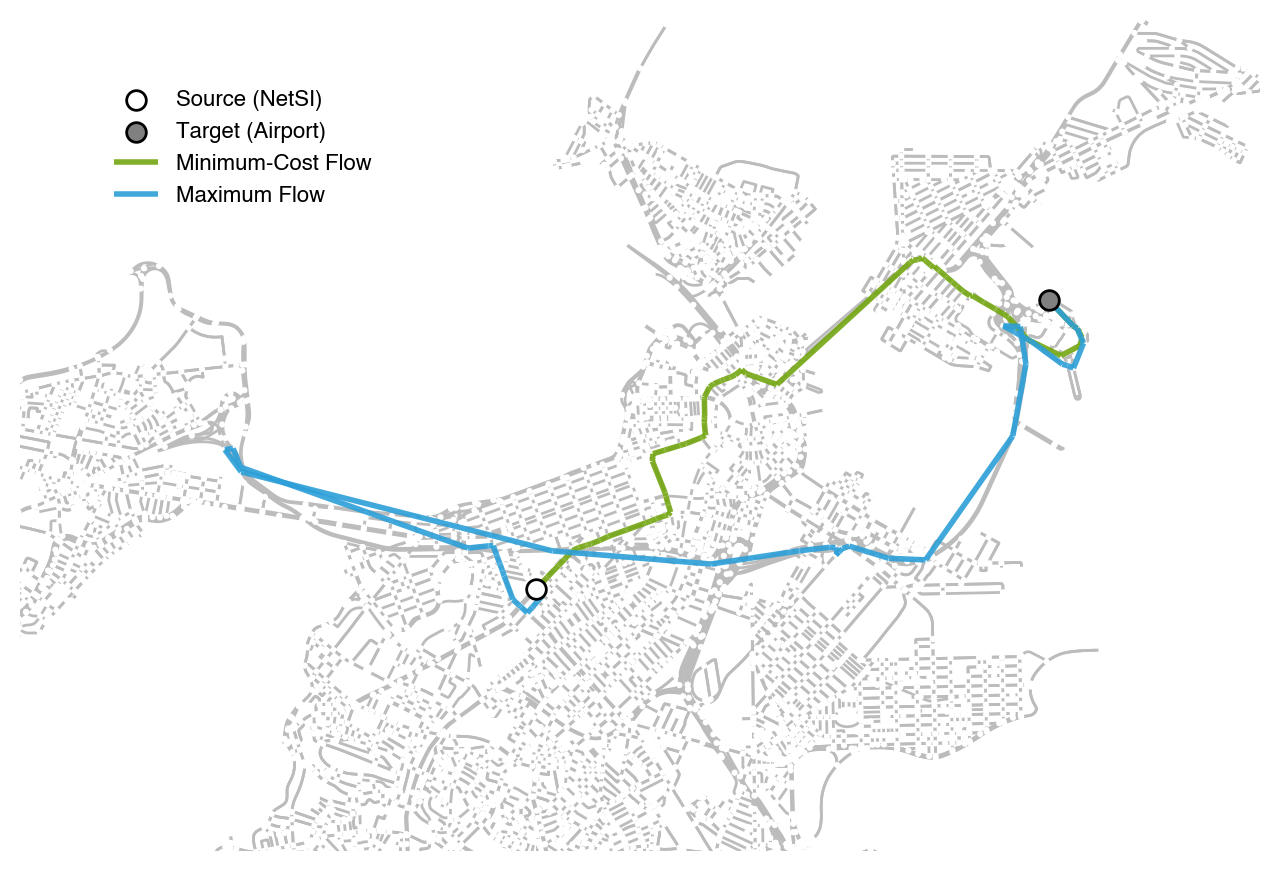

In [ ]:
fig, ax = ox.plot_graph(
    G_osm,
    bgcolor='white',
    edge_color = '#bcbcbc',
    node_size=5,
    edge_linewidth=1,
    show=False,
    close=False
)

# Source and target nodes
ax.scatter(
    *pos_init[source],
    c="white",
    s=50,
    edgecolors="black",
    label="Source (NetSI)",
    zorder=5
)
ax.scatter(
    *pos_init[target],
    c="gray",
    s=50,
    edgecolors="black",
    label="Target (Airport)",
    zorder=5
)

# Minimum-cost flow path
nx.draw_networkx_edges(
    G_osm,
    pos=pos_init,
    edgelist=min_cost_edges_osm,
    edge_color="#74a611",
    node_size=0,
    width=2,
    alpha=0.9,
    label="Minimum-Cost Flow",
    arrows=False,
    ax=ax
)

# Maximum flow
nx.draw_networkx_edges(
    G_osm,
    pos=pos_init,
    edgelist=max_flow_edges_osm,
    edge_color="#2c9fd8",
    width=2,
    alpha=0.9,
    label="Maximum Flow",
    arrows=False,
    ax=ax,
)

ax.set_ylim(y_min_osm  + ((y_max_osm - y_min_osm)*0.55), y_max_osm)
ax.set_xlim(x_min_osm  + ((x_max_osm - x_min_osm)*0.2), x_max_osm)

ax.legend(frameon=False, fontsize=8, bbox_to_anchor=(0.3, 0.94))

# plt.savefig('fig/osm-routes.pdf', bbox_inches='tight')
# plt.savefig('fig/osm-routes.png', bbox_inches='tight', dpi=300)

plt.show()

The path in green is the flow with the minimum cost, which has the minimum travel distance of 8.7km. It suggests using the local road, including the Stuart St, Beacon St, and the [Callahan Tunnel](https://en.wikipedia.org/wiki/Callahan_Tunnel).

The path in blue is the only path that constitutes the maximum flow, which is the route with fastest lane limits if we are driving at a constant speed. For this path, we can drive constantly around 45 km/h (27 mph) (although such assumption of driving at constant speed isn't feasible in the real world). This has a travel distance of 17.1km, which is nearly the double of the path for the minimum cost flow. The route here is interesting because it suggests using [Massachusetts Turnpike](https://en.wikipedia.org/wiki/Massachusetts_Turnpike) (toll road, I-90), which can only be taken by first detouring to the west side of Boston, close to Cambridge.

***
<h2 id="conclusion">8. Conclusion</h2>

In this chapter, we have went through the fundamental concepts of network flows, major problems and corresponding algorithms with step-by-step visualizations and scratch implementations. The very last part of the chapter was the case study in which we applied two algorithms (augmenting path algorithm and successive shortest path algorithm) on two actual datasets, one from the air (airline networks) and one from the land (road networks).

Although the problems and algorithms that we've covered are primitive ones, understanding these should build a good foundation to start exploring the optimization of network and flows.

If you are more interested in this topic, here are the starting points to think about:
- What other data or networks in the real world that can be modelled using the problems introduced in this chapter?
- What element can we additionally consider so that the models become more practical?
- Try tweaking the cost function in some models!


***
<h2 id="references">References</h2>


- [1] Harris T.E, Ross F.S. Fundamentals of a Method for Evaluating Rail Net Capacities. 1955. https://apps.dtic.mil/sti/citations/tr/AD0093458
- [2] Ford LR, Fulkerson DR. Maximal Flow Through a Network. *Can J Math* 1956; 8: 399–404. https://doi.org/10.4153/CJM-1956-045-5
- [3] Newman M (ed). Networks (2nd edition). Oxford University Press, 2018. https://doi.org/10.1093/oso/9780198805090.001.0001
- [4] Kleinberg J, Tardos É. Algorithm Design. Pearson Education, 2006.
- [5] Ahuja B, Magnant T, Orlin J. Network Flows: Theory, Algorithms, and Applications. Prentice Hall, 1993.
- [6] Goldberg AV, Tarjan RE. Finding minimum-cost circulations by canceling negative cycles. J ACM 1989; 36: 873–886. https://dl.acm.org/doi/10.1145/76359.76368
- [7] Boyles S. Minimum Cost flow Problem, CE377K. 2015. https://sboyles.github.io/teaching/ce377k/class14.pdf
- [8] Casey D. Dynamic Route Changes Reflect Shifting Demand Patterns. Aviation Week. 2024. https://aviationweek.com/air-transport/airports-networks/dynamic-route-changes-reflect-shifting-demand-patterns
- [9] Jessica Su. Bellman-Ford Algorithm, CS 161 Lecture 14  Amortized Analysis. 2016. https://web.stanford.edu/class/archive/cs/cs161/cs161.1168/lecture14.pdf
- [10] Cancho R.F.i., Solé R.V.  Optimization in Complex Networks. Lecture Notes in Physics, vol 625. 2003. https://doi.org/10.1007/978-3-540-44943-0_7
- [11] Eric Ma. Network Analysis Made Simple | GitHub. https://github.com/ericmjl/Network-Analysis-Made-Simple/tree/master
- [12] Boeing G. OSMnx 2.0.0 documentation. https://osmnx.readthedocs.io/en/stable/